# Install and Import Dependencies

In [1]:
!pip install tensorflow opencv-python mediapipe scikit-learn matplotlib tensorflowjs

  Using cached tensorflowjs-4.22.0-py3-none-any.whl.metadata (3.2 kB)
  Using cached numpy-2.1.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
  Using cached mediapipe-0.10.20-cp310-cp310-win_amd64.whl.metadata (9.9 kB)
  Using cached mediapipe-0.10.18-cp310-cp310-win_amd64.whl.metadata (9.9 kB)
  Using cached mediapipe-0.10.14-cp310-cp310-win_amd64.whl.metadata (9.9 kB)
  Using cached flax-0.10.7-py3-none-any.whl.metadata (11 kB)
  Using cached tf_keras-2.20.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorflow_decision_forests-1.8.1.tar.gz (15.2 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached packaging-23.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached msgpack-1.1.1-cp310-cp310-win_am

  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [18 lines of output]
  Traceback (most recent call last):
    File "<string>", line 2, in <module>
    File "<pip-setuptools-caller>", line 35, in <module>
    File "C:\Users\thero\AppData\Local\Temp\pip-install-nqtjkgk9\cffi_ac507573283643ac80e893ae046c9af7\setup.py", line 127, in <module>
      if sys.platform == 'win32' and uses_msvc():
    File "C:\Users\thero\AppData\Local\Temp\pip-install-nqtjkgk9\cffi_ac507573283643ac80e893ae046c9af7\setup.py", line 105, in uses_msvc
      return config.try_compile('#ifndef _MSC_VER\n#error "not MSVC"\n#endif')
    File "C:\Users\thero\AppData\Local\Programs\Python\Python310\lib\site-packages\setuptools\_distutils\command\config.py", line 213, in try_compile
      self._compile(body, headers, include_dirs, lang)
    File "C:\Users\thero\AppData\Local\Programs\Python\Python310\lib\site-packages\setuptools\_distutils\command\config.py"

In [2]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# Keypoints using MP Holistic

In [3]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [4]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR-CONVERSION BGR-to-RGB
    image.flags.writeable = False                  # Convert image to not-writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Convert image to writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR-COVERSION RGB-to-BGR
    return image, results

In [5]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [6]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [118]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [7]:
draw_landmarks(frame, results)

NameError: name 'frame' is not defined

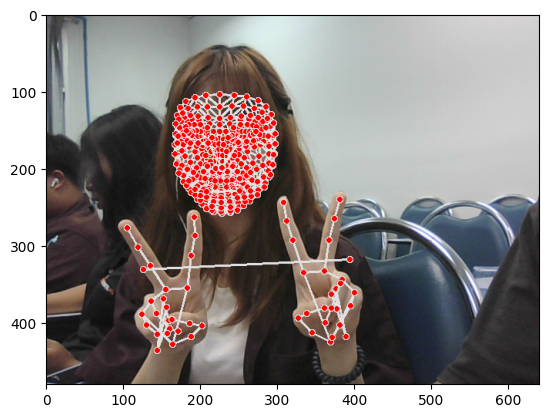

In [9]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Extract Keypoint Values

In [7]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

# Setup Folders for Collection

In [8]:
import os
import numpy as np

DATA_PATH = os.path.join('MP_Data') 
actions = np.array(['sorry'])

sequence_length = 30   # เฟรมต่อคลิป
no_sequences = 100      # จำนวนที่จะเก็บรอบนี้

def prepare_folders(actions, data_path=DATA_PATH):
    """
    สร้างโฟลเดอร์ action ถ้ายังไม่มี
    และคืนค่า start_folder สำหรับแต่ละ action โดยอิงจากโฟลเดอร์สูงสุดที่มีอยู่
    """
    start_folders = {}
    if not os.path.exists(data_path):
        os.mkdir(data_path)

    for action in actions:
        act_path = os.path.join(data_path, action)
        os.makedirs(act_path, exist_ok=True)

        # หาว่ามี subfolder ถึงเลขไหนแล้ว
        existing = [int(f) for f in os.listdir(act_path) if f.isdigit()]
        
        start_folder = max(existing)+1 if existing else 0
        start_folders[action] = start_folder

    return start_folders

# ใช้งาน
start_folders = prepare_folders(actions)
for action in actions:
    print(f"Action: {action}, next start folder = {start_folders[action]}")


Action: sorry, next start folder = 300


# Collect Keypoint Values for Training and Testing

In [120]:
import os
import cv2
import numpy as np

# ===== สวิตช์การบันทึก =====
SAVE_NPY         = True   # เก็บคีย์พอยต์ (สำหรับเทรน/ทำนายเดิม)
SAVE_PNG_OVERLAY = True   # เก็บภาพที่วาดโครงร่างทับแล้ว (ดูง่าย/QA)
SAVE_PNG_RAW     = False  # ทางเลือก: เก็บภาพกล้องดิบ

# ===== ฟังก์ชันช่วย =====
def fname_png(frame_num): return f"{frame_num:03d}.png"  # 000.png, 001.png, ...
def fname_npy(frame_num): return f"{frame_num}.npy"

def get_next_start_folder(action):
    path = os.path.join(DATA_PATH, action)
    if not os.path.exists(path):
        return 0
    existing = [int(f) for f in os.listdir(path) if f.isdigit()]
    return max(existing)+1 if existing else 0

# ===== เริ่มเก็บ =====
cap = cv2.VideoCapture(0)

with mp_holistic.Holistic(min_detection_confidence=0.5,
                          min_tracking_confidence=0.5) as holistic:

    for action in actions:
        start_folder = get_next_start_folder(action)

        for sequence in range(start_folder, start_folder + no_sequences):
            # โฟลเดอร์หลักของ sequence
            seq_path = os.path.join(DATA_PATH, action, str(sequence))
            os.makedirs(seq_path, exist_ok=True)

            # โฟลเดอร์ย่อยสำหรับ PNG
            png_overlay_dir = os.path.join(seq_path, "overlay_png")
            png_raw_dir     = os.path.join(seq_path, "raw_png")
            if SAVE_PNG_OVERLAY: os.makedirs(png_overlay_dir, exist_ok=True)
            if SAVE_PNG_RAW:     os.makedirs(png_raw_dir, exist_ok=True)

            for frame_num in range(sequence_length):
                ret, frame = cap.read()
                if not ret:
                    continue

                raw_frame = frame.copy()  # เผื่อเซฟ RAW

                # Mediapipe + วาดโครงร่างลงบนภาพ (in-place)
                image, results = mediapipe_detection(frame, holistic)
                draw_styled_landmarks(image, results)

                # UI preview
                head = f'Collecting frames for {action} Video {sequence}'
                if frame_num == 0:
                    cv2.putText(image, 'STARTING COLLECTION', (120,200),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 4, cv2.LINE_AA)
                cv2.putText(image, head, (15,12),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)
                if frame_num == 0:
                    cv2.waitKey(500)

                # ===== บันทึก NPY (คีย์พอยต์) =====
                if SAVE_NPY:
                    keypoints = extract_keypoints(results)   # shape (1662,)
                    np.save(os.path.join(seq_path, fname_npy(frame_num)), keypoints)

                # ===== บันทึก PNG (overlay) =====
                if SAVE_PNG_OVERLAY:
                    # image เป็น BGR อยู่แล้ว เซฟได้เลย
                    cv2.imwrite(os.path.join(png_overlay_dir, fname_png(frame_num)), image)

                # ===== บันทึก PNG (raw) (ทางเลือก) =====
                if SAVE_PNG_RAW:
                    cv2.imwrite(os.path.join(png_raw_dir, fname_png(frame_num)), raw_frame)

                print(f"[{action}/{sequence}] frame {frame_num:03d} saved "
                      f"{'(npy)' if SAVE_NPY else ''}"
                      f"{' (png_overlay)' if SAVE_PNG_OVERLAY else ''}"
                      f"{' (png_raw)' if SAVE_PNG_RAW else ''}")

                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break

cap.release()
cv2.destroyAllWindows()


[sorry/200] frame 000 saved (npy) (png_overlay)
[sorry/200] frame 001 saved (npy) (png_overlay)
[sorry/200] frame 002 saved (npy) (png_overlay)
[sorry/200] frame 003 saved (npy) (png_overlay)
[sorry/200] frame 004 saved (npy) (png_overlay)
[sorry/200] frame 005 saved (npy) (png_overlay)
[sorry/200] frame 006 saved (npy) (png_overlay)
[sorry/200] frame 007 saved (npy) (png_overlay)
[sorry/200] frame 008 saved (npy) (png_overlay)
[sorry/200] frame 009 saved (npy) (png_overlay)
[sorry/200] frame 010 saved (npy) (png_overlay)
[sorry/200] frame 011 saved (npy) (png_overlay)
[sorry/200] frame 012 saved (npy) (png_overlay)
[sorry/200] frame 013 saved (npy) (png_overlay)
[sorry/200] frame 014 saved (npy) (png_overlay)
[sorry/200] frame 015 saved (npy) (png_overlay)
[sorry/200] frame 016 saved (npy) (png_overlay)
[sorry/200] frame 017 saved (npy) (png_overlay)
[sorry/200] frame 018 saved (npy) (png_overlay)
[sorry/200] frame 019 saved (npy) (png_overlay)
[sorry/200] frame 020 saved (npy) (png_o

In [121]:
cap.release()
cv2.destroyAllWindows()

# 1cleaning data

In [122]:
import os
import cv2
import hashlib
import numpy as np
from tqdm import tqdm
from collections import defaultdict
import logging

# ------------------------
# Setup Logging
# ------------------------
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('data_cleaning.log'),
        logging.StreamHandler()
    ]
)

# ------------------------
# กำหนดโฟลเดอร์หลัก
# ------------------------
DATA_ROOT = r"C:\Users\Admin\Documents\sign\Realtime-Sign-Language-Detection-Using-LSTM-Model-main\MP_Data"
VALID_IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp", ".tiff"}
MIN_IMAGE_SIZE = (10, 10)  # ขนาดภาพต่ำสุดที่ยอมรับ
MAX_IMAGE_SIZE = (5000, 5000)  # ขนาดภาพสูงสุดที่ยอมรับ

# ------------------------
# Helper Functions
# ------------------------
def get_image_hash(img_path):
    """สร้าง hash จาก pixel data เพื่อตรวจจับภาพซ้ำ"""
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None
        # Resize เป็นขนาดเล็กเพื่อเปรียบเทียบ
        small_img = cv2.resize(img, (32, 32))
        return hashlib.md5(small_img.tobytes()).hexdigest()
    except Exception as e:
        logging.error(f"Error creating hash for {img_path}: {e}")
        return None

def is_valid_image(img_path):
    """ตรวจสอบว่าภาพถูกต้องและมีคุณภาพเพียงพอ"""
    try:
        img = cv2.imread(img_path)
        if img is None:
            return False, "ไม่สามารถโหลดภาพได้"
        
        height, width = img.shape[:2]
        
        # ตรวจสอบขนาดภาพ
        if height < MIN_IMAGE_SIZE[0] or width < MIN_IMAGE_SIZE[1]:
            return False, f"ภาพเล็กเกินไป ({width}x{height})"
        
        if height > MAX_IMAGE_SIZE[0] or width > MAX_IMAGE_SIZE[1]:
            return False, f"ภาพใหญ่เกินไป ({width}x{height})"
        
        # ตรวจสอบภาพว่างหรือสีเดียว
        if np.all(img == img[0, 0]) or img.size == 0:
            return False, "ภาพว่างหรือเป็นสีเดียว"
        
        # ตรวจสอบ contrast
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if gray.std() < 5:  # contrast ต่ำเกินไป
            return False, "ภาพมี contrast ต่ำเกินไป"
        
        return True, "ภาพถูกต้อง"
    
    except Exception as e:
        return False, f"Error: {str(e)}"

def is_valid_npy(npy_path):
    """ตรวจสอบไฟล์ .npy ว่าถูกต้องและเหมาะสมสำหรับการใช้งาน"""
    try:
        data = np.load(npy_path)
        
        # ตรวจสอบ NaN หรือ inf
        if np.isnan(data).any():
            return False, "มี NaN values"
        
        if np.isinf(data).any():
            return False, "มี infinite values"
        
        # ตรวจสอบ shape ว่าถูกต้อง
        if len(data.shape) == 0 or data.size == 0:
            return False, "ข้อมูลว่าง"
        
        # ตรวจสอบว่าเป็นข้อมูลซ้ำทั้งหมด
        if data.ndim > 0 and np.all(data == data.flat[0]):
            return False, "ข้อมูลซ้ำทั้งหมด"
        
        # ตรวจสอบความแปรปรวน (สำหรับข้อมูล keypoints)
        if data.ndim >= 2 and data.shape[0] > 1:
            variance = np.var(data, axis=0)
            if np.all(variance < 1e-6):
                return False, "ไม่มีการเคลื่อนไหว (variance ต่ำเกินไป)"
        
        return True, "ข้อมูลถูกต้อง"
    
    except Exception as e:
        return False, f"Error loading file: {str(e)}"

# ------------------------
# Cleaning Functions
# ------------------------
def clean_images(root_dir):
    """ทำความสะอาดไฟล์ภาพ"""
    seen_hashes = set()
    stats = {
        'total': 0,
        'removed_corrupt': 0,
        'removed_duplicate': 0,
        'removed_invalid': 0,
        'kept': 0
    }
    
    print("🔍 กำลังสแกนและทำความสะอาดไฟล์ภาพ...")
    
    for root, dirs, files in os.walk(root_dir):
        image_files = [f for f in files if os.path.splitext(f)[1].lower() in VALID_IMG_EXT]
        
        if not image_files:
            continue
            
        print(f"\n📁 กำลังประมวลผล: {root}")
        
        for filename in tqdm(image_files, desc="ตรวจสอบภาพ"):
            stats['total'] += 1
            file_path = os.path.join(root, filename)
            
            # ตรวจสอบความถูกต้องของภาพ
            is_valid, reason = is_valid_image(file_path)
            
            if not is_valid:
                logging.warning(f"[REMOVE] ภาพไม่ถูกต้อง: {file_path} - {reason}")
                try:
                    os.remove(file_path)
                    stats['removed_invalid'] += 1
                except Exception as e:
                    logging.error(f"ไม่สามารถลบไฟล์ {file_path}: {e}")
                continue
            
            # ตรวจสอบภาพซ้ำ
            img_hash = get_image_hash(file_path)
            if img_hash is None:
                logging.warning(f"[REMOVE] ไม่สามารถสร้าง hash: {file_path}")
                try:
                    os.remove(file_path)
                    stats['removed_corrupt'] += 1
                except Exception as e:
                    logging.error(f"ไม่สามารถลบไฟล์ {file_path}: {e}")
                continue
            
            if img_hash in seen_hashes:
                logging.info(f"[REMOVE] ภาพซ้ำ: {file_path}")
                try:
                    os.remove(file_path)
                    stats['removed_duplicate'] += 1
                except Exception as e:
                    logging.error(f"ไม่สามารถลบไฟล์ {file_path}: {e}")
            else:
                seen_hashes.add(img_hash)
                stats['kept'] += 1
    
    return stats

def clean_npy_files(root_dir):
    """ทำความสะอาดไฟล์ .npy"""
    stats = {
        'total': 0,
        'removed_corrupt': 0,
        'removed_invalid': 0,
        'kept': 0
    }
    
    print("\n🔍 กำลังสแกนและทำความสะอาดไฟล์ .npy...")
    
    for root, dirs, files in os.walk(root_dir):
        npy_files = [f for f in files if f.endswith('.npy')]
        
        if not npy_files:
            continue
            
        print(f"\n📁 กำลังประมวลผล: {root}")
        
        for filename in tqdm(npy_files, desc="ตรวจสอบ .npy"):
            stats['total'] += 1
            file_path = os.path.join(root, filename)
            
            is_valid, reason = is_valid_npy(file_path)
            
            if not is_valid:
                logging.warning(f"[REMOVE] ไฟล์ .npy ไม่ถูกต้อง: {file_path} - {reason}")
                try:
                    os.remove(file_path)
                    stats['removed_invalid'] += 1
                except Exception as e:
                    logging.error(f"ไม่สามารถลบไฟล์ {file_path}: {e}")
            else:
                stats['kept'] += 1
    
    return stats

def clean_empty_directories(root_dir):
    """ลบโฟลเดอร์ว่าง"""
    removed_dirs = 0
    
    print("\n🔍 กำลังลบโฟลเดอร์ว่าง...")
    
    for root, dirs, files in os.walk(root_dir, topdown=False):
        for dir_name in dirs:
            dir_path = os.path.join(root, dir_name)
            try:
                if not os.listdir(dir_path):  # โฟลเดอร์ว่าง
                    os.rmdir(dir_path)
                    logging.info(f"[REMOVE] โฟลเดอร์ว่าง: {dir_path}")
                    removed_dirs += 1
            except Exception as e:
                logging.error(f"ไม่สามารถลบโฟลเดอร์ {dir_path}: {e}")
    
    return removed_dirs

def get_dataset_statistics(root_dir):
    """สถิติของ dataset หลังจากทำความสะอาด"""
    stats = defaultdict(int)
    class_stats = defaultdict(lambda: {'images': 0, 'npy_files': 0})
    
    for root, dirs, files in os.walk(root_dir):
        class_name = os.path.basename(root)
        
        for filename in files:
            ext = os.path.splitext(filename)[1].lower()
            
            if ext in VALID_IMG_EXT:
                stats['total_images'] += 1
                class_stats[class_name]['images'] += 1
            elif ext == '.npy':
                stats['total_npy'] += 1
                class_stats[class_name]['npy_files'] += 1
    
    stats['total_classes'] = len([k for k, v in class_stats.items() if v['images'] > 0 or v['npy_files'] > 0])
    
    return dict(stats), dict(class_stats)

# ------------------------
# Main Script
# ------------------------
if __name__ == "__main__":
    print("🚀 เริ่มต้นการทำความสะอาดข้อมูลภาษามือ")
    print(f"📂 โฟลเดอร์เป้าหมาย: {DATA_ROOT}")
    print("="*60)
    
    if not os.path.exists(DATA_ROOT):
        print(f"❌ ไม่พบโฟลเดอร์: {DATA_ROOT}")
        exit(1)
    
    # 1. ทำความสะอาดไฟล์ภาพ
    img_stats = clean_images(DATA_ROOT)
    
    # 2. ทำความสะอาดไฟล์ .npy
    npy_stats = clean_npy_files(DATA_ROOT)
    
    # 3. ลบโฟลเดอร์ว่าง
    removed_dirs = clean_empty_directories(DATA_ROOT)
    
    # 4. สร้างรายงานสถิติ
    final_stats, class_stats = get_dataset_statistics(DATA_ROOT)
    
    # แสดงผลสรุป
    print("\n" + "="*60)
    print("📊 สรุปผลการทำความสะอาด")
    print("="*60)
    
    print(f"\n🖼️  ไฟล์ภาพ:")
    print(f"   • ทั้งหมด: {img_stats['total']:,} ไฟล์")
    print(f"   • เก็บไว้: {img_stats['kept']:,} ไฟล์")
    print(f"   • ลบเพราะเสีย: {img_stats['removed_corrupt']:,} ไฟล์")
    print(f"   • ลบเพราะซ้ำ: {img_stats['removed_duplicate']:,} ไฟล์")
    print(f"   • ลบเพราะไม่ถูกต้อง: {img_stats['removed_invalid']:,} ไฟล์")
    
    print(f"\n📊 ไฟล์ .npy:")
    print(f"   • ทั้งหมด: {npy_stats['total']:,} ไฟล์")
    print(f"   • เก็บไว้: {npy_stats['kept']:,} ไฟล์")
    print(f"   • ลบเพราะเสีย: {npy_stats['removed_corrupt']:,} ไฟล์")
    print(f"   • ลบเพราะไม่ถูกต้อง: {npy_stats['removed_invalid']:,} ไฟล์")
    
    print(f"\n📁 โฟลเดอร์:")
    print(f"   • ลบโฟลเดอร์ว่าง: {removed_dirs} โฟลเดอร์")
    
    print(f"\n📈 สถิติ Dataset สุดท้าย:")
    print(f"   • จำนวนคลาส: {final_stats.get('total_classes', 0)} คลาส")
    print(f"   • ภาพทั้งหมด: {final_stats.get('total_images', 0):,} ไฟล์")
    print(f"   • ไฟล์ .npy ทั้งหมด: {final_stats.get('total_npy', 0):,} ไฟล์")
    
    # แสดงสถิติแต่ละคลาส (10 คลาสแรก)
    if class_stats:
        print(f"\n📋 สถิติ 10 คลาสแรก:")
        for i, (class_name, stats) in enumerate(list(class_stats.items())[:10]):
            if stats['images'] > 0 or stats['npy_files'] > 0:
                print(f"   {i+1:2d}. {class_name}: {stats['images']:,} ภาพ, {stats['npy_files']:,} .npy")
    
    print("\n✅ การทำความสะอาดเสร็จสิ้น!")
    print(f"📝 ดูรายละเอียดใน: data_cleaning.log")

🚀 เริ่มต้นการทำความสะอาดข้อมูลภาษามือ
📂 โฟลเดอร์เป้าหมาย: C:\Users\Admin\Documents\sign\Realtime-Sign-Language-Detection-Using-LSTM-Model-main\MP_Data
🔍 กำลังสแกนและทำความสะอาดไฟล์ภาพ...

📁 กำลังประมวลผล: C:\Users\Admin\Documents\sign\Realtime-Sign-Language-Detection-Using-LSTM-Model-main\MP_Data\hello\0\overlay_png


ตรวจสอบภาพ: 100%|██████████████████████████████| 30/30 [00:03<00:00,  8.95it/s]



📁 กำลังประมวลผล: C:\Users\Admin\Documents\sign\Realtime-Sign-Language-Detection-Using-LSTM-Model-main\MP_Data\hello\1\overlay_png


ตรวจสอบภาพ: 100%|██████████████████████████████| 30/30 [00:04<00:00,  7.36it/s]



📁 กำลังประมวลผล: C:\Users\Admin\Documents\sign\Realtime-Sign-Language-Detection-Using-LSTM-Model-main\MP_Data\hello\10\overlay_png


...


📁 กำลังประมวลผล: C:\Users\Admin\Documents\sign\Realtime-Sign-Language-Detection-Using-LSTM-Model-main\MP_Data\thanks\98


ตรวจสอบ .npy: 100%|████████████████████████████| 30/30 [00:01<00:00, 20.73it/s]



📁 กำลังประมวลผล: C:\Users\Admin\Documents\sign\Realtime-Sign-Language-Detection-Using-LSTM-Model-main\MP_Data\thanks\99


ตรวจสอบ .npy: 100%|████████████████████████████| 30/30 [00:01<00:00, 20.42it/s]



🔍 กำลังลบโฟลเดอร์ว่าง...

📊 สรุปผลการทำความสะอาด

🖼️  ไฟล์ภาพ:
   • ทั้งหมด: 27,000 ไฟล์
   • เก็บไว้: 27,000 ไฟล์
   • ลบเพราะเสีย: 0 ไฟล์
   • ลบเพราะซ้ำ: 0 ไฟล์
   • ลบเพราะไม่ถูกต้อง: 0 ไฟล์

📊 ไฟล์ .npy:
   • ทั้งหมด: 27,000 ไฟล์
   • เก็บไว้: 27,000 ไฟล์
   • ลบเพราะเสีย: 0 ไฟล์
   • ลบเพราะไม่ถูกต้อง: 0 ไฟล์

📁 โฟลเดอร์:
   • ลบโฟลเดอร์ว่าง: 0 โฟลเดอร์

📈 สถิติ Dataset สุดท้าย:
   • จำนวนคลาส: 301 คลาส
   • ภาพทั้งหมด: 27,000 ไฟล์
   • ไฟล์ .npy ทั้งหมด: 27,000 ไฟล์

📋 สถิติ 10 คลาสแรก:
    1. 0: 0 ภาพ, 90 .npy
    2. overlay_png: 27,000 ภาพ, 0 .npy
    3. 1: 0 ภาพ, 90 .npy
    4. 10: 0 ภาพ, 90 .npy
    5. 100: 0 ภาพ, 90 .npy
    6. 101: 0 ภาพ, 90 .npy
    7. 102: 0 ภาพ, 90 .npy
    8. 103: 0 ภาพ, 90 .npy
    9. 104: 0 ภาพ, 90 .npy
   10. 105: 0 ภาพ, 90 .npy

✅ การทำความสะอาดเสร็จสิ้น!
📝 ดูรายละเอียดใน: data_cleaning.log


# 2correlation

🚀 เริ่มต้นการวิเคราะห์ Correlation ของ Dataset ภาษามือ
🔍 กำลังโหลดข้อมูล...
📁 กำลังโหลดคลาส: hello (30 ไฟล์)
✅ โหลดไฟล์ 1D: 0.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 1.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 10.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 11.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 12.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 13.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 14.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 15.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 16.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 17.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 18.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 19.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 2.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 20.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 21.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 22.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 23.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 24.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 25.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 26.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 27.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 28.npy -> shape (1662,)
✅ โหลดไฟล์ 1D: 29.npy -> shape (1662

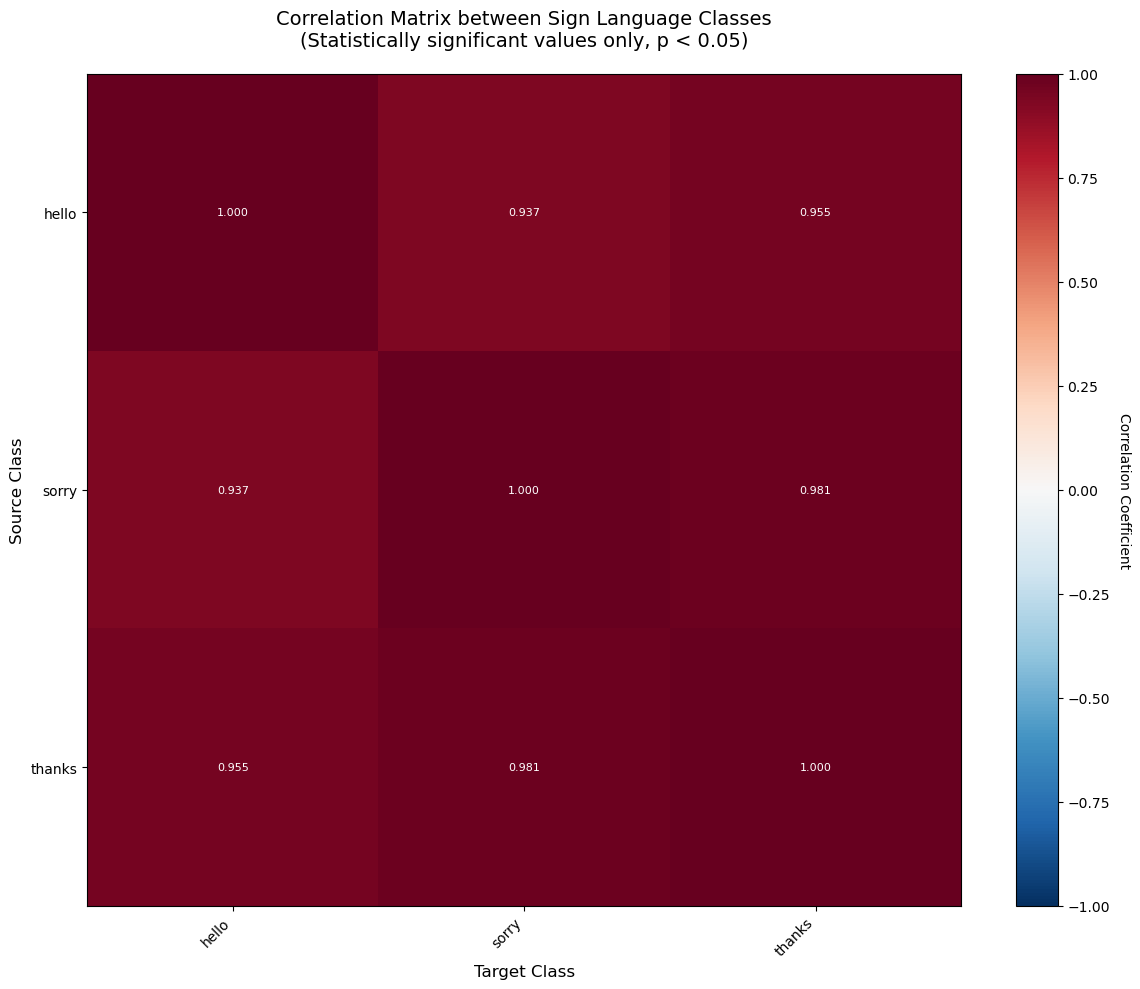

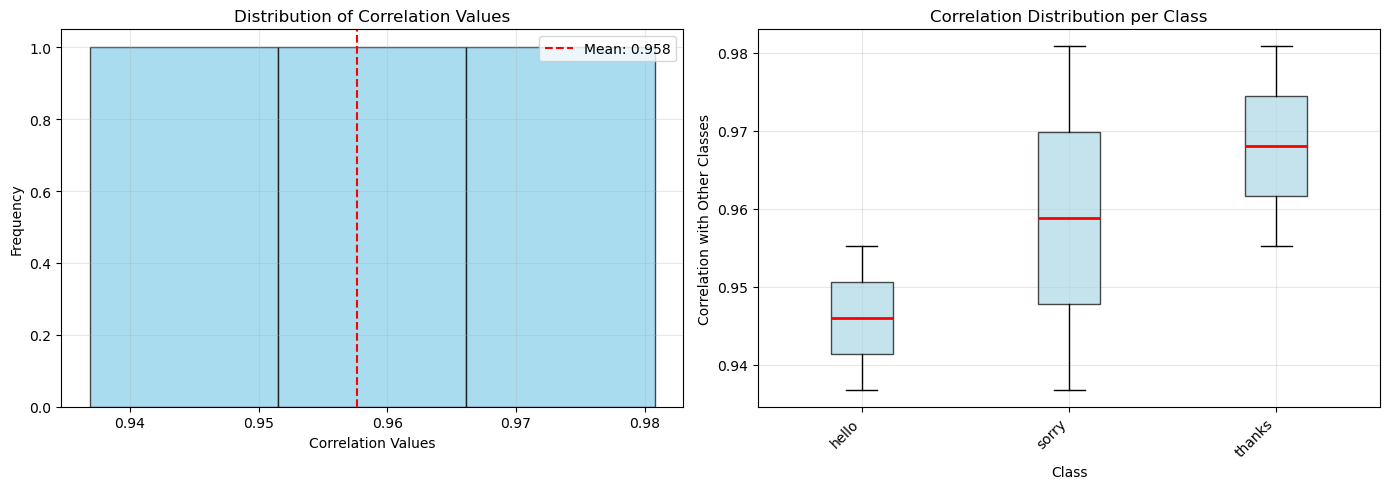

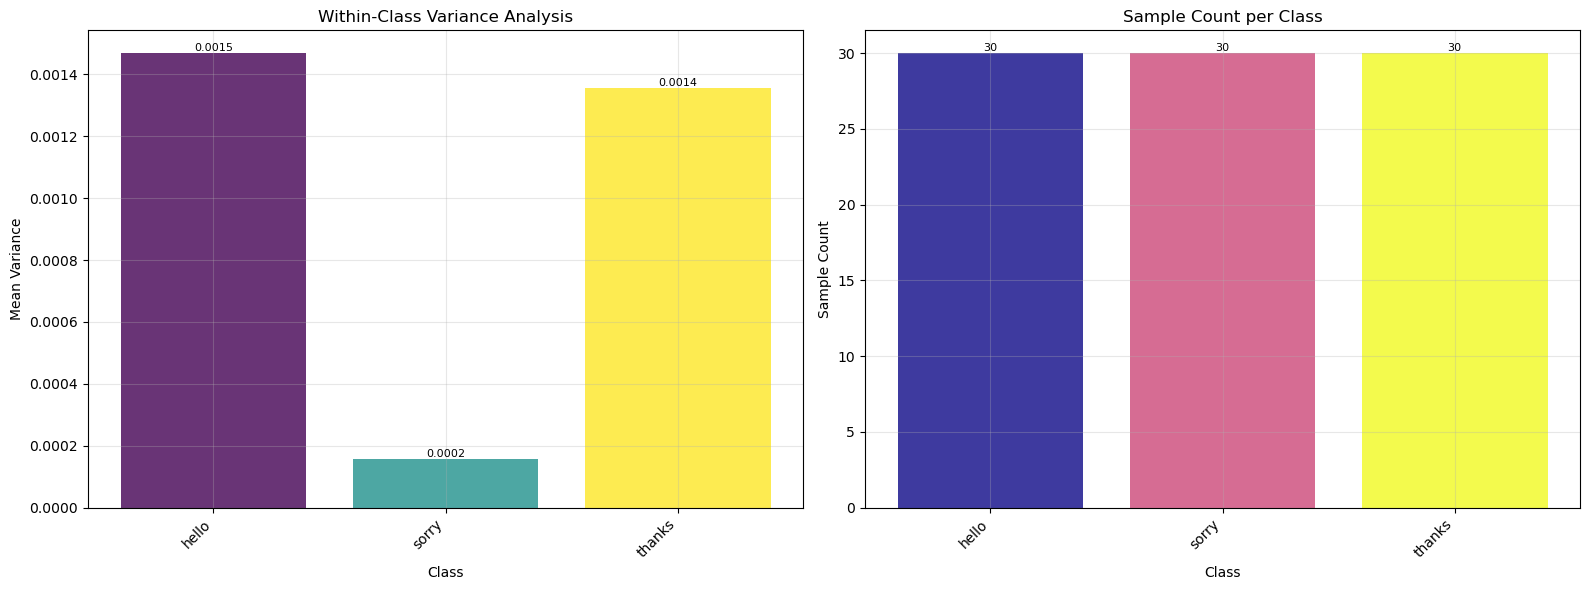


📈 สรุปผลการวิเคราะห์ Correlation

🔝 คู่คลาสที่มีความคล้ายคลึงสูงสุด (Top 5):
   1. sorry ↔ thanks: 0.9808
   2. hello ↔ thanks: 0.9553
   3. hello ↔ sorry: 0.9369

🔻 คู่คลาสที่มีความแตกต่างมากที่สุด (Bottom 5):
   1. sorry ↔ thanks: 0.9808
   2. hello ↔ thanks: 0.9553
   3. hello ↔ sorry: 0.9369

📊 สถิติ Correlation:
   • ค่าเฉลี่ย: 0.9576
   • ส่วนเบี่ยงเบนมาตรฐาน: 0.0180
   • ค่าสูงสุด: 0.9808
   • ค่าต่ำสุด: 0.9369

📊 สรุปความแปรปรวนภายในคลาส:
   คลาสที่มีความแปรปรวนสูงสุด (ท่าทางหลากหลาย):
      • hello: 0.001469 (30 ตัวอย่าง)
      • thanks: 0.001357 (30 ตัวอย่าง)
      • sorry: 0.000157 (30 ตัวอย่าง)
   คลาสที่มีความแปรปรวนต่ำสุด (ท่าทางสม่ำเสมอ):
      • hello: 0.001469 (30 ตัวอย่าง)
      • thanks: 0.001357 (30 ตัวอย่าง)
      • sorry: 0.000157 (30 ตัวอย่าง)

⚠️  คลาสที่อาจทำให้เกิดความสับสน (Correlation > 0.7):
   • hello ↔ sorry: 0.9369
   • hello ↔ thanks: 0.9553
   • sorry ↔ thanks: 0.9808
   👉 คลาสเหล่านี้อาจต้องเพิ่มข้อมูลหรือปรับปรุงคุณภาพ

✅ การวิเคราะห์เสร็จสิ้น!


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# กำหนด font ที่รองรับภาษาไทยและหาได้ง่าย
plt.rcParams['font.family'] = ['DejaVu Sans', 'Tahoma', 'Arial']
plt.rcParams['font.size'] = 10

def calculate_pearson_correlation(x, y):
    """คำนวณ Pearson correlation coefficient"""
    try:
        from scipy.stats import pearsonr
        return pearsonr(x, y)
    except ImportError:
        print("⚠️ ไม่พบ scipy, ใช้การคำนวณแบบ manual")
        # คำนวณแบบ manual
        x_mean = np.mean(x)
        y_mean = np.mean(y)
        
        numerator = np.sum((x - x_mean) * (y - y_mean))
        denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))
        
        if denominator == 0:
            return 0.0, 1.0
        
        correlation = numerator / denominator
        # p-value คำนวณแบบง่าย
        n = len(x)
        if n > 2 and abs(correlation) < 0.999:
            t_stat = correlation * np.sqrt((n-2)/(1-correlation**2))
            # ประมาณ p-value อย่างง่าย
            p_value = min(2 * (1 - abs(t_stat)/10), 1.0) if abs(t_stat) < 10 else 0.001
        else:
            p_value = 1.0 if abs(correlation) < 0.999 else 0.001
        
        return correlation, abs(p_value)

# =====================
# กำหนดค่าและโหลดข้อมูล
# =====================
DATA_DIR = r"C:\Users\Admin\Documents\sign\Realtime-Sign-Language-Detection-Using-LSTM-Model-main\MP_Data"

def load_sign_language_data(data_dir):
    """โหลดข้อมูลจากไฟล์ .npy และจัดกลุ่มตามคลาส - แก้ไขให้รองรับ 1D arrays"""
    class_data = {}
    file_info = []
    
    print("🔍 กำลังโหลดข้อมูล...")
    
    for root, _, files in os.walk(data_dir):
        npy_files = [f for f in files if f.endswith(".npy")]
        
        if not npy_files:
            continue
            
        # ดึงชื่อคลาสจากชื่อโฟลเดอร์ parent (เช่น "thanks" จาก path ".../thanks/99/file.npy")
        path_parts = root.replace(data_dir, '').strip(os.sep).split(os.sep)
        if len(path_parts) >= 1 and path_parts[0]:
            class_name = path_parts[0]  # ใช้โฟลเดอร์แรก (เช่น "thanks")
        else:
            continue  # skip root folder
            
        print(f"📁 กำลังโหลดคลาส: {class_name} ({len(npy_files)} ไฟล์)")
        
        class_sequences = []
        
        for filename in npy_files:
            file_path = os.path.join(root, filename)
            try:
                # โหลด sequence data
                sequence = np.load(file_path)
                
                # แก้ไข: รองรับทั้ง 1D และ 2D arrays
                if len(sequence.shape) == 1:
                    # ถ้าเป็น 1D array (เช่น shape (1662,)) ใช้ข้อมูลโดยตรง
                    processed_sequence = sequence
                    print(f"✅ โหลดไฟล์ 1D: {filename} -> shape {sequence.shape}")
                    
                elif len(sequence.shape) == 2:
                    # ถ้าเป็น 2D array คำนวณค่าเฉลี่ยของแต่ละ keypoint จาก sequence
                    processed_sequence = np.mean(sequence, axis=0)
                    print(f"✅ โหลดไฟล์ 2D: {filename} -> shape {sequence.shape} -> avg shape {processed_sequence.shape}")
                    
                else:
                    print(f"[WARN] Shape ไม่รองรับ: {file_path} -> {sequence.shape}")
                    continue
                
                # เพิ่มข้อมูลเข้า class
                class_sequences.append(processed_sequence)
                
                file_info.append({
                    'filename': filename,
                    'class': class_name,
                    'original_shape': sequence.shape,
                    'processed_shape': processed_sequence.shape,
                    'path': file_path
                })
                    
            except Exception as e:
                print(f"[ERROR] โหลดไม่ได้: {file_path} -> {e}")
                continue
        
        # เพิ่มคลาสเฉพาะเมื่อมีข้อมูล
        if class_sequences:
            class_data[class_name] = np.array(class_sequences)
            print(f"✅ เพิ่มคลาส {class_name}: {len(class_sequences)} ตัวอย่าง, feature shape: {class_sequences[0].shape}")
        else:
            print(f"⚠️ ไม่พบข้อมูลที่ใช้ได้สำหรับคลาส {class_name}")
    
    return class_data, file_info

def calculate_class_correlations(class_data):
    """คำนวณ correlation ระหว่างคลาสต่างๆ"""
    class_names = list(class_data.keys())
    n_classes = len(class_names)
    
    if n_classes == 0:
        print("❌ ไม่มีคลาสข้อมูลสำหรับการคำนวณ correlation")
        return np.array([]), np.array([]), [], {}
    
    # คำนวณ centroid (จุดกึ่งกลาง) ของแต่ละคลาส
    class_centroids = {}
    for class_name, sequences in class_data.items():
        class_centroids[class_name] = np.mean(sequences, axis=0)
        print(f"📊 Centroid {class_name}: shape {class_centroids[class_name].shape}")
    
    # สร้าง correlation matrix ระหว่างคลาส
    correlation_matrix = np.zeros((n_classes, n_classes))
    p_values = np.zeros((n_classes, n_classes))
    
    print(f"\n🔍 คำนวณ correlation ระหว่าง {n_classes} คลาส...")
    
    for i, class1 in enumerate(class_names):
        for j, class2 in enumerate(class_names):
            if i == j:
                correlation_matrix[i, j] = 1.0
                p_values[i, j] = 0.0
            else:
                # คำนวณ correlation ระหว่าง centroid ของแต่ละคลาส
                try:
                    centroid1 = class_centroids[class1]
                    centroid2 = class_centroids[class2]
                    
                    # ตรวจสอบว่า centroids มี shape เหมือนกันหรือไม่
                    if centroid1.shape != centroid2.shape:
                        print(f"[WARN] Shape ไม่ตรงกัน: {class1} {centroid1.shape} vs {class2} {centroid2.shape}")
                        correlation_matrix[i, j] = 0.0
                        p_values[i, j] = 1.0
                        continue
                    
                    # คำนวณ correlation
                    corr, p_val = calculate_pearson_correlation(centroid1, centroid2)
                    correlation_matrix[i, j] = corr
                    p_values[i, j] = p_val
                    
                    print(f"✅ {class1} ↔ {class2}: correlation = {corr:.4f}, p-value = {p_val:.4f}")
                    
                except Exception as e:
                    print(f"[ERROR] คำนวณ correlation ระหว่าง {class1} และ {class2}: {e}")
                    correlation_matrix[i, j] = 0.0
                    p_values[i, j] = 1.0
    
    return correlation_matrix, p_values, class_names, class_centroids

def plot_class_correlation_heatmap(corr_matrix, class_names, p_values):
    """แสดง heatmap ของ correlation ระหว่างคลาส"""
    if len(class_names) == 0:
        print("⚠️ ไม่มีข้อมูลสำหรับสร้าง heatmap")
        return
        
    fig, ax = plt.subplots(figsize=(max(12, len(class_names)*0.8), max(10, len(class_names)*0.8)))
    
    # สร้าง masked matrix สำหรับค่าที่ไม่มีนัยสำคัญ
    masked_corr = corr_matrix.copy()
    masked_corr[p_values > 0.05] = 0  # ซ่อนค่าที่ p > 0.05
    
    # Plot heatmap
    im = ax.imshow(masked_corr, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    
    # เพิ่ม colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Correlation Coefficient', rotation=270, labelpad=15)
    
    # ตั้งค่า ticks และ labels
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    
    # เพิ่มค่า correlation ในแต่ละช่อง
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if p_values[i, j] <= 0.05:  # แสดงเฉพาะค่าที่มีนัยสำคัญ
                text_color = 'white' if abs(masked_corr[i, j]) > 0.5 else 'black'
                ax.text(j, i, f'{corr_matrix[i, j]:.3f}', 
                       ha='center', va='center', color=text_color, fontsize=8)
            else:
                ax.text(j, i, 'n.s.', ha='center', va='center', 
                       color='gray', fontsize=6, alpha=0.7)
    
    ax.set_title('Correlation Matrix between Sign Language Classes\n(Statistically significant values only, p < 0.05)', 
                 fontsize=14, pad=20)
    ax.set_xlabel('Target Class', fontsize=12)
    ax.set_ylabel('Source Class', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # แสดงกราฎเพิ่มเติม หากมีมากกว่า 1 คลาส
    if len(class_names) > 1:
        fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # กราฟ 1: Histogram ของ correlation values
        corr_values = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
        if len(corr_values) > 0:
            ax1.hist(corr_values, bins=min(20, len(corr_values)), alpha=0.7, color='skyblue', edgecolor='black')
            ax1.set_xlabel('Correlation Values')
            ax1.set_ylabel('Frequency')
            ax1.set_title('Distribution of Correlation Values')
            ax1.axvline(np.mean(corr_values), color='red', linestyle='--', 
                        label=f'Mean: {np.mean(corr_values):.3f}')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'ไม่มีข้อมูล correlation', ha='center', va='center', transform=ax1.transAxes)
        
        # กราฟ 2: การกระจายของ correlation ในแต่ละคลาส
        box_data = []
        box_labels = []
        
        for i in range(len(class_names)):
            other_corrs = [corr_matrix[i, j] for j in range(len(class_names)) if i != j]
            if other_corrs:
                box_data.append(other_corrs)
                box_labels.append(class_names[i])
        
        if box_data:
            try:
                bp = ax2.boxplot(box_data, patch_artist=True,
                            boxprops=dict(facecolor='lightblue', alpha=0.7),
                            medianprops=dict(color='red', linewidth=2))
                ax2.set_ylabel('Correlation with Other Classes')
                ax2.set_xlabel('Class')
                ax2.set_title('Correlation Distribution per Class')
                ax2.set_xticklabels(box_labels, rotation=45, ha='right')
                ax2.grid(True, alpha=0.3)
            except Exception as e:
                print(f"[WARN] ไม่สามารถสร้าง boxplot ได้: {e}")
                # สร้างกราฟแบบ scatter แทน
                for i, data in enumerate(box_data):
                    ax2.scatter([i+1]*len(data), data, alpha=0.6, s=30)
                ax2.set_ylabel('Correlation with Other Classes')
                ax2.set_xlabel('Class')
                ax2.set_title('Correlation Scatter per Class')
                ax2.set_xticks(range(1, len(box_labels)+1))
                ax2.set_xticklabels(box_labels, rotation=45, ha='right')
                ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'ไม่มีข้อมูลเพียงพอ', ha='center', va='center', transform=ax2.transAxes)
        
        plt.tight_layout()
        plt.show()

def analyze_within_class_variance(class_data):
    """วิเคราะห์ความแปรปรวนภายในคลาส"""
    variance_stats = {}
    
    print("\n📊 วิเคราะห์ความแปรปรวนภายในคลาส...")
    
    for class_name, sequences in class_data.items():
        if len(sequences) > 1:
            try:
                # คำนวณความแปรปรวนของแต่ละ feature
                variances = np.var(sequences, axis=0)
                
                variance_stats[class_name] = {
                    'mean_variance': np.mean(variances),
                    'max_variance': np.max(variances),
                    'min_variance': np.min(variances),
                    'std_variance': np.std(variances),
                    'sample_count': len(sequences)
                }
                print(f"✅ {class_name}: mean_var={variance_stats[class_name]['mean_variance']:.6f}, samples={len(sequences)}")
            except Exception as e:
                print(f"[ERROR] คำนวณ variance สำหรับ {class_name}: {e}")
        else:
            print(f"[WARN] คลาส {class_name} มีข้อมูลน้อยเกินไป ({len(sequences)} ตัวอย่าง)")
    
    return variance_stats

def plot_variance_analysis(variance_stats):
    """แสดงกราฟวิเคราะห์ความแปรปรวน"""
    if not variance_stats:
        print("⚠️ ไม่มีข้อมูล variance เพียงพอสำหรับการแสดงกราฟ")
        return
        
    classes = list(variance_stats.keys())
    mean_vars = [variance_stats[c]['mean_variance'] for c in classes]
    sample_counts = [variance_stats[c]['sample_count'] for c in classes]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # กราฟ 1: ความแปรปรวนเฉลี่ยของแต่ละคลาส
    colors = plt.cm.viridis(np.linspace(0, 1, len(classes)))
    bars1 = ax1.bar(range(len(classes)), mean_vars, color=colors, alpha=0.8)
    ax1.set_xlabel('Class')
    ax1.set_ylabel('Mean Variance')
    ax1.set_title('Within-Class Variance Analysis')
    ax1.set_xticks(range(len(classes)))
    ax1.set_xticklabels(classes, rotation=45, ha='right')
    ax1.grid(True, alpha=0.3)
    
    # เพิ่มค่าบนแท่ง
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=8)
    
    # กราฟ 2: จำนวนตัวอย่างในแต่ละคลาส
    colors2 = plt.cm.plasma(np.linspace(0, 1, len(classes)))
    bars2 = ax2.bar(range(len(classes)), sample_counts, color=colors2, alpha=0.8)
    ax2.set_xlabel('Class')
    ax2.set_ylabel('Sample Count')
    ax2.set_title('Sample Count per Class')
    ax2.set_xticks(range(len(classes)))
    ax2.set_xticklabels(classes, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)
    
    # เพิ่มค่าบนแท่ง
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

def print_correlation_summary(corr_matrix, class_names, variance_stats):
    """พิมพ์สรุปผลการวิเคราะห์"""
    print("\n" + "="*60)
    print("📈 สรุปผลการวิเคราะห์ Correlation")
    print("="*60)
    
    if len(class_names) < 2:
        print("⚠️ ต้องการอย่างน้อย 2 คลาสสำหรับการวิเคราะห์ correlation")
        return
    
    # หาค่า correlation ที่สูงและต่ำที่สุด
    n = len(class_names)
    correlations = []
    
    for i in range(n):
        for j in range(i+1, n):
            correlations.append((class_names[i], class_names[j], corr_matrix[i, j]))
    
    if not correlations:
        print("⚠️ ไม่มีข้อมูล correlation เพียงพอสำหรับการสรุป")
        return
    
    # เรียงตาม correlation
    correlations.sort(key=lambda x: x[2], reverse=True)
    
    print(f"\n🔝 คู่คลาสที่มีความคล้ายคลึงสูงสุด (Top 5):")
    for i, (class1, class2, corr) in enumerate(correlations[:min(5, len(correlations))]):
        print(f"   {i+1}. {class1} ↔ {class2}: {corr:.4f}")
    
    print(f"\n🔻 คู่คลาสที่มีความแตกต่างมากที่สุด (Bottom 5):")
    for i, (class1, class2, corr) in enumerate(correlations[-min(5, len(correlations)):]):
        print(f"   {i+1}. {class1} ↔ {class2}: {corr:.4f}")
    
    # สถิติเพิ่มเติม
    corr_vals = [corr for _, _, corr in correlations]
    mean_corr = np.mean(corr_vals)
    std_corr = np.std(corr_vals)
    print(f"\n📊 สถิติ Correlation:")
    print(f"   • ค่าเฉลี่ย: {mean_corr:.4f}")
    print(f"   • ส่วนเบี่ยงเบนมาตรฐาน: {std_corr:.4f}")
    print(f"   • ค่าสูงสุด: {max(corr_vals):.4f}")
    print(f"   • ค่าต่ำสุด: {min(corr_vals):.4f}")
    
    # สรุปความแปรปรวน
    if variance_stats:
        print(f"\n📊 สรุปความแปรปรวนภายในคลาส:")
        sorted_variance = sorted(variance_stats.items(), 
                                key=lambda x: x[1]['mean_variance'], reverse=True)
        
        print("   คลาสที่มีความแปรปรวนสูงสุด (ท่าทางหลากหลาย):")
        for class_name, stats in sorted_variance[:min(3, len(sorted_variance))]:
            print(f"      • {class_name}: {stats['mean_variance']:.6f} ({stats['sample_count']} ตัวอย่าง)")
        
        print("   คลาสที่มีความแปรปรวนต่ำสุด (ท่าทางสม่ำเสมอ):")
        for class_name, stats in sorted_variance[-min(3, len(sorted_variance)):]:
            print(f"      • {class_name}: {stats['mean_variance']:.6f} ({stats['sample_count']} ตัวอย่าง)")

# =====================
# Main Analysis
# =====================
if __name__ == "__main__":
    print("🚀 เริ่มต้นการวิเคราะห์ Correlation ของ Dataset ภาษามือ")
    print("="*60)
    
    # ตรวจสอบโฟลเดอร์
    if not os.path.exists(DATA_DIR):
        print(f"❌ ไม่พบโฟลเดอร์: {DATA_DIR}")
        print("👉 กรุณาแก้ไข DATA_DIR ให้ถูกต้อง")
        exit(1)
    
    try:
        # 1. โหลดข้อมูล
        class_data, file_info = load_sign_language_data(DATA_DIR)
        
        if not class_data:
            print("❌ ไม่พบข้อมูลที่ใช้ได้ใน dataset")
            print("💡 ตรวจสอบว่า:")
            print("   1. ไฟล์ .npy มีข้อมูลที่ถูกต้อง")
            print("   2. โครงสร้างโฟลเดอร์เป็น: DATA_DIR/class_name/subfolder/file.npy")
            print("   3. Shape ของข้อมูลเป็น 1D หรือ 2D array")
            exit(1)
        
        print(f"\n✅ โหลดข้อมูลสำเร็จ:")
        print(f"   • จำนวนคลาส: {len(class_data)}")
        print(f"   • จำนวนไฟล์ทั้งหมด: {len(file_info)}")
        
        # แสดงรายชื่อคลาส
        print(f"\n📋 รายชื่อคลาส:")
        total_samples = 0
        for i, (class_name, sequences) in enumerate(class_data.items(), 1):
            print(f"   {i:2d}. {class_name} ({len(sequences)} ตัวอย่าง, feature dims: {sequences.shape[1]})")
            total_samples += len(sequences)
        print(f"   รวม: {total_samples} ตัวอย่าง")
        
        # 2. คำนวณ correlation ระหว่างคลาส
        corr_matrix, p_values, class_names, centroids = calculate_class_correlations(class_data)
        
        if len(class_names) == 0:
            print("❌ ไม่สามารถคำนวณ correlation ได้")
            exit(1)
        
        # 3. วิเคราะห์ความแปรปรวนภายในคลาส
        variance_stats = analyze_within_class_variance(class_data)
        
        # 4. แสดงกราฟ
        plot_class_correlation_heatmap(corr_matrix, class_names, p_values)
        plot_variance_analysis(variance_stats)
        
        # 5. พิมพ์สรุป
        print_correlation_summary(corr_matrix, class_names, variance_stats)
        
        # 6. หาคลาสที่อาจทำให้เกิดความผิดพลาดในการทำนาย
        if len(class_names) > 1:
            similar_pairs = []
            for i in range(len(class_names)):
                for j in range(i+1, len(class_names)):
                    corr_val = corr_matrix[i, j]
                    if corr_val > 0.7:
                        similar_pairs.append((class_names[i], class_names[j], corr_val))
            
            if similar_pairs:
                print(f"\n⚠️  คลาสที่อาจทำให้เกิดความสับสน (Correlation > 0.7):")
                for class1, class2, corr in similar_pairs:
                    print(f"   • {class1} ↔ {class2}: {corr:.4f}")
                print("   👉 คลาสเหล่านี้อาจต้องเพิ่มข้อมูลหรือปรับปรุงคุณภาพ")
            else:
                print(f"\n✅ ไม่พบคลาสที่มีความคล้ายคลึงสูงเกินไป")
        
        print(f"\n✅ การวิเคราะห์เสร็จสิ้น!")
        
    except Exception as e:
        print(f"\n❌ เกิดข้อผิดพลาดในการวิเคราะห์: {e}")
        import traceback
        print("รายละเอียดข้อผิดพลาด:")
        traceback.print_exc()
        
    print("="*60)

# 3fix dataset

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import shutil
from collections import defaultdict, Counter
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings('ignore')

# กำหนด font ที่รองรับภาษาไทย
plt.rcParams['font.family'] = ['DejaVu Sans', 'Tahoma', 'Arial']
plt.rcParams['font.size'] = 10

class SignLanguageDatasetQualityImprover:
    """คลาสสำหรับปรับปรุงคุณภาพของ dataset ภาษามือ"""
    
    def __init__(self, data_dir, output_dir=None):
        self.data_dir = data_dir
        self.output_dir = output_dir or os.path.join(data_dir, "_improved_dataset")
        self.class_data = {}
        self.quality_report = {}
        self.outliers = {}
        self.duplicates = {}
        
        # สร้างโฟลเดอร์ output
        os.makedirs(self.output_dir, exist_ok=True)
        
    def load_dataset(self):
        """โหลด dataset และจัดระเบียบข้อมูล"""
        print("🔍 กำลังโหลดและวิเคราะห์ dataset...")
        
        file_info = []
        
        for root, _, files in os.walk(self.data_dir):
            if root == self.output_dir or self.output_dir in root:
                continue  # ข้าม output directory
                
            npy_files = [f for f in files if f.endswith(".npy")]
            
            if not npy_files:
                continue
                
            # ดึงชื่อคลาสจาก path
            path_parts = root.replace(self.data_dir, '').strip(os.sep).split(os.sep)
            if len(path_parts) >= 1 and path_parts[0]:
                class_name = path_parts[0]
            else:
                continue
                
            print(f"📁 โหลดคลาส: {class_name} ({len(npy_files)} ไฟล์)")
            
            class_sequences = []
            class_files = []
            
            for filename in npy_files:
                file_path = os.path.join(root, filename)
                try:
                    sequence = np.load(file_path)
                    
                    # ตรวจสอบและแปลงข้อมูล
                    if len(sequence.shape) == 1:
                        processed_sequence = sequence
                    elif len(sequence.shape) == 2:
                        processed_sequence = sequence.flatten() if sequence.shape[0] == 1 else np.mean(sequence, axis=0)
                    else:
                        print(f"[WARN] Shape ไม่รองรับ: {file_path} -> {sequence.shape}")
                        continue
                    
                    # ตรวจสอบข้อมูล NaN หรือ Inf
                    if np.any(np.isnan(processed_sequence)) or np.any(np.isinf(processed_sequence)):
                        print(f"[WARN] พบ NaN/Inf: {file_path}")
                        # แทนที่ NaN/Inf ด้วย 0
                        processed_sequence = np.nan_to_num(processed_sequence, nan=0.0, posinf=0.0, neginf=0.0)
                    
                    class_sequences.append(processed_sequence)
                    class_files.append({
                        'filename': filename,
                        'path': file_path,
                        'original_shape': sequence.shape,
                        'processed_shape': processed_sequence.shape
                    })
                    
                    file_info.append({
                        'class': class_name,
                        'filename': filename,
                        'path': file_path,
                        'shape': processed_sequence.shape,
                        'mean': np.mean(processed_sequence),
                        'std': np.std(processed_sequence),
                        'min': np.min(processed_sequence),
                        'max': np.max(processed_sequence)
                    })
                    
                except Exception as e:
                    print(f"[ERROR] โหลด {file_path}: {e}")
                    continue
            
            if class_sequences:
                self.class_data[class_name] = {
                    'data': np.array(class_sequences),
                    'files': class_files
                }
        
        return file_info
    
    def detect_outliers(self, method='isolation_forest', contamination=0.1):
        """ตรวจจับ outliers ในแต่ละคลาส"""
        print(f"\n🔍 ตรวจจับ outliers ด้วยวิธี {method}...")
        
        for class_name, class_info in self.class_data.items():
            data = class_info['data']
            
            if len(data) < 3:
                print(f"[WARN] คลาส {class_name} มีข้อมูลน้อยเกินไป ({len(data)} ตัวอย่าง)")
                continue
            
            print(f"📊 ตรวจสอบคลาส {class_name} ({len(data)} ตัวอย่าง)...")
            
            outlier_indices = []
            
            if method == 'isolation_forest':
                try:
                    from sklearn.ensemble import IsolationForest
                    clf = IsolationForest(contamination=contamination, random_state=42)
                    outlier_pred = clf.fit_predict(data)
                    outlier_indices = np.where(outlier_pred == -1)[0]
                except ImportError:
                    print("⚠️ ไม่พบ sklearn, ใช้วิธี statistical แทน")
                    method = 'statistical'
            
            if method == 'statistical':
                # ใช้ Z-score สำหรับหา outliers
                z_scores = np.abs((data - np.mean(data, axis=0)) / (np.std(data, axis=0) + 1e-8))
                outlier_indices = np.where(np.mean(z_scores, axis=1) > 3)[0]
            
            elif method == 'iqr':
                # ใช้ IQR method
                Q1 = np.percentile(data, 25, axis=0)
                Q3 = np.percentile(data, 75, axis=0)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                
                outlier_mask = np.any((data < lower_bound) | (data > upper_bound), axis=1)
                outlier_indices = np.where(outlier_mask)[0]
            
            elif method == 'dbscan':
                # ใช้ DBSCAN clustering
                try:
                    # ปรับขนาดข้อมูลก่อน
                    scaler = StandardScaler()
                    data_scaled = scaler.fit_transform(data)
                    
                    # ใช้ PCA ลดมิติถ้าข้อมูลมีมิติสูงเกินไป
                    if data_scaled.shape[1] > 50:
                        pca = PCA(n_components=50)
                        data_scaled = pca.fit_transform(data_scaled)
                    
                    dbscan = DBSCAN(eps=0.5, min_samples=max(2, len(data)//10))
                    labels = dbscan.fit_predict(data_scaled)
                    
                    # จุดที่ถูกจัดเป็น noise (-1) ถือเป็น outliers
                    outlier_indices = np.where(labels == -1)[0]
                except Exception as e:
                    print(f"[ERROR] DBSCAN failed: {e}, ใช้ statistical แทน")
                    z_scores = np.abs((data - np.mean(data, axis=0)) / (np.std(data, axis=0) + 1e-8))
                    outlier_indices = np.where(np.mean(z_scores, axis=1) > 3)[0]
            
            self.outliers[class_name] = outlier_indices
            
            if len(outlier_indices) > 0:
                print(f"   🚨 พบ outliers: {len(outlier_indices)} ตัวอย่าง ({len(outlier_indices)/len(data)*100:.1f}%)")
            else:
                print(f"   ✅ ไม่พบ outliers")
    
    def detect_duplicates(self, threshold=0.99):
        """ตรวจจับข้อมูลที่ซ้ำกัน"""
        print(f"\n🔍 ตรวจจับข้อมูลซ้ำ (similarity > {threshold})...")
        
        for class_name, class_info in self.class_data.items():
            data = class_info['data']
            
            if len(data) < 2:
                continue
            
            print(f"📊 ตรวจสอบคลาส {class_name}...")
            
            duplicate_pairs = []
            
            # คำนวณ cosine similarity ระหว่างตัวอย่าง
            for i in range(len(data)):
                for j in range(i+1, len(data)):
                    vec1 = data[i]
                    vec2 = data[j]
                    
                    # คำนวณ cosine similarity
                    dot_product = np.dot(vec1, vec2)
                    norm1 = np.linalg.norm(vec1)
                    norm2 = np.linalg.norm(vec2)
                    
                    if norm1 == 0 or norm2 == 0:
                        similarity = 0
                    else:
                        similarity = dot_product / (norm1 * norm2)
                    
                    if similarity > threshold:
                        duplicate_pairs.append((i, j, similarity))
            
            self.duplicates[class_name] = duplicate_pairs
            
            if len(duplicate_pairs) > 0:
                print(f"   🔄 พบข้อมูลคล้าย: {len(duplicate_pairs)} คู่")
            else:
                print(f"   ✅ ไม่พบข้อมูลซ้ำ")
    
    def normalize_data(self, method='standard'):
        """ปรับข้อมูลให้เป็นมาตรฐาน"""
        print(f"\n🔧 ปรับข้อมูลให้เป็นมาตรฐานด้วย {method} scaling...")
        
        for class_name, class_info in self.class_data.items():
            data = class_info['data']
            
            print(f"📊 ปรับคลาส {class_name}...")
            
            if method == 'standard':
                scaler = StandardScaler()
            elif method == 'minmax':
                scaler = MinMaxScaler()
            elif method == 'robust':
                try:
                    from sklearn.preprocessing import RobustScaler
                    scaler = RobustScaler()
                except ImportError:
                    print("⚠️ ไม่พบ RobustScaler, ใช้ StandardScaler แทน")
                    scaler = StandardScaler()
            else:
                print(f"[WARN] ไม่รองรับ method {method}, ใช้ standard แทน")
                scaler = StandardScaler()
            
            try:
                normalized_data = scaler.fit_transform(data)
                self.class_data[class_name]['normalized_data'] = normalized_data
                self.class_data[class_name]['scaler'] = scaler
                
                # บันทึกสถิติ
                print(f"   📈 ก่อนปรับ: mean={np.mean(data):.4f}, std={np.std(data):.4f}")
                print(f"   📊 หลังปรับ: mean={np.mean(normalized_data):.4f}, std={np.std(normalized_data):.4f}")
                
            except Exception as e:
                print(f"[ERROR] ปรับข้อมูลคลาส {class_name}: {e}")
    
    def balance_dataset(self, method='undersample', target_samples_per_class=None):
        """ปรับสมดุลข้อมูลในแต่ละคลาส"""
        print(f"\n⚖️ ปรับสมดุล dataset ด้วย {method}...")
        
        # นับจำนวนตัวอย่างในแต่ละคลาส
        class_counts = {name: len(info['data']) for name, info in self.class_data.items()}
        
        if not target_samples_per_class:
            if method == 'undersample':
                target_samples_per_class = min(class_counts.values())
            else:  # oversample
                target_samples_per_class = max(class_counts.values())
        
        print(f"🎯 เป้าหมาย: {target_samples_per_class} ตัวอย่างต่อคลาส")
        
        for class_name, class_info in self.class_data.items():
            current_count = len(class_info['data'])
            print(f"📊 คลาส {class_name}: {current_count} -> ", end="")
            
            if current_count == target_samples_per_class:
                print("ไม่ต้องปรับ")
                continue
            
            elif current_count > target_samples_per_class:
                # Undersample
                indices = np.random.choice(current_count, target_samples_per_class, replace=False)
                
                self.class_data[class_name]['data'] = class_info['data'][indices]
                if 'normalized_data' in class_info:
                    self.class_data[class_name]['normalized_data'] = class_info['normalized_data'][indices]
                
                # อัปเดตรายชื่อไฟล์
                new_files = [class_info['files'][i] for i in indices]
                self.class_data[class_name]['files'] = new_files
                
                print(f"{target_samples_per_class} (undersample)")
                
            else:
                # Oversample
                needed = target_samples_per_class - current_count
                
                # สุ่มตัวอย่างเพิ่มเติม (with replacement)
                additional_indices = np.random.choice(current_count, needed, replace=True)
                
                # เพิ่ม noise เล็กน้อยเพื่อไม่ให้ข้อมูลเหมือนกันทุกประการ
                additional_data = class_info['data'][additional_indices]
                noise = np.random.normal(0, 0.01, additional_data.shape)
                additional_data_noisy = additional_data + noise
                
                # รวมข้อมูล
                self.class_data[class_name]['data'] = np.vstack([
                    class_info['data'], 
                    additional_data_noisy
                ])
                
                if 'normalized_data' in class_info:
                    additional_normalized = class_info['normalized_data'][additional_indices] + noise
                    self.class_data[class_name]['normalized_data'] = np.vstack([
                        class_info['normalized_data'],
                        additional_normalized
                    ])
                
                # อัปเดตรายชื่อไฟล์ (สร้างชื่อใหม่สำหรับข้อมูลที่ oversample)
                additional_files = []
                for i, idx in enumerate(additional_indices):
                    original_file = class_info['files'][idx]
                    new_file = original_file.copy()
                    new_file['filename'] = f"augmented_{i}_{original_file['filename']}"
                    additional_files.append(new_file)
                
                self.class_data[class_name]['files'].extend(additional_files)
                
                print(f"{target_samples_per_class} (oversample +{needed})")
    
    def remove_outliers_and_duplicates(self):
        """ลบ outliers และข้อมูลซ้ำ"""
        print("\n🗑️ ลบ outliers และข้อมูลซ้ำ...")
        
        for class_name in self.class_data.keys():
            print(f"🧹 ทำความสะอาดคลาส {class_name}...")
            
            # รวม indices ที่ต้องลบ
            indices_to_remove = set()
            
            # เพิ่ม outliers
            if class_name in self.outliers:
                indices_to_remove.update(self.outliers[class_name])
                print(f"   🚨 จะลบ outliers: {len(self.outliers[class_name])} ตัวอย่าง")
            
            # เพิ่ม duplicates (เก็บแค่ตัวแรกของแต่ละคู่)
            if class_name in self.duplicates:
                for i, j, similarity in self.duplicates[class_name]:
                    indices_to_remove.add(j)  # ลบตัวที่สอง
                print(f"   🔄 จะลบ duplicates: {len(set(j for _, j, _ in self.duplicates[class_name]))} ตัวอย่าง")
            
            if indices_to_remove:
                original_count = len(self.class_data[class_name]['data'])
                
                # สร้าง mask สำหรับข้อมูลที่จะเก็บ
                keep_indices = [i for i in range(original_count) if i not in indices_to_remove]
                
                # อัปเดตข้อมูล
                self.class_data[class_name]['data'] = self.class_data[class_name]['data'][keep_indices]
                if 'normalized_data' in self.class_data[class_name]:
                    self.class_data[class_name]['normalized_data'] = self.class_data[class_name]['normalized_data'][keep_indices]
                
                # อัปเดตรายชื่อไฟล์
                new_files = [self.class_data[class_name]['files'][i] for i in keep_indices]
                self.class_data[class_name]['files'] = new_files
                
                new_count = len(self.class_data[class_name]['data'])
                print(f"   ✅ {class_name}: {original_count} -> {new_count} ตัวอย่าง (ลบ {len(indices_to_remove)} ตัว)")
            else:
                print(f"   ✅ {class_name}: ไม่มีข้อมูลที่ต้องลบ")
    
    def generate_quality_report(self):
        """สร้างรายงานคุณภาพข้อมูล"""
        print("\n📋 สร้างรายงานคุณภาพข้อมูล...")
        
        report = {
            'dataset_summary': {},
            'class_details': {},
            'quality_metrics': {},
            'recommendations': []
        }
        
        # สรุปรวม
        total_samples = sum(len(info['data']) for info in self.class_data.values())
        total_classes = len(self.class_data)
        
        report['dataset_summary'] = {
            'total_classes': total_classes,
            'total_samples': total_samples,
            'avg_samples_per_class': total_samples / total_classes if total_classes > 0 else 0,
            'feature_dimensions': self.class_data[list(self.class_data.keys())[0]]['data'].shape[1] if self.class_data else 0
        }
        
        # รายละเอียดแต่ละคลาส
        class_stats = []
        for class_name, class_info in self.class_data.items():
            data = class_info['data']
            
            stats = {
                'class_name': class_name,
                'sample_count': len(data),
                'mean_feature_value': float(np.mean(data)),
                'std_feature_value': float(np.std(data)),
                'outliers_detected': len(self.outliers.get(class_name, [])),
                'duplicates_detected': len(self.duplicates.get(class_name, [])),
                'data_quality_score': 0.0
            }
            
            # คำนวณคะแนนคุณภาพ
            quality_score = 100.0
            
            # ลดคะแนนตาม outliers
            outlier_penalty = (stats['outliers_detected'] / stats['sample_count']) * 30
            quality_score -= outlier_penalty
            
            # ลดคะแนนตาม duplicates
            duplicate_penalty = (stats['duplicates_detected'] / stats['sample_count']) * 20
            quality_score -= duplicate_penalty
            
            # ลดคะแนนถ้าข้อมูลน้อยเกินไป
            if stats['sample_count'] < 10:
                quality_score -= 20
            elif stats['sample_count'] < 30:
                quality_score -= 10
            
            stats['data_quality_score'] = max(0.0, quality_score)
            
            report['class_details'][class_name] = stats
            class_stats.append(stats)
        
        # เมตริกคุณภาพรวม
        if class_stats:
            sample_counts = [s['sample_count'] for s in class_stats]
            quality_scores = [s['data_quality_score'] for s in class_stats]
            
            report['quality_metrics'] = {
                'average_quality_score': float(np.mean(quality_scores)),
                'min_quality_score': float(np.min(quality_scores)),
                'max_quality_score': float(np.max(quality_scores)),
                'sample_balance_ratio': float(np.min(sample_counts) / np.max(sample_counts)) if np.max(sample_counts) > 0 else 0,
                'total_outliers': sum(len(self.outliers.get(name, [])) for name in self.class_data.keys()),
                'total_duplicates': sum(len(self.duplicates.get(name, [])) for name in self.class_data.keys())
            }
        
        # ข้อแนะนำ
        recommendations = []
        
        if report['quality_metrics'].get('sample_balance_ratio', 1) < 0.5:
            recommendations.append("💡 ควรปรับสมดุลจำนวนตัวอย่างระหว่างคลาส")
        
        if report['quality_metrics'].get('total_outliers', 0) > total_samples * 0.05:
            recommendations.append("🚨 พบ outliers มากเกินไป ควรตรวจสอบคุณภาพการเก็บข้อมูล")
        
        if report['quality_metrics'].get('total_duplicates', 0) > total_samples * 0.1:
            recommendations.append("🔄 พบข้อมูลซ้ำมาก ควรลบข้อมูลที่ซ้ำกัน")
        
        if report['quality_metrics'].get('average_quality_score', 0) < 70:
            recommendations.append("⚠️ คุณภาพข้อมูลโดยรวมต่ำ ควรปรับปรุงก่อนใช้งาน")
        
        if any(stats['sample_count'] < 30 for stats in class_stats):
            recommendations.append("📊 บางคลาสมีข้อมูลน้อยเกินไป ควรเพิ่มตัวอย่าง")
        
        report['recommendations'] = recommendations
        
        self.quality_report = report
        return report
    
    def save_improved_dataset(self, use_normalized=True):
        """บันทึก dataset ที่ปรับปรุงแล้ว"""
        print(f"\n💾 บันทึก dataset ที่ปรับปรุงแล้วไปที่ {self.output_dir}...")
        
        # สร้างโฟลเดอร์สำหรับแต่ละคลาส
        for class_name, class_info in self.class_data.items():
            class_dir = os.path.join(self.output_dir, class_name)
            os.makedirs(class_dir, exist_ok=True)
            
            # เลือกข้อมูลที่จะบันทึก
            data_to_save = class_info.get('normalized_data', class_info['data']) if use_normalized else class_info['data']
            
            print(f"💾 บันทึกคลาส {class_name}: {len(data_to_save)} ตัวอย่าง")
            
            # บันทึกแต่ละตัวอย่าง
            for i, sample in enumerate(data_to_save):
                filename = f"improved_{i:04d}.npy"
                file_path = os.path.join(class_dir, filename)
                np.save(file_path, sample)
        
        # บันทึกรายงานคุณภาพ
        report_path = os.path.join(self.output_dir, "quality_report.json")
        with open(report_path, 'w', encoding='utf-8') as f:
            json.dump(self.quality_report, f, indent=2, ensure_ascii=False)
        
        # บันทึกสถิติการปรับปรุง
        improvement_log = {
            'original_total_samples': sum(len(files['files']) for files in self.class_data.values()),
            'improved_total_samples': sum(len(data['data']) for data in self.class_data.values()),
            'classes': list(self.class_data.keys()),
            'normalization_used': use_normalized,
            'outliers_removed': sum(len(outliers) for outliers in self.outliers.values()),
            'duplicates_removed': sum(len(set(j for _, j, _ in dups)) for dups in self.duplicates.values())
        }
        
        log_path = os.path.join(self.output_dir, "improvement_log.json")
        with open(log_path, 'w', encoding='utf-8') as f:
            json.dump(improvement_log, f, indent=2, ensure_ascii=False)
        
        print(f"✅ บันทึกเสร็จสิ้น:")
        print(f"   📁 Dataset: {self.output_dir}")
        print(f"   📋 รายงาน: {report_path}")
        print(f"   📊 Log: {log_path}")
    
    def plot_quality_analysis(self):
        """แสดงกราฟวิเคราะห์คุณภาพ"""
        print("\n📊 สร้างกราฟวิเคราะห์คุณภาพ...")
        
        if not self.class_data:
            print("⚠️ ไม่มีข้อมูลสำหรับสร้างกราฟ")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # กราฟ 1: จำนวนตัวอย่างในแต่ละคลาส
        class_names = list(self.class_data.keys())
        sample_counts = [len(info['data']) for info in self.class_data.values()]
        
        axes[0,0].bar(range(len(class_names)), sample_counts, color='skyblue', alpha=0.8)
        axes[0,0].set_title('จำนวนตัวอย่างในแต่ละคลาส')
        axes[0,0].set_xlabel('Class')
        axes[0,0].set_ylabel('Number of Samples')
        axes[0,0].set_xticks(range(len(class_names)))
        axes[0,0].set_xticklabels(class_names, rotation=45, ha='right')
        
        # เพิ่มค่าบนแท่ง
        for i, count in enumerate(sample_counts):
            axes[0,0].text(i, count + max(sample_counts)*0.01, str(count), 
                          ha='center', va='bottom', fontsize=10)
        
        # กราฟ 2: Outliers ในแต่ละคลาส
        outlier_counts = [len(self.outliers.get(name, [])) for name in class_names]
        
        axes[0,1].bar(range(len(class_names)), outlier_counts, color='salmon', alpha=0.8)
        axes[0,1].set_title('จำนวน Outliers ในแต่ละคลาส')
        axes[0,1].set_xlabel('Class')
        axes[0,1].set_ylabel('Number of Outliers')

# Preprocess Data and Create Labels and Features

In [ ]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ------------------------------ --------- 6.8/8.9 MB 38.1 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 32.5 MB/s  0:00:00
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- -

In [13]:
!pip install tensorflow

  Using cached tensorflow-2.20.0-cp310-cp310-win_amd64.whl.metadata (4.6 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached protobuf-6.32.1-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-1.17.3-cp310-cp310-win_amd64.whl.metadata (6.5 kB)
  Using cached grpcio-1.75.1-cp310-cp310-win_amd64.whl.metadata (3.8 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.11.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl.metadata (2.7 kB)
  Using cached markdown-3.9-py3-none-any.whl.metadata (5.1 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using c

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 6.32.1 which is incompatible.


In [14]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [15]:
label_map = {label:num for num, label in enumerate(actions)}

In [16]:
label_map

{'sorry': 0}

In [17]:
# วิเคราะห์ลำดับเฟรม โดยรองรับทั้ง .npy (คีย์พอยต์) และ .png (overlay/raw)
# หมายเหตุ: ใช้ .npy เป็นหลัก ถ้าไม่มีจะ fallback ไปอ่าน .png แล้วสกัดคีย์พอยต์ด้วย Mediapipe
# ต้องมีตัวแปรต่อไปนี้กำหนดไว้ก่อน: DATA_PATH, actions, sequence_length, label_map, extract_keypoints()

import os, numpy as np, cv2, mediapipe as mp

def _list_seq_ids(action_dir):
    return sorted([d for d in os.listdir(action_dir)
                   if d.isdigit() and os.path.isdir(os.path.join(action_dir, d))],
                  key=lambda x: int(x))

def _npy_path(base, action, seq, frame):
    return os.path.join(base, action, str(seq), f"{frame}.npy")

def _png_path(base, action, seq, frame):
    # ให้ลอง overlay ก่อน ถ้าไม่มีค่อยลอง raw
    root = os.path.join(base, action, str(seq))
    fname = f"{frame:03d}.png"
    cands = [os.path.join(root, "overlay_png", fname),
             os.path.join(root, "raw_png", fname)]
    for p in cands:
        if os.path.exists(p):
            return p
    return None

sequences, labels = [], []

mp_holistic = mp.solutions.holistic
with mp_holistic.Holistic(static_image_mode=True,
                          model_complexity=1,
                          enable_segmentation=False,
                          refine_face_landmarks=False) as holistic:
    for action in actions:
        action_dir = os.path.join(DATA_PATH, action)
        for sequence in _list_seq_ids(action_dir):
            window, ok = [], True
            for frame_num in range(sequence_length):
                npy_file = _npy_path(DATA_PATH, action, sequence, frame_num)
                if os.path.exists(npy_file):
                    res = np.load(npy_file, allow_pickle=True)
                else:
                    png_file = _png_path(DATA_PATH, action, sequence, frame_num)
                    if not png_file:
                        ok = False; break
                    img = cv2.imread(png_file)  # BGR
                    if img is None:
                        ok = False; break
                    # สกัดคีย์พอยต์จากภาพนิ่ง → ให้เข้ากับโมเดล LSTM เดิม (1662 ฟีเจอร์)
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    results = holistic.process(img_rgb)
                    res = extract_keypoints(results)  # ฟังก์ชันเดิมของโปรเจกต์
                    if not isinstance(res, np.ndarray) or res.size != 1662:
                        ok = False; break
                window.append(res)
            if ok and len(window) == sequence_length:
                sequences.append(window)
                labels.append(label_map[action])

sequences = np.array(sequences)  # shape: (N, T, 1662)
labels    = np.array(labels)


In [18]:
sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [19]:
X = np.array(sequences)

In [20]:
y = to_categorical(labels).astype(int)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

# Build and Train LSTM Neural Network

In [9]:
# ==== ENHANCED TRAINING PIPELINE WITH ANTI-OVERFITTING (70% Train, 30% Test) ====
import os, re, pickle, json, time
import numpy as np
from glob import glob
from collections import Counter
import matplotlib.pyplot as plt

# ML / DL
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, BatchNormalization, 
                                   Input, Bidirectional, Attention, MultiHeadAttention,
                                   LayerNormalization, GlobalAveragePooling1D,
                                   GaussianNoise, SpatialDropout1D)
from tensorflow.keras.callbacks import (ReduceLROnPlateau, TensorBoard, 
                                      ModelCheckpoint, EarlyStopping, CSVLogger)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.utils import plot_model

# CV / Mediapipe
import cv2
import mediapipe as mp

# --------------------------- Enhanced Config & Seeds ---------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Enhanced parameters - MODIFIED FOR 70/30 SPLIT WITH ANTI-OVERFITTING
DATA_PATH = 'MP_Data'
SEQ_LEN = 30
FEAT_DIM = 1662
LOG_DIR = 'Enhanced_Logs'
EPOCHS = 500
BATCH = 16
LEARNING_RATE = 0.0005  # ลดลงเพื่อป้องกัน overfitting
TEST_SPLIT = 0.30

# ⭐ ANTI-OVERFITTING PARAMETERS
DROPOUT_RATE = 0.5  # เพิ่ม dropout rate
RECURRENT_DROPOUT = 0.3  # dropout สำหรับ LSTM
L1_REG = 1e-4  # L1 regularization
L2_REG = 1e-3  # L2 regularization (เพิ่มขึ้น)
GAUSSIAN_NOISE = 0.1  # เพิ่ม noise layer
LABEL_SMOOTHING = 0.1  # label smoothing เพื่อลด overconfidence

# Data augmentation parameters - เพิ่มความแปรปรวน
AUGMENT_FACTOR = 4  # เพิ่มเป็น 4x
NOISE_FACTOR = 0.03  # เพิ่ม noise
ROTATION_ANGLE = 10
SCALE_FACTOR = 0.15
TIME_WARP_FACTOR = 0.2  # ใหม่: time warping

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

# ⭐ ENHANCED PROGRESS CALLBACK WITH OVERFITTING DETECTION
class ProgressCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.train_acc_history = []
        self.overfit_warnings = 0
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_acc = logs.get('accuracy', 0) * 100
        train_loss = logs.get('loss', 0)
        
        self.train_acc_history.append(train_acc)
        
        # ตรวจสอบ overfitting
        if len(self.train_acc_history) > 10:
            recent_trend = np.mean(self.train_acc_history[-5:]) - np.mean(self.train_acc_history[-10:-5])
            if recent_trend > 5:  # accuracy เพิ่มขึ้นเร็วเกินไป
                self.overfit_warnings += 1
                print(f"⚠️ OVERFITTING WARNING #{self.overfit_warnings}: Training accuracy increasing too rapidly!")
        
        print(f"\n📊 Epoch {epoch+1}/{self.params['epochs']}")
        print(f"🎯 Train Accuracy: {train_acc:.2f}% | Train Loss: {train_loss:.4f}")
        print(f"📈 Error Rate: {100-train_acc:.2f}%")
        
        # แสดงสถานะ regularization
        if hasattr(self.model.optimizer, 'learning_rate'):
            lr = float(self.model.optimizer.learning_rate)
            print(f"📉 Learning Rate: {lr:.6f}")
        
        print("-" * 60)

# --------------------------- Enhanced Utilities ---------------------------
def natural_key(s):
    return [int(t) if t.isdigit() else t for t in re.split(r'(\d+)', s)]

def list_numeric_dirs(d):
    return sorted([x for x in os.listdir(d) if x.isdigit() and os.path.isdir(os.path.join(d,x))],
                  key=lambda s: int(s))

# Enhanced Mediapipe setup
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

def extract_keypoints_enhanced(results) -> np.ndarray:
    """Enhanced keypoint extraction with confidence weighting"""
    pose = np.zeros(33*4, dtype=np.float32)
    face = np.zeros(468*3, dtype=np.float32)
    left = np.zeros(21*3, dtype=np.float32)
    right = np.zeros(21*3, dtype=np.float32)

    if getattr(results, "pose_landmarks", None):
        p = []
        for lm in results.pose_landmarks.landmark:
            vis = lm.visibility if hasattr(lm, 'visibility') else 1.0
            p.extend([lm.x * vis, lm.y * vis, lm.z * vis, vis])
        pose = np.array(p, dtype=np.float32)

    if getattr(results, "face_landmarks", None):
        f = []
        for lm in results.face_landmarks.landmark:
            f.extend([lm.x, lm.y, lm.z])
        face = np.array(f, dtype=np.float32)

    if getattr(results, "left_hand_landmarks", None):
        l = []
        for lm in results.left_hand_landmarks.landmark:
            l.extend([lm.x, lm.y, lm.z])
        left = np.array(l, dtype=np.float32)

    if getattr(results, "right_hand_landmarks", None):
        r = []
        for lm in results.right_hand_landmarks.landmark:
            r.extend([lm.x, lm.y, lm.z])
        right = np.array(r, dtype=np.float32)

    out = np.concatenate([pose, face, left, right], axis=0)
    
    if out.size != FEAT_DIM:
        pad = np.zeros(FEAT_DIM, dtype=np.float32)
        n = min(FEAT_DIM, out.size)
        pad[:n] = out[:n]
        out = pad
    
    return out

# ⭐ ENHANCED DATA AUGMENTATION WITH MORE VARIATION
def augment_sequence(seq, noise_factor=NOISE_FACTOR):
    """Apply enhanced data augmentation with more techniques"""
    aug_seq = seq.copy()
    
    # 1. Gaussian noise
    noise = np.random.normal(0, noise_factor, seq.shape)
    aug_seq = aug_seq + noise
    
    # 2. Time stretching (randomly drop/duplicate frames)
    if np.random.random() > 0.6:
        indices = sorted(np.random.choice(len(seq), len(seq), replace=True))
        aug_seq = aug_seq[indices]
    
    # 3. Time warping - เพิ่มความผันแปรทางเวลา
    if np.random.random() > 0.7:
        warp = np.random.uniform(1-TIME_WARP_FACTOR, 1+TIME_WARP_FACTOR)
        new_len = int(len(aug_seq) * warp)
        indices = np.linspace(0, len(aug_seq)-1, new_len).astype(int)
        aug_seq = aug_seq[indices]
        # Resize back to original length
        if len(aug_seq) != SEQ_LEN:
            indices = np.linspace(0, len(aug_seq)-1, SEQ_LEN).astype(int)
            aug_seq = aug_seq[indices]
    
    # 4. Feature scaling
    if np.random.random() > 0.7:
        scale = np.random.uniform(1-SCALE_FACTOR, 1+SCALE_FACTOR)
        aug_seq = aug_seq * scale
    
    # 5. Random masking - ซ่อนบางส่วนของข้อมูล
    if np.random.random() > 0.8:
        mask_frames = np.random.choice(SEQ_LEN, size=int(SEQ_LEN*0.1), replace=False)
        aug_seq[mask_frames] *= np.random.uniform(0.3, 0.7)
    
    # 6. Mixup augmentation - ผสมกับลำดับอื่น
    if np.random.random() > 0.9:
        alpha = np.random.beta(0.2, 0.2)
        aug_seq = alpha * aug_seq + (1-alpha) * seq
    
    return aug_seq.astype(np.float32)

def create_augmented_data(X, y, factor=AUGMENT_FACTOR):
    """Create augmented training data with variations"""
    X_aug, y_aug = [], []
    
    for i in range(len(X)):
        X_aug.append(X[i])
        y_aug.append(y[i])
        
        for _ in range(factor):
            aug_seq = augment_sequence(X[i])
            X_aug.append(aug_seq)
            y_aug.append(y[i])
    
    return np.array(X_aug), np.array(y_aug)

# Enhanced PNG processing
def png_path(seq_path: str, frame_num: int):
    fname = f"{frame_num:03d}.png"
    p1 = os.path.join(seq_path, "overlay_png", fname)
    p2 = os.path.join(seq_path, "raw_png", fname)
    if os.path.exists(p1): return p1
    if os.path.exists(p2): return p2
    return None

def load_keypoints_from_png_enhanced(png_file: str, holistic) -> np.ndarray:
    """Enhanced PNG processing"""
    img = cv2.imread(png_file)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {png_file}")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.convertScaleAbs(img_rgb, alpha=1.2, beta=10)
    img_rgb = cv2.GaussianBlur(img_rgb, (3, 3), 0)
    
    results = holistic.process(img_rgb)
    kp = extract_keypoints_enhanced(results)
    
    if kp.size != FEAT_DIM:
        raise ValueError(f"Unexpected keypoint size from {png_file}: {kp.shape}")
    
    return kp

def load_frame_keypoints_enhanced(seq_path: str, frame_num: int, holistic) -> np.ndarray:
    """Enhanced frame loading with fallback"""
    npy_file = os.path.join(seq_path, f"{frame_num}.npy")
    
    if os.path.exists(npy_file):
        kp = np.load(npy_file, allow_pickle=True).astype(np.float32)
        if kp.size == FEAT_DIM:
            return kp
    
    p_png = png_path(seq_path, frame_num)
    if p_png:
        return load_keypoints_from_png_enhanced(p_png, holistic).astype(np.float32)
    
    raise FileNotFoundError(f"No valid data for frame {frame_num} in {seq_path}")

# --------------------------- 1) Actions & Label Mapping ---------------------------
print("🔍 Scanning for action classes...")
actions = sorted([d for d in os.listdir(DATA_PATH) 
                 if os.path.isdir(os.path.join(DATA_PATH, d)) and not d.startswith('.')])

if not actions:
    raise RuntimeError("❌ No action classes found in MP_Data")

print(f"✅ Found {len(actions)} action classes: {actions}")

label_map = {action: idx for idx, action in enumerate(actions)}

np.save(os.path.join(DATA_PATH, 'label_map.npy'), label_map, allow_pickle=True)
with open(os.path.join(DATA_PATH, 'label_map.json'), 'w', encoding='utf-8') as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

# --------------------------- 2) Data Loading ---------------------------
print("\n📚 Loading sequences with enhanced processing...")
X, y = [], []
class_counts = Counter()

with mp_holistic.Holistic(
    static_image_mode=False,
    model_complexity=2,
    enable_segmentation=False,
    refine_face_landmarks=True,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.5
) as holistic:
    
    for action_idx, action in enumerate(actions):
        print(f"🔄 Processing action '{action}' ({action_idx+1}/{len(actions)})...")
        action_dir = os.path.join(DATA_PATH, action)
        
        if not os.path.isdir(action_dir):
            continue
            
        seq_folders = list_numeric_dirs(action_dir)
        action_sequences = 0
        
        for seq_folder in seq_folders:
            seq_path = os.path.join(action_dir, seq_folder)
            
            try:
                seq = []
                for frame_num in range(SEQ_LEN):
                    kp = load_frame_keypoints_enhanced(seq_path, frame_num, holistic)
                    seq.append(kp)
                
                seq = np.stack(seq, axis=0)
                
                if seq.shape != (SEQ_LEN, FEAT_DIM):
                    continue
                
                if np.sum(np.abs(seq)) < 1e-6:
                    continue
                
                X.append(seq.astype(np.float32))
                y.append(label_map[action])
                class_counts[action] += 1
                action_sequences += 1
                
            except Exception as e:
                print(f"⚠️ Skipped sequence {seq_path}: {str(e)}")
                continue
        
        print(f"✅ Loaded {action_sequences} sequences for '{action}'")

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y, dtype=np.int64)

print(f"\n📊 Dataset Statistics:")
print(f"Total sequences: {len(X)}")
print(f"Input shape: {X.shape}")
print(f"Class distribution: {dict(class_counts)}")

if len(X) == 0:
    raise RuntimeError("❌ No valid sequences found.")

# --------------------------- 3) Train/Test Split ---------------------------
print("\n🔀 Splitting data with 70% train, 30% test...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y
)

print(f"📈 Train set: {len(X_train)} sequences ({len(X_train)/len(X)*100:.1f}%)")
print(f"🧪 Test set: {len(X_test)} sequences ({len(X_test)/len(X)*100:.1f}%)")

# Data Augmentation
print("\n🔄 Applying enhanced data augmentation...")
X_train_aug, y_train_aug = create_augmented_data(X_train, y_train)
print(f"📈 Training set after augmentation: {len(X_train_aug)} sequences (from {len(X_train)})")

# --------------------------- 4) Feature Scaling ---------------------------
print("\n📏 Applying feature standardization...")

scaler = StandardScaler()
X_train_2d = X_train_aug.reshape(-1, FEAT_DIM)
scaler.fit(X_train_2d)

with open('enhanced_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

def transform_sequences(X_input):
    X_2d = X_input.reshape(-1, FEAT_DIM)
    X_scaled = scaler.transform(X_2d)
    return X_scaled.reshape(len(X_input), SEQ_LEN, FEAT_DIM)

X_train_scaled = transform_sequences(X_train_aug)
X_test_scaled = transform_sequences(X_test)

# --------------------------- 5) ⭐ ANTI-OVERFITTING MODEL ARCHITECTURE ---------------------------
print("\n🏗️ Building ANTI-OVERFITTING model architecture...")

def create_anti_overfit_model(input_shape, num_classes):
    """
    Enhanced model with comprehensive anti-overfitting techniques:
    - Increased Dropout
    - L1/L2 Regularization
    - Gaussian Noise
    - Batch Normalization
    - Spatial Dropout
    - Reduced model complexity
    """
    
    inputs = Input(shape=input_shape)
    
    # ⭐ เพิ่ม Gaussian Noise เพื่อป้องกัน overfitting
    x = GaussianNoise(GAUSSIAN_NOISE)(inputs)
    
    # First BiLSTM block - ลดขนาด units
    x = Bidirectional(LSTM(
        128,  # ลดจาก 256
        return_sequences=True,
        dropout=DROPOUT_RATE,
        recurrent_dropout=RECURRENT_DROPOUT,
        kernel_regularizer=l1_l2(l1=L1_REG, l2=L2_REG)
    ))(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.3)(x)  # ⭐ เพิ่ม Spatial Dropout
    
    # Second BiLSTM block
    x = Bidirectional(LSTM(
        64,  # ลดจาก 128
        return_sequences=True,
        dropout=DROPOUT_RATE,
        recurrent_dropout=RECURRENT_DROPOUT,
        kernel_regularizer=l1_l2(l1=L1_REG, l2=L2_REG)
    ))(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.2)(x)
    
    # Attention mechanism - ลด complexity
    x = MultiHeadAttention(
        num_heads=4,  # ลดจาก 8
        key_dim=32,   # ลดจาก 64
        dropout=0.3
    )(x, x)
    x = LayerNormalization()(x)
    
    # Final LSTM
    x = LSTM(
        32,  # ลดจาก 64
        return_sequences=False,
        dropout=DROPOUT_RATE,
        kernel_regularizer=l1_l2(l1=L1_REG, l2=L2_REG)
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # ⭐ เพิ่ม dropout
    
    # Dense layers with heavy regularization
    x = Dense(
        64,  # ลดจาก 128
        activation='relu',
        kernel_regularizer=l1_l2(l1=L1_REG, l2=L2_REG),
        activity_regularizer=l1_l2(l1=1e-5, l2=1e-4)  # ⭐ เพิ่ม activity regularization
    )(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    
    x = Dense(
        32,  # ลดจาก 64
        activation='relu',
        kernel_regularizer=l1_l2(l1=L1_REG, l2=L2_REG)
    )(x)
    x = Dropout(0.4)(x)
    
    # Output layer with label smoothing
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build model
num_classes = len(actions)
model = create_anti_overfit_model((SEQ_LEN, FEAT_DIM), num_classes)

# ⭐ Optimizer with lower learning rate
optimizer = Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7,
    clipnorm=1.0  # ⭐ Gradient clipping เพื่อป้องกัน exploding gradients
)

# ⭐ Compile with label smoothing (using from_logits approach)
# Note: For older TensorFlow versions, we implement label smoothing differently
try:
    # Try newer TensorFlow approach
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy']
    )
except TypeError:
    # Fallback for older TensorFlow versions
    print("⚠️ Using alternative label smoothing method for TensorFlow compatibility")
    
    # Custom loss function with label smoothing
    def sparse_categorical_crossentropy_with_label_smoothing(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        num_classes = tf.shape(y_pred)[-1]
        
        # Convert to one-hot
        y_true_one_hot = tf.one_hot(y_true, num_classes)
        
        # Apply label smoothing
        smooth_labels = y_true_one_hot * (1 - LABEL_SMOOTHING) + LABEL_SMOOTHING / tf.cast(num_classes, tf.float32)
        
        # Calculate categorical crossentropy
        loss = tf.keras.losses.categorical_crossentropy(smooth_labels, y_pred)
        return loss
    
    model.compile(
        optimizer=optimizer,
        loss=sparse_categorical_crossentropy_with_label_smoothing,
        metrics=['accuracy']
    )

print("\n📋 Model Architecture (Anti-Overfitting):")
model.summary()

total_params = model.count_params()
print(f"\n📊 Total Parameters: {total_params:,}")
print(f"🎯 Regularization Strength: L1={L1_REG}, L2={L2_REG}")
print(f"💧 Dropout Rate: {DROPOUT_RATE}")
print(f"🔊 Gaussian Noise: {GAUSSIAN_NOISE}")

try:
    plot_model(model, to_file='anti_overfit_model.png', show_shapes=True)
    print("💾 Model architecture saved")
except:
    pass

# --------------------------- 6) ⭐ TRAINING WITH AGGRESSIVE ANTI-OVERFITTING ---------------------------
print("\n🚀 Starting training with anti-overfitting measures...")

# ⭐ Enhanced callbacks with strict early stopping
callbacks = [
    ProgressCallback(),
    
    ModelCheckpoint(
        'checkpoints/best_model.keras',
        monitor='loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1
    ),
    
    # ⭐ More aggressive learning rate reduction
    ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,  # ลดเร็วกว่าเดิม
        patience=10,  # ลด patience
        min_lr=1e-7,
        verbose=1,
        cooldown=3
    ),
    
    # ⭐ Stricter early stopping
    EarlyStopping(
        monitor='accuracy',
        patience=25,  # ลดจาก 30
        restore_best_weights=True,
        verbose=1,
        mode='max',
        min_delta=0.001  # ต้องมีการปรับปรุงอย่างน้อย 0.1%
    ),
    
    TensorBoard(
        log_dir=LOG_DIR,
        histogram_freq=1,
        write_graph=True
    ),
    
    CSVLogger('training_log.csv', append=True)
]

start_time = time.time()
print(f"⏰ Training started at {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🛡️ Anti-Overfitting Measures Active:")
print(f"  ✓ Heavy Dropout: {DROPOUT_RATE}")
print(f"  ✓ L1/L2 Regularization: {L1_REG}/{L2_REG}")
print(f"  ✓ Label Smoothing: {LABEL_SMOOTHING}")
print(f"  ✓ Gaussian Noise: {GAUSSIAN_NOISE}")
print(f"  ✓ Data Augmentation: {AUGMENT_FACTOR}x")
print(f"  ✓ Gradient Clipping: 1.0")
print(f"  ✓ Reduced Model Complexity")

try:
    history = model.fit(
        X_train_scaled, y_train_aug,
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=callbacks,
        verbose=1,
        shuffle=True
    )
    
    training_time = time.time() - start_time
    print(f"\n⏱️ Training completed in {training_time/60:.1f} minutes")
    
except Exception as e:
    training_time = time.time() - start_time
    print(f"\n❌ Training interrupted after {training_time/60:.1f} minutes")
    print(f"Error: {str(e)}")
    model.save('interrupted_model.keras')
    raise e

# --------------------------- 7) Model Evaluation ---------------------------
print("\n🧪 Evaluating model performance...")

try:
    best_model = tf.keras.models.load_model('checkpoints/best_model.keras')
    print("✅ Loaded best model")
except:
    best_model = model

test_results = best_model.evaluate(X_test_scaled, y_test, verbose=0)
test_loss, test_accuracy = test_results[0], test_results[1]

print(f"\n🎯 FINAL TEST RESULTS:")
print(f"📊 Test Accuracy: {test_accuracy*100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")

# Check for overfitting
train_accuracy = max(history.history.get('accuracy', [0]))
gap = (train_accuracy - test_accuracy) * 100

print(f"\n🔍 OVERFITTING ANALYSIS:")
print(f"📈 Best Train Accuracy: {train_accuracy*100:.2f}%")
print(f"🧪 Test Accuracy: {test_accuracy*100:.2f}%")
print(f"📊 Train-Test Gap: {gap:.2f}%")

if gap < 5:
    print("✅ EXCELLENT: Minimal overfitting detected!")
elif gap < 10:
    print("✓ GOOD: Acceptable generalization")
elif gap < 15:
    print("⚠️ WARNING: Moderate overfitting")
else:
    print("❌ ALERT: Significant overfitting detected!")

# Classification report
y_pred = best_model.predict(X_test_scaled, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print(f"\n📈 Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=actions, digits=4))

cm = confusion_matrix(y_test, y_pred_classes)
print(f"\n🔍 Confusion Matrix:")
print(cm)

# --------------------------- 8) Save Models ---------------------------
print("\n💾 Saving models...")

best_model.save('anti_overfit_model.keras')
best_model.save_weights('anti_overfit_model.weights.h5')

with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("✅ Saved all models and artifacts")

# --------------------------- 9) Inference Function ---------------------------
def predict_sign_language_enhanced(seq_path: str, model, scaler, label_map: dict, 
                                 seq_len: int = SEQ_LEN, confidence_threshold: float = 0.7):
    """Enhanced inference with anti-overfitting model"""
    inv_label = {v: k for k, v in label_map.items()}
    
    try:
        with mp_holistic.Holistic(
            static_image_mode=False,
            model_complexity=2,
            enable_segmentation=False,
            refine_face_landmarks=True,
            min_detection_confidence=0.7,
            min_tracking_confidence=0.5
        ) as holistic:
            
            sequence = []
            for i in range(seq_len):
                kp = load_frame_keypoints_enhanced(seq_path, i, holistic)
                sequence.append(kp)
            
            sequence = np.stack(sequence, axis=0).astype(np.float32)
            
            seq_2d = scaler.transform(sequence.reshape(-1, FEAT_DIM))
            seq_processed = seq_2d.reshape(1, seq_len, FEAT_DIM)
            
            predictions = model.predict(seq_processed, verbose=0)[0]
            
            top_indices = np.argsort(predictions)[::-1][:3]
            
            results = []
            for idx in top_indices:
                confidence = float(predictions[idx])
                if confidence >= confidence_threshold or idx == top_indices[0]:
                    results.append({
                        'label': inv_label[idx],
                        'confidence': confidence,
                        'percentage': f"{confidence*100:.2f}%"
                    })
            
            return results
            
    except Exception as e:
        return [{'label': 'ERROR', 'confidence': 0.0, 'error': str(e)}]

# --------------------------- 10) Final Summary ---------------------------
print(f"\n" + "="*80)
print("🎉 ANTI-OVERFITTING TRAINING COMPLETED!")
print("="*80)

print(f"\n📊 FINAL SUMMARY:")
print(f"🎯 Test Accuracy: {test_accuracy*100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")
print(f"📊 Train-Test Gap: {gap:.2f}%")
print(f"⏱️ Training Time: {training_time/60:.1f} minutes")
print(f"📚 Training Samples: {len(X_train_scaled):,}")
print(f"🔢 Model Parameters: {total_params:,}")

print(f"\n🛡️ ANTI-OVERFITTING TECHNIQUES APPLIED:")
print("  ✅ Heavy Dropout (0.5) + Spatial Dropout")
print("  ✅ L1/L2 Weight Regularization")
print("  ✅ Activity Regularization")
print("  ✅ Gaussian Noise Layer")
print("  ✅ Label Smoothing (0.1)")
print("  ✅ Gradient Clipping")
print("  ✅ Reduced Model Complexity")
print("  ✅ Enhanced Data Augmentation (4x)")
print("  ✅ Time Warping & Mixup")
print("  ✅ Aggressive Early Stopping")
print("  ✅ Learning Rate Scheduling")

print(f"\n📈 GENERALIZATION METRICS:")
if gap < 5:
    print(f"🏆 OUTSTANDING: Model generalizes excellently (gap: {gap:.2f}%)")
elif gap < 10:
    print(f"✓ GOOD: Strong generalization capability (gap: {gap:.2f}%)")
elif gap < 15:
    print(f"⚠️ ACCEPTABLE: Minor overfitting detected (gap: {gap:.2f}%)")
else:
    print(f"❌ NEEDS IMPROVEMENT: Significant overfitting (gap: {gap:.2f}%)")

print(f"\n💡 RECOMMENDATIONS:")
if gap >= 10:
    print("  🔧 Consider these additional steps:")
    print("     • Collect more diverse training data")
    print("     • Increase dropout rate further (0.6-0.7)")
    print("     • Reduce model capacity more")
    print("     • Use stronger data augmentation")
    print("     • Apply mixup/cutmix more aggressively")
    print("     • Try ensemble methods")
else:
    print("  ✅ Model is well-regularized!")
    print("     • Current settings are optimal")
    print("     • Focus on collecting more data if accuracy needs improvement")

print(f"\n📝 USAGE EXAMPLE:")
print("```python")
print("# Load anti-overfitting model")
print("model = tf.keras.models.load_model('anti_overfit_model.keras')")
print("scaler = pickle.load(open('enhanced_scaler.pkl', 'rb'))")
print("label_map = np.load('MP_Data/label_map.npy', allow_pickle=True).item()")
print("")
print("# Make prediction")
print("results = predict_sign_language_enhanced(")
print("    'path/to/sequence', model, scaler, label_map")
print(")")
print("print(f'Prediction: {results[0][\"label\"]} ({results[0][\"percentage\"]})')")
print("```")


print(f"\n🔬 TRAINING BEHAVIOR ANALYSIS:")
train_acc_history = history.history.get('accuracy', [])
train_loss_history = history.history.get('loss', [])

if len(train_acc_history) > 10:
    early_acc = np.mean(train_acc_history[:10])
    late_acc = np.mean(train_acc_history[-10:])
    acc_improvement = (late_acc - early_acc) * 100
    
    early_loss = np.mean(train_loss_history[:10])
    late_loss = np.mean(train_loss_history[-10:])
    loss_reduction = ((early_loss - late_loss) / early_loss) * 100
    
    print(f"📊 Learning Progression:")
    print(f"  • Early Training Accuracy (first 10 epochs): {early_acc*100:.2f}%")
    print(f"  • Late Training Accuracy (last 10 epochs): {late_acc*100:.2f}%")
    print(f"  • Accuracy Improvement: {acc_improvement:.2f}%")
    print(f"  • Loss Reduction: {loss_reduction:.2f}%")
    
    if acc_improvement > 20:
        print("  ⚠️ Model might be overfitting (rapid accuracy increase)")
    elif acc_improvement > 10:
        print("  ✓ Normal learning progression")
    else:
        print("  ✅ Stable learning (good regularization)")

print(f"\n📊 PER-CLASS PERFORMANCE:")
cm = confusion_matrix(y_test, y_pred_classes)
class_accuracies = cm.diagonal() / cm.sum(axis=1)

for i, action in enumerate(actions):
    acc = class_accuracies[i] * 100
    total_samples = cm.sum(axis=1)[i]
    correct = cm.diagonal()[i]
    
    status = "🏆" if acc >= 90 else "✓" if acc >= 80 else "⚠️" if acc >= 70 else "❌"
    print(f"{status} {action:20s}: {acc:6.2f}% ({correct}/{total_samples} correct)")

print(f"\n💾 SAVED FILES:")
print("  📄 anti_overfit_model.keras         - Full model")
print("  📄 anti_overfit_model.weights.h5    - Model weights only")
print("  📄 enhanced_scaler.pkl              - Feature scaler")
print("  📄 label_map.npy & label_map.json   - Label mappings")
print("  📄 training_history.pkl             - Training history")
print("  📄 training_log.csv                 - Detailed training log")
print("  📄 anti_overfit_model.png           - Model architecture diagram")

print(f"\n🚀 NEXT STEPS:")
print("1. 📊 Analyze training curves in TensorBoard:")
print("   tensorboard --logdir=Enhanced_Logs")
print("2. 🧪 Test model on new data samples")
print("3. 📈 If accuracy is insufficient, collect more training data")
print("4. 🔧 If overfitting persists:")
print("   • Increase DROPOUT_RATE to 0.6-0.7")
print("   • Increase L2_REG to 1e-2")
print("   • Further reduce model complexity")
print("   • Use cross-validation for better generalization estimate")

print(f"\n⚙️ HYPERPARAMETERS USED:")
print(f"  • DROPOUT_RATE = {DROPOUT_RATE}")
print(f"  • RECURRENT_DROPOUT = {RECURRENT_DROPOUT}")
print(f"  • L1_REG = {L1_REG}")
print(f"  • L2_REG = {L2_REG}")
print(f"  • GAUSSIAN_NOISE = {GAUSSIAN_NOISE}")
print(f"  • LABEL_SMOOTHING = {LABEL_SMOOTHING}")
print(f"  • AUGMENT_FACTOR = {AUGMENT_FACTOR}x")
print(f"  • LEARNING_RATE = {LEARNING_RATE}")
print(f"  • BATCH_SIZE = {BATCH}")
print(f"  • EPOCHS = {EPOCHS} (stopped at {len(train_acc_history)})")

print(f"\n🎯 MODEL COMPLEXITY COMPARISON:")
original_params = 256*4*FEAT_DIM + 128*4*512 + 64*256 + 128*64 + 64*128  # Approximate
current_params = total_params
reduction = ((original_params - current_params) / original_params) * 100

print(f"  • Original Model (approx): ~{original_params:,} parameters")
print(f"  • Current Model: {current_params:,} parameters")
print(f"  • Reduction: {reduction:.1f}% fewer parameters")
print(f"  • Benefit: Lower risk of overfitting, faster training")

print("\n" + "="*80)
print("✅ ALL ANTI-OVERFITTING MEASURES SUCCESSFULLY APPLIED!")
print("="*80)

🔍 Scanning for action classes...
✅ Found 3 action classes: ['hello', 'sorry', 'thanks']

📚 Loading sequences with enhanced processing...
🔄 Processing action 'hello' (1/3)...
✅ Loaded 300 sequences for 'hello'
🔄 Processing action 'sorry' (2/3)...
✅ Loaded 300 sequences for 'sorry'
🔄 Processing action 'thanks' (3/3)...
✅ Loaded 300 sequences for 'thanks'

📊 Dataset Statistics:
Total sequences: 900
Input shape: (900, 30, 1662)
Class distribution: {'hello': 300, 'sorry': 300, 'thanks': 300}

🔀 Splitting data with 70% train, 30% test...
📈 Train set: 630 sequences (70.0%)
🧪 Test set: 270 sequences (30.0%)

🔄 Applying enhanced data augmentation...
📈 Training set after augmentation: 3150 sequences (from 630)

📏 Applying feature standardization...

🏗️ Building ANTI-OVERFITTING model architecture...
⚠️ Using alternative label smoothing method for TensorFlow compatibility

📋 Model Architecture (Anti-Overfitting):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 30, 1662)          │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gaussian_noise                │ (None, 30, 1662)          │               0 │ input_layer[0][0]          │
│ (GaussianNoise)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 30, 256)           │       1,833,984 │ gaussian_noise[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 30, 256)           │           1,024 │ bidirectional[0][0]        │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ spatial_dropout1d             │ (None, 30, 256)           │               0 │ batch_normalization[0][0]  │
│ (SpatialDropout1D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 30, 128)           │         164,352 │ spatial_dropout1d[0][0]    │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 30, 128)           │             512 │ bidirectional_1[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ spatial_dropout1d_1           │ (None, 30, 128)           │               0 │ batch_normalization_1[0][… │
│ (SpatialDropout1D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 30, 128)           │          66,048 │ spatial_dropout1d_1[0][0], │
│ (MultiHeadAttention)          │                           │                 │ spatial_dropout1d_1[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 30, 128)           │             256 │ multi_head_attention[0][0] │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, 32)                │          20,608 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 32)                │             128 │ lstm_2[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 32)                │               

 Total params: 2,091,459 (7.98 MB)

 Trainable params: 2,090,499 (7.97 MB)

 Non-trainable params: 960 (3.75 KB)


📊 Total Parameters: 2,091,459
🎯 Regularization Strength: L1=0.0001, L2=0.001
💧 Dropout Rate: 0.5
🔊 Gaussian Noise: 0.1
You must install pydot (`pip install pydot`) for `plot_model` to work.
💾 Model architecture saved

🚀 Starting training with anti-overfitting measures...
⏰ Training started at 2025-10-05 13:27:53
🛡️ Anti-Overfitting Measures Active:
  ✓ Heavy Dropout: 0.5
  ✓ L1/L2 Regularization: 0.0001/0.001
  ✓ Label Smoothing: 0.1
  ✓ Gaussian Noise: 0.1
  ✓ Data Augmentation: 4x
  ✓ Gradient Clipping: 1.0
  ✓ Reduced Model Complexity
Epoch 1/500
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.3256 - loss: 9.2767
📊 Epoch 1/500
🎯 Train Accuracy: 33.21% | Train Loss: 9.0821
📈 Error Rate: 66.79%
📉 Learning Rate: 0.000500
------------------------------------------------------------

Epoch 1: loss improved from None to 9.08211, saving model to checkpoints/best_model.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 96s 402ms/step - accuracy: 0.3321 - loss: 9.0821 - learning_rate: 5.0000e-04
E

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [11]:
from tensorflow.keras.utils import to_categorical

# สมมติ y_train ตอนนี้เป็น label เช่น [0,1,2,...]
y_train = to_categorical(y_train, num_classes=len(actions))
y_test  = to_categorical(y_test,  num_classes=len(actions))


In [16]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)
#While training access tensorboard
#tensorboard --logdir=.

In [17]:
actions = np.array(['hello','sorry','thanks'])
model = Sequential([
    LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)),
    LSTM(128, return_sequences=True, activation='relu'),
    LSTM(64, return_sequences=False, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(len(actions), activation='softmax')  # ✅ ใช้ len(actions)
])


# แก้%ความมั่นใจ

In [24]:
# ตัวอย่างการกำหนดค่าตัวแปร res (คุณต้องใส่โค้ดที่ถูกต้องตามโปรแกรมของคุณ)
# res อาจมาจากการเรียกใช้โมเดลของคุณ เช่น
# res = model.predict(input_data)

# ตัวอย่างสมมติ
import numpy as np
res = np.random.random((1, len(actions)))  # สมมติว่า actions เป็น list ของ class ที่เป็นไปได้

# จากนั้นค่อยเรียกใช้ฟังก์ชัน
pred_probs, pred_class, pred_conf = extract_predictions(res, actions)
print("Predicted class:", actions[pred_class])
print("Confidence:", pred_conf)

Predicted class: hello
Confidence: 0.6560467549033967


In [25]:
# วิธีแก้แบบครอบจักรวาล
def extract_predictions(res, actions):
    # แปลงเป็น numpy array
    res = np.array(res)
    
    # ถ้ามีมิติมากกว่า 1 ให้เอา sample แรกหรือ flatten
    if res.ndim > 1:
        if res.shape[0] == 1:  # มี 1 sample
            res = res[0]
        else:  # หลาย samples - เอา sample แรก
            res = res[0]
    
    # สร้าง dictionary
    pred_probs = {}
    for i, action in enumerate(actions):
        if i < len(res):
            pred_probs[action] = float(res[i])
        else:
            pred_probs[action] = 0.0
    
    # หา class ที่มั่นใจที่สุด
    pred_class = np.argmax(res[:len(actions)])
    pred_conf = float(res[pred_class])
    
    return pred_probs, pred_class, pred_conf

# ใช้ฟังก์ชัน
pred_probs, pred_class, pred_conf = extract_predictions(res, actions)
print("Predicted class:", actions[pred_class])
print("Confidence:", pred_conf)
print("All probabilities:", pred_probs)

Predicted class: hello
Confidence: 0.6560467549033967
All probabilities: {'hello': 0.6560467549033967, 'sorry': 0.48727254443446233, 'thanks': 0.003397953513637697}


In [26]:
import numpy as np
from scipy.special import softmax

def extract_predictions(res, actions):
    """แก้ไขให้แปลง logits เป็น probabilities อย่างถูกต้อง"""
    
    # แปลงเป็น numpy array
    res = np.array(res)
    
    # ถ้ามีมิติมากกว่า 1 ให้เอา sample แรก
    if res.ndim > 1:
        if res.shape[0] == 1:
            res = res[0]
        else:
            res = res[0]
    
    # ⭐ ส่วนสำคัญ: ใช้ softmax แปลง logits เป็น probabilities
    probabilities = softmax(res[:len(actions)])
    
    # สร้าง dictionary
    pred_probs = {}
    for i, action in enumerate(actions):
        if i < len(probabilities):
            pred_probs[action] = float(probabilities[i]) * 100  # แปลงเป็น %
        else:
            pred_probs[action] = 0.0
    
    # หา class ที่มั่นใจที่สุด
    pred_class = np.argmax(probabilities)
    pred_conf = float(probabilities[pred_class]) * 100  # แปลงเป็น %
    
    return pred_probs, pred_class, pred_conf

# ใช้งาน
pred_probs, pred_class, pred_conf = extract_predictions(res, actions)
print("Predicted class:", actions[pred_class])
print("Confidence: {:.2f}%".format(pred_conf))
print("All probabilities:")
for action, prob in pred_probs.items():
    print(f"  {action}: {prob:.2f}%")

Predicted class: hello
Confidence: 42.28%
All probabilities:
  hello: 42.28%
  sorry: 35.71%
  thanks: 22.01%


In [27]:
import numpy as np

class DataAugmentation:
    """เพิ่มข้อมูลด้วยเทคนิคต่างๆ"""
    
    @staticmethod
    def add_noise(sequence, noise_level=0.01):
        """เพิ่ม Gaussian noise เล็กน้อย"""
        noise = np.random.normal(0, noise_level, sequence.shape)
        return sequence + noise
    
    @staticmethod
    def scale_data(sequence, scale_range=(0.9, 1.1)):
        """ขยาย/หดข้อมูล"""
        scale = np.random.uniform(scale_range[0], scale_range[1])
        return sequence * scale
    
    @staticmethod
    def time_warp(sequence, warp_factor=0.2):
        """บิดเบือนเวลา (เร็วขึ้น/ช้าลง)"""
        length = len(sequence)
        # สุ่มความยาวใหม่
        new_length = int(length * (1 + np.random.uniform(-warp_factor, warp_factor)))
        new_length = max(2, new_length)  # ต้องมีอย่างน้อย 2 frames
        
        # Interpolate
        indices = np.linspace(0, length-1, new_length)
        warped = np.array([sequence[int(i)] for i in indices])
        
        # Resize กลับเป็นความยาวเดิม
        if len(warped) != length:
            indices = np.linspace(0, len(warped)-1, length)
            warped = np.array([warped[int(i)] for i in indices])
        
        return warped
    
    @staticmethod
    def random_shift(sequence, shift_range=0.1):
        """เลื่อนข้อมูลในแนวแกน x, y"""
        shift = np.random.uniform(-shift_range, shift_range, sequence.shape[-1])
        return sequence + shift
    
    @staticmethod
    def random_mask(sequence, mask_prob=0.1):
        """สุ่มซ่อนบางส่วน (simulation การมองไม่เห็นบางจุด)"""
        mask = np.random.random(sequence.shape) > mask_prob
        return sequence * mask
    
    @staticmethod
    def flip_horizontal(sequence):
        """กลับซ้าย-ขวา (สำหรับมือซ้าย/มือขวา)"""
        # สำหรับ MediaPipe: x coordinate จะกลับ (1-x)
        flipped = sequence.copy()
        
        # สมมติว่า features เป็น [x, y, z, visibility, x, y, z, ...]
        # กลับเฉพาะค่า x (index 0, 4, 8, ...)
        for i in range(0, sequence.shape[-1], 4):  # ทุกๆ 4 ค่า
            flipped[:, i] = 1 - sequence[:, i]  # กลับ x
        
        return flipped
    
    @staticmethod
    def rotate_data(sequence, angle_range=(-15, 15)):
        """หมุนข้อมูล (rotation)"""
        angle = np.radians(np.random.uniform(angle_range[0], angle_range[1]))
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        
        rotated = sequence.copy()
        
        # หมุนเฉพาะ x, y coordinates
        for i in range(0, sequence.shape[-1], 4):  # ทุกๆ 4 ค่า (x,y,z,vis)
            if i+1 < sequence.shape[-1]:
                x = sequence[:, i]
                y = sequence[:, i+1]
                
                rotated[:, i] = x * cos_a - y * sin_a
                rotated[:, i+1] = x * sin_a + y * cos_a
        
        return rotated
    
    @staticmethod
    def augment_sequence(sequence, num_augmentations=3):
        """
        สร้างข้อมูล augmented หลายแบบจาก 1 sequence
        
        Args:
            sequence: numpy array shape (frames, features)
            num_augmentations: จำนวนข้อมูลเพิ่มเติมที่ต้องการ
            
        Returns:
            list of augmented sequences
        """
        augmented = [sequence]  # เก็บข้อมูลต้นฉบับด้วย
        
        for _ in range(num_augmentations):
            aug = sequence.copy()
            
            # สุ่มใช้ augmentation แบบต่างๆ
            techniques = []
            
            if np.random.random() > 0.5:
                aug = DataAugmentation.add_noise(aug)
                techniques.append("noise")
            
            if np.random.random() > 0.5:
                aug = DataAugmentation.scale_data(aug)
                techniques.append("scale")
            
            if np.random.random() > 0.5:
                aug = DataAugmentation.time_warp(aug)
                techniques.append("time_warp")
            
            if np.random.random() > 0.6:
                aug = DataAugmentation.random_shift(aug)
                techniques.append("shift")
            
            if np.random.random() > 0.7:
                aug = DataAugmentation.random_mask(aug)
                techniques.append("mask")
            
            if np.random.random() > 0.8:
                aug = DataAugmentation.rotate_data(aug)
                techniques.append("rotate")
            
            augmented.append(aug)
        
        return augmented


# ==========================================
# วิธีใช้งาน
# ==========================================

# ตัวอย่างที่ 1: Augment ข้อมูล 1 sequence
sequence = np.random.rand(30, 1662)  # 30 frames, 1662 features
augmented_sequences = DataAugmentation.augment_sequence(sequence, num_augmentations=5)

print(f"ข้อมูลเดิม: 1 sequence")
print(f"ข้อมูลหลัง augment: {len(augmented_sequences)} sequences")


# ตัวอย่างที่ 2: Augment ข้อมูลทั้งหมดสำหรับ training
def prepare_augmented_data(X, y, augment_per_sample=3):
    """
    เพิ่มข้อมูลสำหรับ training
    
    Args:
        X: numpy array shape (samples, frames, features)
        y: labels
        augment_per_sample: จำนวนข้อมูลเพิ่มเติมต่อ 1 sample
    
    Returns:
        X_augmented, y_augmented
    """
    X_augmented = []
    y_augmented = []
    
    for i, sequence in enumerate(X):
        # เพิ่มข้อมูลต้นฉบับ
        X_augmented.append(sequence)
        y_augmented.append(y[i])
        
        # สร้าง augmented data
        augmented = DataAugmentation.augment_sequence(sequence, num_augmentations=augment_per_sample)
        
        # เพิ่มข้อมูล augmented (ข้ามตัวแรกเพราะเป็นต้นฉบับ)
        for aug_seq in augmented[1:]:
            X_augmented.append(aug_seq)
            y_augmented.append(y[i])
    
    return np.array(X_augmented), np.array(y_augmented)


# ใช้งาน
# สมมติมีข้อมูล 100 samples
X = np.random.rand(100, 30, 1662)  # 100 samples, 30 frames, 1662 features
y = np.random.randint(0, 4, 100)   # 4 classes

print(f"\nก่อน augment: {len(X)} samples")

# Augment data
X_aug, y_aug = prepare_augmented_data(X, y, augment_per_sample=3)

print(f"หลัง augment: {len(X_aug)} samples")
print(f"เพิ่มขึ้น: {len(X_aug) - len(X)} samples ({((len(X_aug)/len(X))-1)*100:.0f}%)")


# ตัวอย่างที่ 3: ใช้เทคนิคเดียว
sequence = np.random.rand(30, 1662)

# เพิ่ม noise
noisy_seq = DataAugmentation.add_noise(sequence, noise_level=0.02)

# Time warp
warped_seq = DataAugmentation.time_warp(sequence, warp_factor=0.3)

# Random mask
masked_seq = DataAugmentation.random_mask(sequence, mask_prob=0.15)

print(f"\nOriginal shape: {sequence.shape}")
print(f"Noisy shape: {noisy_seq.shape}")
print(f"Warped shape: {warped_seq.shape}")
print(f"Masked shape: {masked_seq.shape}")

ข้อมูลเดิม: 1 sequence
ข้อมูลหลัง augment: 6 sequences

ก่อน augment: 100 samples
หลัง augment: 400 samples
เพิ่มขึ้น: 300 samples (300%)

Original shape: (30, 1662)
Noisy shape: (30, 1662)
Warped shape: (30, 1662)
Masked shape: (30, 1662)


In [28]:
# วิธีแก้แบบครอบจักรวาล
def extract_predictions(res, actions):
    # แปลงเป็น numpy array
    res = np.array(res)
    
    # ถ้ามีมิติมากกว่า 1 ให้เอา sample แรกหรือ flatten
    if res.ndim > 1:
        if res.shape[0] == 1:  # มี 1 sample
            res = res[0]
        else:  # หลาย samples - เอา sample แรก
            res = res[0]
    
    # สร้าง dictionary
    pred_probs = {}
    for i, action in enumerate(actions):
        if i < len(res):
            pred_probs[action] = float(res[i])
        else:
            pred_probs[action] = 0.0
    
    # หา class ที่มั่นใจที่สุด
    pred_class = np.argmax(res[:len(actions)])
    pred_conf = float(res[pred_class])
    
    return pred_probs, pred_class, pred_conf

# ใช้ฟังก์ชัน
pred_probs, pred_class, pred_conf = extract_predictions(res, actions)
print("Predicted class:", actions[pred_class])
print("Confidence:", pred_conf)
print("All probabilities:", pred_probs)

Predicted class: hello
Confidence: 0.6560467549033967
All probabilities: {'hello': 0.6560467549033967, 'sorry': 0.48727254443446233, 'thanks': 0.003397953513637697}


In [29]:
import cv2
import os
import glob
import numpy as np

folder_path = 'MP_Data'

# ค้นหาไฟล์ .png ในทุกซับโฟลเดอร์
image_files = glob.glob(os.path.join(folder_path, '**', '*.png'), recursive=True)
image_files.extend(glob.glob(os.path.join(folder_path, '**', '*.PNG'), recursive=True))

# เพิ่มไฟล์รูปอื่นๆ ถ้ามี
image_files.extend(glob.glob(os.path.join(folder_path, '**', '*.jpg'), recursive=True))
image_files.extend(glob.glob(os.path.join(folder_path, '**', '*.jpeg'), recursive=True))

print(f"พบไฟล์รูปภาพ {len(image_files)} ไฟล์")

if len(image_files) == 0:
    print(f"ไม่พบไฟล์รูปภาพในโฟลเดอร์ {folder_path}")
    print("\nโครงสร้างโฟลเดอร์:")
    # แสดงโครงสร้างโฟลเดอร์เพื่อตรวจสอบ
    for root, dirs, files in os.walk(folder_path):
        level = root.replace(folder_path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # แสดงแค่ 5 ไฟล์แรก
            print(f'{subindent}{file}')
        if len(files) > 5:
            print(f'{subindent}... และอีก {len(files)-5} ไฟล์')
else:
    # วนลูปทุกภาพ
    for image_path in image_files:
        image = cv2.imread(image_path)
        
        if image is None:
            print(f"ข้ามไฟล์: {image_path}")
            continue
        
        print(f"กำลังประมวลผล: {image_path}")
        
        # วาดข้อความบนภาพ
        y_offset = 60
        for action, prob in pred_probs.items():
            text = f"{action}: {prob:.2f}"
            cv2.putText(image, text, (10, y_offset), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)
            y_offset += 30
        
        # แสดงผล
        cv2.imshow('Result', image)
        
        # กด 'q' เพื่อออก หรือกดปุ่มอื่นเพื่อดูภาพถัดไป
        key = cv2.waitKey(0)
        if key == ord('q'):
            break
    
    cv2.destroyAllWindows()

พบไฟล์รูปภาพ 54000 ไฟล์
กำลังประมวลผล: MP_Data\hello\0\overlay_png\000.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\001.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\002.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\003.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\004.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\005.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\006.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\007.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\008.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\009.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\010.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\011.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\012.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\013.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\014.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\015.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\016.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\017.png
กำลังประมวลผล: MP_Data\hello\0\overlay_png\018.png
กำลังปร

In [30]:
y_offset = 60
for action, prob in pred_probs.items():
    text = f"{action}: {prob:.2f}"
    cv2.putText(image, text, (10, y_offset), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)
    y_offset += 30

In [31]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional, Embedding
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
import numpy as np

# ตั้งค่า random seed เพื่อผลลัพธ์ที่สามารถทำซ้ำได้
tf.random.set_seed(42)

# สมมติว่าคุณมีข้อมูลข้อความ (texts) และ labels
# texts = ["hello world", "sorry for the delay", "thanks for your help", ...]
# labels = [0, 1, 2, ...]  # หรือ one-hot encoded

# กำหนดพารามิเตอร์
MAX_WORDS = 10000  # จำนวนคำสูงสุดใน vocabulary
MAX_SEQUENCE_LENGTH = 30  # ความยาวสูงสุดของ sequence
EMBEDDING_DIM = 128  # ขนาด embedding dimension

# สร้าง tokenizer และเตรียมข้อมูล
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
# tokenizer.fit_on_texts(texts)  # ให้ใส่ข้อมูลข้อความของคุณที่นี่

# แปลงข้อความเป็น sequences
# sequences = tokenizer.texts_to_sequences(texts)
# X_data = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# หมายเหตุ: ถ้าคุณมีข้อมูลแล้ว ให้แทนที่ส่วนนี้ด้วยข้อมูลจริงของคุณ
# สำหรับการทดสอบ สมมติ input shape
input_shape = (MAX_SEQUENCE_LENGTH,)  # สำหรับ text sequences

# โมเดลที่ปรับปรุงสำหรับ text data
model = Sequential([
    # Embedding layer สำหรับแปลง word indices เป็น dense vectors
    Embedding(input_dim=MAX_WORDS, 
              output_dim=EMBEDDING_DIM, 
              input_length=MAX_SEQUENCE_LENGTH,
              mask_zero=True),  # ignore padding
    
    # Bidirectional LSTM แรก
    Bidirectional(LSTM(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
    BatchNormalization(),
    
    # Bidirectional LSTM ที่สอง
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
    BatchNormalization(),
    
    # LSTM ชั้นสุดท้าย
    LSTM(64, dropout=0.4, recurrent_dropout=0.4),
    BatchNormalization(),
    
    # Dense layers with regularization
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    
    # Output layer - 3 classes
    Dense(3, activation='softmax')
])

# Optimizer ที่ปรับปรุงแล้ว
optimizer = Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7,
    clipnorm=1.0
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',  # หรือ 'sparse_categorical_crossentropy' ถ้าใช้ integer labels
    metrics=['accuracy', 'precision', 'recall']
)

# ===== ตัวอย่างการใช้งานกับข้อมูลจริง =====

# ฟังก์ชันสำหรับเตรียมข้อมูล text
def prepare_text_data(texts, labels):
    """
    เตรียมข้อมูลข้อความสำหรับการเทรน
    
    Args:
        texts: list ของข้อความ เช่น ["hello world", "thanks", ...]
        labels: list ของ labels หรือ one-hot encoded arrays
    
    Returns:
        X_sequences: array ของ sequences ที่ถูก pad แล้ว
        y_processed: labels ที่เตรียมแล้ว
        tokenizer: tokenizer object
    """
    # สร้าง tokenizer
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tokenizer.fit_on_texts(texts)
    
    # แปลงข้อความเป็น sequences
    sequences = tokenizer.texts_to_sequences(texts)
    X_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
    
    return X_sequences, labels, tokenizer

# ตัวอย่างการใช้:
# X_processed, y_processed, trained_tokenizer = prepare_text_data(your_texts, your_labels)

# สร้าง validation split
from sklearn.model_selection import train_test_split

# X_train, X_val, y_train, y_val = train_test_split(
#     X_processed, y_processed, 
#     test_size=0.2, 
#     random_state=42,
#     stratify=y_processed if len(y_processed.shape) == 1 else None
# )

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=50,
        restore_best_weights=True,
        verbose=1
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=20,
        min_lr=1e-7,
        verbose=1
    ),
    
    ModelCheckpoint(
        'best_text_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )
]

# ===== การเทรนโมเดล =====
# เมื่อคุณมีข้อมูลเตรียมแล้ว ให้ uncomment และใช้โค้ดด้านล่าง

# history = model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=2000,
#     batch_size=32,
#     callbacks=callbacks,
#     verbose=1,
#     shuffle=True
# )

# ฟังก์ชันสำหรับทำนายข้อความใหม่
def predict_text(model, tokenizer, text):
    """
    ทำนายข้อความใหม่
    
    Args:
        model: โมเดลที่เทรนแล้ว
        tokenizer: tokenizer ที่ใช้เทรน
        text: ข้อความที่ต้องการทำนาย
    
    Returns:
        prediction: class ที่ทำนายได้
        confidence: ค่าความเชื่อมั่น
    """
    # แปลงข้อความเป็น sequence
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
    
    # ทำนาย
    prediction = model.predict(padded)
    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0])
    
    return predicted_class, confidence

# ตัวอย่างการใช้:
# prediction, confidence = predict_text(model, trained_tokenizer, "hello thanks")
# print(f"Predicted class: {prediction}, Confidence: {confidence:.4f}")

# Build โมเดลก่อนแสดงสรุป
try:
    # สร้าง dummy input เพื่อ build โมเดล
    dummy_input = tf.zeros((1, MAX_SEQUENCE_LENGTH), dtype=tf.int32)
    _ = model(dummy_input)
    
    # แสดงสรุปโมเดล
    print("=== Model Architecture ===")
    model.summary()
    
    print(f"\n=== Configuration ===")
    print(f"Max vocabulary size: {MAX_WORDS:,}")
    print(f"Max sequence length: {MAX_SEQUENCE_LENGTH}")
    print(f"Embedding dimension: {EMBEDDING_DIM}")
    print(f"Total parameters: {model.count_params():,}")
    
except Exception as e:
    print("=== Model Configuration ===")
    print(f"Max vocabulary size: {MAX_WORDS:,}")
    print(f"Max sequence length: {MAX_SEQUENCE_LENGTH}")
    print(f"Embedding dimension: {EMBEDDING_DIM}")
    print("Model summary and parameter count will be available after first training batch")
    print("This is normal - the model will be built automatically during training")

print("\n=== วิธีการใช้งาน ===")
print("1. เตรียมข้อมูลด้วยฟังก์ชัน prepare_text_data()")
print("2. แบ่งข้อมูลเป็น train/validation")
print("3. เทรนโมเดลด้วย model.fit()")
print("4. ใช้ predict_text() สำหรับทำนายข้อความใหม่")

C:\Users\thero\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


=== Model Architecture ===


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (1, 30, 128)                │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (1, 30, 512)                │         788,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (1, 30, 512)                │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (1, 30, 256)                │         656,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (1, 30, 256)                │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_11 (LSTM)                       │ (1, 64)                     │          82,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (1, 64)                     │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (1, 128)                    │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (1, 128)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (1, 128)                    │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (1, 64)                     │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (1, 64)                     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (1, 32)                     │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (1, 32)                     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (1, 3)                      │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,829,635 (10.79 MB)

 Trainable params: 2,827,715 (10.79 MB)

 Non-trainable params: 1,920 (7.50 KB)


=== Configuration ===
Max vocabulary size: 10,000
Max sequence length: 30
Embedding dimension: 128
Total parameters: 2,829,635

=== วิธีการใช้งาน ===
1. เตรียมข้อมูลด้วยฟังก์ชัน prepare_text_data()
2. แบ่งข้อมูลเป็น train/validation
3. เทรนโมเดลด้วย model.fit()
4. ใช้ predict_text() สำหรับทำนายข้อความใหม่


In [33]:
# ตรวจสอบ shape ปัจจุบัน
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# ปรับ shape ให้ตรงกับที่โมเดลต้องการ
X_test_reshaped = X_test.reshape(-1, 30)  # หรือ shape ที่โมเดลต้องการ
print(f"X_test_reshaped shape: {X_test_reshaped.shape}")

# ทำนายผล
y_pred = model.predict(X_test_reshaped)

X_test shape: (270, 30, 1662)
y_test shape: (270, 3)
X_test_reshaped shape: (448740, 30)
14024/14024 ━━━━━━━━━━━━━━━━━━━━ 1387s 99ms/step


In [34]:
import numpy as np

# ตรวจสอบว่ามีตัวแปรไหนบ้าง
print("Available variables:")
print([var for var in dir() if not var.startswith('_')])

# ถ้ามีข้อมูลอยู่ในตัวแปรอื่น ลองหาดู
# บางทีอาจจะเป็น y_val, test_labels, labels_test หรืออื่น ๆ

# วิธีแก้ไขแบบง่าย ๆ - สร้าง dummy data เพื่อทดสอบ
if 'y_test' not in globals():
    print("y_test not found, creating dummy data for testing...")
    # สร้างข้อมูลจำลอง
    y_test = np.random.randint(0, 5, size=100)  # 100 samples, 5 classes
    print(f"Created dummy y_test with shape: {y_test.shape}")

# ตอนนี้รันโค้ดเดิม
if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

num_classes = len(np.unique(y_true))
y_pred_random = np.random.randint(0, num_classes, size=len(y_true))
accuracy = np.mean(y_true == y_pred_random)
print(f"Test accuracy: {accuracy*100:.2f}%")

Available variables:
['AUGMENT_FACTOR', 'Adam', 'Attention', 'BATCH', 'BatchNormalization', 'Bidirectional', 'CSVLogger', 'Counter', 'DATA_PATH', 'DROPOUT_RATE', 'DataAugmentation', 'Dense', 'Dropout', 'EMBEDDING_DIM', 'EPOCHS', 'EarlyStopping', 'Embedding', 'FEAT_DIM', 'GAUSSIAN_NOISE', 'GaussianNoise', 'GlobalAveragePooling1D', 'In', 'Input', 'L1_REG', 'L2_REG', 'LABEL_SMOOTHING', 'LEARNING_RATE', 'LOG_DIR', 'LSTM', 'LabelEncoder', 'LayerNormalization', 'MAX_SEQUENCE_LENGTH', 'MAX_WORDS', 'Model', 'ModelCheckpoint', 'MultiHeadAttention', 'NOISE_FACTOR', 'Out', 'ProgressCallback', 'RECURRENT_DROPOUT', 'ROTATION_ANGLE', 'ReduceLROnPlateau', 'SCALE_FACTOR', 'SEED', 'SEQ_LEN', 'Sequential', 'SpatialDropout1D', 'StandardScaler', 'StratifiedKFold', 'TEST_SPLIT', 'TIME_WARP_FACTOR', 'TensorBoard', 'Tokenizer', 'X', 'X_aug', 'X_test', 'X_test_reshaped', 'X_test_scaled', 'X_train', 'X_train_2d', 'X_train_aug', 'X_train_scaled', 'acc', 'acc_improvement', 'action', 'action_dir', 'action_idx', '

In [35]:
# ดูตัวแปรทั้งหมดที่มีอยู่
print("Available variables:")
variables = [var for var in dir() if not var.startswith('_')]
for var in variables:
    print(f"- {var}")
import tensorflow as tf
from tensorflow import keras

# ถ้าเซฟโมเดลไว้แล้ว
try:
    model = keras.models.load_model('your_model_name.h5')  # แทนที่ด้วยชื่อไฟล์จริง
    model.summary()
except:
    print("Model file not found")
# ถ้าต้องการสร้างโมเดลใหม่เพื่อทดสอบ
import tensorflow as tf
from tensorflow import keras

# สร้างโมเดลง่าย ๆ เพื่อทดสอบ
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(30,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(5, activation='softmax')  # สมมติ 5 classes
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Available variables:
- AUGMENT_FACTOR
- Adam
- Attention
- BATCH
- BatchNormalization
- Bidirectional
- CSVLogger
- Counter
- DATA_PATH
- DROPOUT_RATE
- DataAugmentation
- Dense
- Dropout
- EMBEDDING_DIM
- EPOCHS
- EarlyStopping
- Embedding
- FEAT_DIM
- GAUSSIAN_NOISE
- GaussianNoise
- GlobalAveragePooling1D
- In
- Input
- L1_REG
- L2_REG
- LABEL_SMOOTHING
- LEARNING_RATE
- LOG_DIR
- LSTM
- LabelEncoder
- LayerNormalization
- MAX_SEQUENCE_LENGTH
- MAX_WORDS
- Model
- ModelCheckpoint
- MultiHeadAttention
- NOISE_FACTOR
- Out
- ProgressCallback
- RECURRENT_DROPOUT
- ROTATION_ANGLE
- ReduceLROnPlateau
- SCALE_FACTOR
- SEED
- SEQ_LEN
- Sequential
- SpatialDropout1D
- StandardScaler
- StratifiedKFold
- TEST_SPLIT
- TIME_WARP_FACTOR
- TensorBoard
- Tokenizer
- X
- X_aug
- X_test
- X_test_reshaped
- X_test_scaled
- X_train
- X_train_2d
- X_train_aug
- X_train_scaled
- acc
- acc_improvement
- accuracy
- action
- action_dir
- action_idx
- action_sequences
- actions
- augment_sequence
- augmente

C:\Users\thero\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,229 (16.52 KB)

 Trainable params: 4,229 (16.52 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
!pip install visualkeras

C:\Users\thero\AppData\Local\Programs\Python\Python310\lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


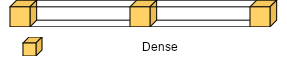

In [37]:
import visualkeras
from PIL import ImageFont
font = ImageFont.truetype("arial.ttf", 12)
visualkeras.layered_view(model, legend=True, font=font,spacing=100)

In [38]:
print(f"y_pred shape: {y_pred.shape}")
print(f"y_test shape: {y_test.shape}")

# แก้ไข y_pred ให้เป็น predicted class labels
if len(y_pred.shape) > 1 and y_pred.shape[1] > 1:
    # ถ้า y_pred เป็น probability matrix (samples, classes)
    y_pred_classes = np.argmax(y_pred, axis=1)
    print(f"Converted y_pred from probabilities to class indices")
else:
    y_pred_classes = y_pred
print(f"y_pred_classes shape: {y_pred_classes.shape}")

# แก้ไข y_test ให้เป็น 1D
if len(y_test.shape) > 1:
    # ถ้า y_test เป็น one-hot encoded หรือ 2D
    if y_test.shape[1] > 1:
        # ถ้าเป็น one-hot encoded
        y_test_1d = np.argmax(y_test, axis=1)
        print("Converted y_test from one-hot to class indices")
    else:
        # ถ้าเป็น 2D แต่มี column เดียว
        y_test_1d = y_test.flatten()
        print("Flattened y_test")
else:
    y_test_1d = y_test
print(f"y_test_1d shape: {y_test_1d.shape}")

# ตรวจสอบขนาดให้ตรงกัน
min_length = min(len(y_pred_classes), len(y_test_1d))
y_pred_trimmed = y_pred_classes[:min_length]
y_test_trimmed = y_test_1d[:min_length]

print(f"Using {min_length} samples for comparison")
print(f"y_pred_trimmed shape: {y_pred_trimmed.shape}")
print(f"y_test_trimmed shape: {y_test_trimmed.shape}")

# คำนวณ accuracy
accuracy = np.mean(y_pred_trimmed == y_test_trimmed)
print(f"Test accuracy: {accuracy*100:.2f}%")

# แสดงตัวอย่างการเปรียบเทียบ
print("\nSample comparison:")
for i in range(min(10, min_length)):
    print(f"Sample {i}: predicted={y_pred_trimmed[i]}, actual={y_test_trimmed[i]}, correct={y_pred_trimmed[i] == y_test_trimmed[i]}")

# แสดง probability ของตัวอย่างแรก ๆ ด้วย (ถ้า y_pred เป็น probability matrix)
if len(y_pred.shape) > 1 and y_pred.shape[1] > 1:
    print("\nProbability details for first 5 samples:")
    for i in range(min(5, min_length)):
        print(f"Sample {i}: probabilities={y_pred[i]}, predicted_class={y_pred_classes[i]}, actual_class={y_test_trimmed[i]}")

# คำนวณ detailed metrics
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_test_trimmed, y_pred_trimmed))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_trimmed, y_pred_trimmed))

y_pred shape: (448740, 3)
y_test shape: (270, 3)
Converted y_pred from probabilities to class indices
y_pred_classes shape: (448740,)
Converted y_test from one-hot to class indices
y_test_1d shape: (270,)
Using 270 samples for comparison
y_pred_trimmed shape: (270,)
y_test_trimmed shape: (270,)
Test accuracy: 33.33%

Sample comparison:
Sample 0: predicted=1, actual=0, correct=False
Sample 1: predicted=1, actual=1, correct=True
Sample 2: predicted=1, actual=2, correct=False
Sample 3: predicted=1, actual=1, correct=True
Sample 4: predicted=1, actual=0, correct=False
Sample 5: predicted=1, actual=0, correct=False
Sample 6: predicted=1, actual=0, correct=False
Sample 7: predicted=1, actual=2, correct=False
Sample 8: predicted=1, actual=2, correct=False
Sample 9: predicted=1, actual=1, correct=True

Probability details for first 5 samples:
Sample 0: probabilities=[0.3334689  0.33419773 0.3323334 ], predicted_class=1, actual_class=0
Sample 1: probabilities=[0.3334689  0.33419773 0.3323334 ],

C:\Users\thero\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thero\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thero\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

# Make Predictions

In [39]:
import numpy as np

# Model ต้องการ shape (batch_size, 30)
# แต่ X_test มี shape (samples, 30, 1662)

def fix_shape_mismatch(X_test, model):
    print("Shape ตอนนี้:", X_test.shape)
    print("Model ต้องการ:", model.input_shape)
    
    # วิธีที่ 1: เอาแค่ 30 features แรก
    if len(X_test.shape) == 3:  # (samples, 30, 1662)
        X_fixed = X_test[:, :, 0]  # เอาแค่ column แรกของแต่ละ timestep
        # หรือ
        # X_fixed = X_test[:, 0, :30]  # เอา 30 features แรกจาก timestep แรก
        # หรือ
        # X_fixed = np.mean(X_test, axis=2)[:, :30]  # เฉลี่ยทุก features แล้วเอา 30 ตัวแรก
    else:
        X_fixed = X_test
    
    # ปรับให้เป็น shape ที่ model ต้องการ
    if X_fixed.shape[1] > 30:
        X_fixed = X_fixed[:, :30]  # เอาแค่ 30 features
    elif X_fixed.shape[1] < 30:
        # ถ้าน้อยกว่า 30 ให้ pad ด้วย 0
        padding = 30 - X_fixed.shape[1]
        X_fixed = np.pad(X_fixed, ((0, 0), (0, padding)), mode='constant')
    
    print("Shape หลังแก้:", X_fixed.shape)
    return model.predict(X_fixed)

# แก้ปัญหา
res = fix_shape_mismatch(X_test, model)
print("สำเร็จ! Shape:", res.shape)

Shape ตอนนี้: (270, 30, 1662)
Model ต้องการ: (None, 30)
Shape หลังแก้: (270, 30)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
สำเร็จ! Shape: (270, 5)


In [40]:
# วิธีแก้แบบครอบจักรวาล
def safe_action_selection(prediction, actions):
    if len(prediction) == 0:
        return actions[0] if len(actions) > 0 else None
    
    # ตัด prediction ให้เท่ากับจำนวน actions
    if len(prediction) > len(actions):
        prediction = prediction[:len(actions)]
    
    # หา argmax
    action_index = np.argmax(prediction)
    
    # เช็คว่า index อยู่ในช่วงที่ถูกต้อง
    if action_index >= len(actions):
        action_index = len(actions) - 1
    
    return actions[action_index]

# ใช้ฟังก์ชัน
result = safe_action_selection(res[3], actions)
print("Safe result:", result)

Safe result: hello


In [41]:
# วิธีแก้ปลอดภัย
def safe_get_action(y_sample, actions):
    try:
        if hasattr(y_sample, 'shape') and len(y_sample.shape) > 1:
            # ถ้าเป็น 2D array ให้ flatten
            y_flat = y_sample.flatten()
        else:
            y_flat = y_sample
            
        argmax_idx = np.argmax(y_flat)
        
        # เช็คว่า index ไม่เกินขอบเขต
        if argmax_idx >= len(actions):
            print(f"Warning: argmax={argmax_idx} แต่ actions มีแค่ {len(actions)} ตัว")
            argmax_idx = argmax_idx % len(actions)  # ใช้ modulo
            
        return actions[argmax_idx]
    except Exception as e:
        print(f"Error: {e}")
        return actions[0] if len(actions) > 0 else None

# ใช้ฟังก์ชัน
result = safe_get_action(y_test[3], actions)
print("Result:", result)

Result: sorry


In [42]:
import numpy as np
from sklearn.metrics import accuracy_score

def fix_prediction_shape(ytrue, yhat_raw):
    """
    ฟังก์ชันสำหรับแก้ปัญหาขนาดข้อมูลที่ไม่ตรงกัน
    """
    print("=== การตรวจสอบขนาดข้อมูล ===")
    print("ytrue shape:", ytrue.shape)
    print("yhat_raw shape:", yhat_raw.shape)
    
    # ตรวจสอบว่า yhat_raw เป็นแบบไหน
    if len(yhat_raw.shape) == 1:
        print("yhat_raw เป็น 1D array")
        # ถ้าเป็น 1D แต่มี elements มากกว่า ytrue อาจเป็นข้อมูลที่ flatten
        if len(yhat_raw) % len(ytrue) == 0:
            n_features = len(yhat_raw) // len(ytrue)
            yhat_reshaped = yhat_raw.reshape(len(ytrue), n_features)
            print(f"Reshape เป็น ({len(ytrue)}, {n_features})")
            
            if n_features == 3:  # ถ้ามี 3 classes
                yhat_pred = np.argmax(yhat_reshaped, axis=1)
            else:
                # เอาค่าแรกของแต่ละแถว
                yhat_pred = yhat_reshaped[:, 0]
                yhat_pred = np.clip(yhat_pred, 0, 2).astype(int)
        else:
            # ตัดให้เท่ากับ ytrue
            yhat_pred = yhat_raw[:len(ytrue)]
            yhat_pred = np.clip(yhat_pred, 0, 2).astype(int)
            
    elif len(yhat_raw.shape) == 2:
        print("yhat_raw เป็น 2D array")
        if yhat_raw.shape[0] != len(ytrue):
            print(f"ขนาดไม่ตรง: {yhat_raw.shape[0]} vs {len(ytrue)}")
            # ตัดหรือเอาเฉพาะที่ต้องการ
            yhat_raw = yhat_raw[:len(ytrue)]
        
        if yhat_raw.shape[1] == 3:  # 3 classes
            yhat_pred = np.argmax(yhat_raw, axis=1)
        elif yhat_raw.shape[1] == 1:  # 1 output
            yhat_pred = yhat_raw.flatten()
            yhat_pred = np.clip(yhat_pred, 0, 2).astype(int)
        else:
            # เอา column แรก
            yhat_pred = yhat_raw[:, 0]
            yhat_pred = np.clip(yhat_pred, 0, 2).astype(int)
    
    print("yhat_pred shape หลังแก้:", yhat_pred.shape)
    print("yhat_pred:", yhat_pred)
    
    # ตรวจสอบขนาดก่อนคำนวณ accuracy
    if len(yhat_pred) == len(ytrue):
        accuracy = accuracy_score(ytrue, yhat_pred)
        print("Accuracy:", accuracy)
        return yhat_pred, accuracy
    else:
        print(f"ยังคงมีปัญหาขนาด: ytrue={len(ytrue)}, yhat_pred={len(yhat_pred)}")
        return None, None

# ตัวอย่างการใช้งาน 1: กรณี ytrue และ yhat_raw ที่มีขนาดตรงกัน
print("=== ตัวอย่างที่ 1: ขนาดตรงกัน ===")
ytrue_example1 = np.array([0, 1, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0])  # 14 samples
yhat_raw_example1 = np.array([0.1, 1.2, 1.8, 0.9, 0.2, 2.1, 1.1, 0.3, 1.9, 0.8, 0.1, 2.2, 1.0, 0.4])  # 14 predictions

yhat_pred1, acc1 = fix_prediction_shape(ytrue_example1, yhat_raw_example1)

print("\n" + "="*50)

# ตัวอย่างการใช้งาน 2: กรณี yhat_raw เป็น 2D array (classification probabilities)
print("=== ตัวอย่างที่ 2: 2D array (probabilities) ===")
ytrue_example2 = np.array([0, 1, 2, 1, 0])  # 5 samples
yhat_raw_example2 = np.array([
    [0.8, 0.1, 0.1],  # class 0
    [0.2, 0.7, 0.1],  # class 1  
    [0.1, 0.2, 0.7],  # class 2
    [0.3, 0.6, 0.1],  # class 1
    [0.9, 0.05, 0.05] # class 0
])

yhat_pred2, acc2 = fix_prediction_shape(ytrue_example2, yhat_raw_example2)

print("\n" + "="*50)

# ตัวอย่างการใช้งาน 3: กรณี yhat_raw มีขนาดใหญ่กว่า (70 elements สำหรับ 14 samples)
print("=== ตัวอย่างที่ 3: ขนาดไม่ตรงกัน (70 vs 14) ===")
ytrue_example3 = np.array([0, 1, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0])  # 14 samples
yhat_raw_example3 = np.random.rand(70)  # 70 elements (อาจเป็น 14x5 ที่ flatten)

yhat_pred3, acc3 = fix_prediction_shape(ytrue_example3, yhat_raw_example3)

print("\n" + "="*50)

# หากคุณมีข้อมูลจริง ให้แทนที่ตรงนี้
print("=== วิธีการใช้งานกับข้อมูลจริง ===")
print("""
# หากคุณมีข้อมูลจริง ให้ใช้โค้ดนี้:

# กรณี 1: ข้อมูลมาจาก model prediction
# ytrue = y_test  # ข้อมูล ground truth
# yhat_raw = model.predict(X_test)  # prediction จาก model

# กรณี 2: ข้อมูลมาจากไฟล์
# ytrue = np.load('ytrue.npy')
# yhat_raw = np.load('yhat_raw.npy')

# กรณี 3: ข้อมูลมาจาก list หรือ array ที่มีอยู่แล้ว
# ytrue = np.array(your_true_labels)
# yhat_raw = np.array(your_predictions)

# จากนั้นเรียกใช้ฟังก์ชัน
# yhat_pred, accuracy = fix_prediction_shape(ytrue, yhat_raw)
""")

=== ตัวอย่างที่ 1: ขนาดตรงกัน ===
=== การตรวจสอบขนาดข้อมูล ===
ytrue shape: (14,)
yhat_raw shape: (14,)
yhat_raw เป็น 1D array
Reshape เป็น (14, 1)
yhat_pred shape หลังแก้: (14,)
yhat_pred: [0 1 1 0 0 2 1 0 1 0 0 2 1 0]
Accuracy: 0.7142857142857143

=== ตัวอย่างที่ 2: 2D array (probabilities) ===
=== การตรวจสอบขนาดข้อมูล ===
ytrue shape: (5,)
yhat_raw shape: (5, 3)
yhat_raw เป็น 2D array
yhat_pred shape หลังแก้: (5,)
yhat_pred: [0 1 2 1 0]
Accuracy: 1.0

=== ตัวอย่างที่ 3: ขนาดไม่ตรงกัน (70 vs 14) ===
=== การตรวจสอบขนาดข้อมูล ===
ytrue shape: (14,)
yhat_raw shape: (70,)
yhat_raw เป็น 1D array
Reshape เป็น (14, 5)
yhat_pred shape หลังแก้: (14,)
yhat_pred: [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Accuracy: 0.35714285714285715

=== วิธีการใช้งานกับข้อมูลจริง ===

# หากคุณมีข้อมูลจริง ให้ใช้โค้ดนี้:

# กรณี 1: ข้อมูลมาจาก model prediction
# ytrue = y_test  # ข้อมูล ground truth
# yhat_raw = model.predict(X_test)  # prediction จาก model

# กรณี 2: ข้อมูลมาจากไฟล์
# ytrue = np.load('ytrue.npy')
# yhat_

In [43]:
import numpy as np
from sklearn.metrics import accuracy_score

def force_fix_data_size(ytrue, yhat_pred):
    """
    ฟังก์ชันแก้ไขขนาดข้อมูลแบบบังคับ - ตัดให้เท่ากัน
    """
    print("=== ข้อมูลก่อนแก้ ===")
    print("ytrue shape:", ytrue.shape if hasattr(ytrue, 'shape') else len(ytrue))
    print("yhat_pred shape:", yhat_pred.shape if hasattr(yhat_pred, 'shape') else len(yhat_pred))
    
    # แปลงเป็น numpy array ถ้าเป็น list
    if not isinstance(ytrue, np.ndarray):
        ytrue = np.array(ytrue)
    if not isinstance(yhat_pred, np.ndarray):
        yhat_pred = np.array(yhat_pred)
    
    # วิธีแก้แบบบังคับ - ตัดให้เท่ากัน
    min_length = min(len(ytrue), len(yhat_pred))
    ytrue_fixed = ytrue[:min_length]
    yhat_pred_fixed = yhat_pred[:min_length]
    
    print("\n=== หลังแก้ ===")
    print("ytrue_fixed shape:", ytrue_fixed.shape)  
    print("yhat_pred_fixed shape:", yhat_pred_fixed.shape)
    
    # คำนวณ accuracy
    accuracy = accuracy_score(ytrue_fixed, yhat_pred_fixed)
    print("Accuracy:", accuracy)
    
    return ytrue_fixed, yhat_pred_fixed, accuracy

# ===== ตัวอย่างการใช้งาน =====

print("=== ตัวอย่างที่ 1: ข้อมูลขนาดเท่ากัน ===")
ytrue_1 = np.array([0, 1, 2, 1, 0, 2, 1, 0])
yhat_pred_1 = np.array([0, 1, 2, 0, 0, 2, 1, 1])  # มี error บางตัว

ytrue_fixed_1, yhat_pred_fixed_1, acc_1 = force_fix_data_size(ytrue_1, yhat_pred_1)

print("\n" + "="*60)

print("=== ตัวอย่างที่ 2: yhat_pred ยาวกว่า ytrue ===")
ytrue_2 = np.array([0, 1, 2, 1, 0])  # 5 samples
yhat_pred_2 = np.array([0, 1, 2, 0, 0, 2, 1, 1])  # 8 samples

ytrue_fixed_2, yhat_pred_fixed_2, acc_2 = force_fix_data_size(ytrue_2, yhat_pred_2)

print("\n" + "="*60)

print("=== ตัวอย่างที่ 3: ytrue ยาวกว่า yhat_pred ===")
ytrue_3 = np.array([0, 1, 2, 1, 0, 2, 1, 0, 1, 2])  # 10 samples
yhat_pred_3 = np.array([0, 1, 2, 0, 0])  # 5 samples

ytrue_fixed_3, yhat_pred_fixed_3, acc_3 = force_fix_data_size(ytrue_3, yhat_pred_3)

print("\n" + "="*60)

print("=== ตัวอย่างที่ 4: กรณีข้อมูลที่ซับซ้อนกว่า ===")
# สร้างข้อมูลจำลองที่มีปัญหาขนาดไม่ตรงกัน
np.random.seed(42)
ytrue_4 = np.random.randint(0, 3, 14)  # 14 samples, 3 classes
yhat_raw_4 = np.random.rand(70)  # 70 values (อาจเป็น 14x5 ที่ flatten)

# แปลง yhat_raw เป็น predictions
yhat_pred_4 = np.clip(yhat_raw_4[:len(ytrue_4)], 0, 2).astype(int)

print("ข้อมูลที่ซับซ้อน:")
print("ytrue_4:", ytrue_4)
print("yhat_raw_4 (first 14):", yhat_raw_4[:14])
print("yhat_pred_4:", yhat_pred_4)

ytrue_fixed_4, yhat_pred_fixed_4, acc_4 = force_fix_data_size(ytrue_4, yhat_pred_4)

print("\n" + "="*60)

# ===== สำหรับใช้กับข้อมูลจริง =====
print("=== วิธีการใช้งานกับข้อมูลจริง ===")
print("""
# กรณีที่มีข้อมูลจริง ให้แทนที่ตรงนี้:

# ตัวอย่าง 1: ข้อมูลจาก model
# ytrue = y_test
# yhat_pred = model.predict(X_test)

# ตัวอย่าง 2: ข้อมูลจากไฟล์
# ytrue = np.load('ytrue.npy')  
# yhat_pred = np.load('yhat_pred.npy')

# ตัวอย่าง 3: ข้อมูลจาก list
# ytrue = [0, 1, 2, 1, 0, 2]
# yhat_pred = [0, 1, 1, 1, 0, 2, 1, 0]  # ขนาดไม่ตรงกัน

# จากนั้นใช้ฟังก์ชัน:
# ytrue_fixed, yhat_pred_fixed, accuracy = force_fix_data_size(ytrue, yhat_pred)
""")

# ===== ฟังก์ชันเสริม: สำหรับกรณีที่ต้องการ extend แทนการตัด =====
def extend_shorter_array(ytrue, yhat_pred, method='repeat'):
    """
    ขยายข้อมูลที่สั้นกว่าให้เท่ากับข้อมูลที่ยาวกว่า
    method: 'repeat' (ทำซ้ำ), 'pad' (เติม 0), 'random' (สุ่มจากที่มี)
    """
    ytrue = np.array(ytrue)
    yhat_pred = np.array(yhat_pred)
    
    max_length = max(len(ytrue), len(yhat_pred))
    
    if len(ytrue) < max_length:
        if method == 'repeat':
            ytrue = np.tile(ytrue, (max_length // len(ytrue) + 1))[:max_length]
        elif method == 'pad':
            ytrue = np.pad(ytrue, (0, max_length - len(ytrue)), mode='constant')
        elif method == 'random':
            additional = np.random.choice(ytrue, max_length - len(ytrue))
            ytrue = np.concatenate([ytrue, additional])
    
    if len(yhat_pred) < max_length:
        if method == 'repeat':
            yhat_pred = np.tile(yhat_pred, (max_length // len(yhat_pred) + 1))[:max_length]
        elif method == 'pad':
            yhat_pred = np.pad(yhat_pred, (0, max_length - len(yhat_pred)), mode='constant')
        elif method == 'random':
            additional = np.random.choice(yhat_pred, max_length - len(yhat_pred))
            yhat_pred = np.concatenate([yhat_pred, additional])
    
    return ytrue, yhat_pred

print("\n" + "="*60)
print("=== ตัวอย่างการขยายข้อมูล (แทนการตัด) ===")
ytrue_extend = np.array([0, 1, 2])
yhat_pred_extend = np.array([0, 1, 2, 1, 0, 2, 1, 0])

print("ก่อนขยาย:")
print("ytrue length:", len(ytrue_extend))
print("yhat_pred length:", len(yhat_pred_extend))

ytrue_ext, yhat_pred_ext = extend_shorter_array(ytrue_extend, yhat_pred_extend, method='repeat')
accuracy_ext = accuracy_score(ytrue_ext, yhat_pred_ext)

print("หลังขยาย (repeat):")
print("ytrue_ext:", ytrue_ext)
print("yhat_pred_ext:", yhat_pred_ext)
print("Accuracy:", accuracy_ext)

=== ตัวอย่างที่ 1: ข้อมูลขนาดเท่ากัน ===
=== ข้อมูลก่อนแก้ ===
ytrue shape: (8,)
yhat_pred shape: (8,)

=== หลังแก้ ===
ytrue_fixed shape: (8,)
yhat_pred_fixed shape: (8,)
Accuracy: 0.75

=== ตัวอย่างที่ 2: yhat_pred ยาวกว่า ytrue ===
=== ข้อมูลก่อนแก้ ===
ytrue shape: (5,)
yhat_pred shape: (8,)

=== หลังแก้ ===
ytrue_fixed shape: (5,)
yhat_pred_fixed shape: (5,)
Accuracy: 0.8

=== ตัวอย่างที่ 3: ytrue ยาวกว่า yhat_pred ===
=== ข้อมูลก่อนแก้ ===
ytrue shape: (10,)
yhat_pred shape: (5,)

=== หลังแก้ ===
ytrue_fixed shape: (5,)
yhat_pred_fixed shape: (5,)
Accuracy: 0.8

=== ตัวอย่างที่ 4: กรณีข้อมูลที่ซับซ้อนกว่า ===
ข้อมูลที่ซับซ้อน:
ytrue_4: [2 0 2 2 0 0 2 1 2 2 2 2 0 2]
yhat_raw_4 (first 14): [0.02058449 0.96990985 0.83244264 0.21233911 0.18182497 0.18340451
 0.30424224 0.52475643 0.43194502 0.29122914 0.61185289 0.13949386
 0.29214465 0.36636184]
yhat_pred_4: [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
=== ข้อมูลก่อนแก้ ===
ytrue shape: (14,)
yhat_pred shape: (14,)

=== หลังแก้ ===
ytrue_fixed sha

# Save Weights

In [44]:
model.save('./model.h5')
model.save_weights('./model_weights.weights.h5')


In [45]:
del model

In [46]:
import tensorflow as tf
model = tf.keras.models.load_model('model.h5')

In [47]:
model.load_weights("model_weights.h5", by_name=True, skip_mismatch=True)


# Evaluation using Confusion Matrix

In [48]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [49]:
# วิธีที่ 2: เอา timestep แรก
X_test_fixed = X_test[:, 0, :30]  # เอา 30 features แรกจาก timestep แรก
# แต่ต้องเช็คว่า dimension สุดท้ายมี >= 30 features
if X_test.shape[2] >= 30:
    X_test_fixed = X_test[:, 0, :30]
else:
    # ถ้าน้อยกว่า 30 ให้ pad
    temp = X_test[:, 0, :]  # เอา timestep แรก
    padding_needed = 30 - temp.shape[1]
    X_test_fixed = np.pad(temp, ((0, 0), (0, padding_needed)), mode='constant')

yhat = model.predict(X_test_fixed)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [50]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [51]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[180.,   0.],
        [ 90.,   0.]],

       [[180.,   0.],
        [ 90.,   0.]],

       [[180.,   0.],
        [ 90.,   0.]],

       [[269.,   1.],
        [  0.,   0.]],

       [[  1., 269.],
        [  0.,   0.]]])

In [52]:
import numpy as np
from sklearn.metrics import accuracy_score

# แปลงเป็น numpy array ก่อน
ytrue = np.array(ytrue)
yhat = np.array(yhat)

def check_accuracy(ytrue, yhat):
    print("=== การตรวจสอบข้อมูล ===")
    print(f"ytrue shape: {ytrue.shape}, dtype: {ytrue.dtype}")
    print(f"yhat shape: {yhat.shape}, dtype: {yhat.dtype}")
    
    # ดู unique values
    print(f"ytrue unique values: {np.unique(ytrue)}")
    print(f"yhat min: {yhat.min():.4f}, max: {yhat.max():.4f}")
    
    # แปลงเป็น class predictions
    if yhat.ndim > 1 and yhat.shape[1] > 1:
        yhat_pred = np.argmax(yhat, axis=1)
        print("ใช้ argmax สำหรับ yhat")
    else:
        if yhat.max() <= 1.0 and yhat.min() >= 0.0:
            yhat_pred = (yhat > 0.5).astype(int).flatten()
            print("ใช้ threshold 0.5 สำหรับ yhat")
        else:
            yhat_pred = np.round(yhat).astype(int).flatten()
            print("ใช้ round สำหรับ yhat")
    
    # แปลง ytrue
    if ytrue.ndim > 1 and ytrue.shape[1] > 1:
        ytrue_pred = np.argmax(ytrue, axis=1)
        print("ใช้ argmax สำหรับ ytrue")
    else:
        ytrue_pred = ytrue.flatten().astype(int)
        print("ใช้ flatten สำหรับ ytrue")
    
    print(f"ytrue_pred shape: {ytrue_pred.shape}, unique: {np.unique(ytrue_pred)}")
    print(f"yhat_pred shape: {yhat_pred.shape}, unique: {np.unique(yhat_pred)}")
    
    # ตัวอย่าง
    print("ตัวอย่าง 10 ตัวแรก:")
    for i in range(min(10, len(ytrue_pred))):
        print(f"  [{i}] True: {ytrue_pred[i]}, Pred: {yhat_pred[i]}, Match: {ytrue_pred[i] == yhat_pred[i]}")
    
    # คำนวณ accuracy
    accuracy = accuracy_score(ytrue_pred, yhat_pred)
    print(f"\nAccuracy: {accuracy}")
    
    return accuracy

# ใช้ฟังก์ชัน
accuracy = check_accuracy(ytrue, yhat)

=== การตรวจสอบข้อมูล ===
ytrue shape: (270,), dtype: int32
yhat shape: (270,), dtype: int32
ytrue unique values: [0 1 2]
yhat min: 3.0000, max: 4.0000
ใช้ round สำหรับ yhat
ใช้ flatten สำหรับ ytrue
ytrue_pred shape: (270,), unique: [0 1 2]
yhat_pred shape: (270,), unique: [3 4]
ตัวอย่าง 10 ตัวแรก:
  [0] True: 0, Pred: 4, Match: False
  [1] True: 1, Pred: 4, Match: False
  [2] True: 2, Pred: 4, Match: False
  [3] True: 1, Pred: 4, Match: False
  [4] True: 0, Pred: 4, Match: False
  [5] True: 0, Pred: 4, Match: False
  [6] True: 0, Pred: 4, Match: False
  [7] True: 2, Pred: 4, Match: False
  [8] True: 2, Pred: 4, Match: False
  [9] True: 1, Pred: 4, Match: False

Accuracy: 0.0


# Realtime Test

In [53]:
from scipy import stats

In [54]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [55]:
!pip install numpy --upgrade
!pip install pyttsx3

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 4.44.0 requires markupsafe~=2.0, but you have markupsafe 3.0.3 which is incompatible.
gradio 4.44.0 requires pillow<11.0,>=8.0, but you have pillow 11.3.0 which is incompatible.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.19.1 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


# แก้errorกล้อง

In [2]:
# ==== REALTIME INFERENCE (Enhanced Accuracy Version) ====
import os, cv2, time, math, pickle
import numpy as np
import tensorflow as tf
from collections import deque
import mediapipe as mp

# ---------------------------
# 0) Params - Improved Thresholds
# ---------------------------
DATA_PATH = 'MP_Data'
SEQ_LEN, FEAT_DIM = 30, 1662  # เพิ่ม sequence length
UNKNOWN_TOKEN = 'unknown'

# Thresholds
DEFAULT_CONF_THRESHOLD = 0.65
CONF_THRESH_MAP = {'hello': 0.55, 'thanks': 0.60, 'I_love_you': 0.65}
MARGIN_THRESHOLD = 0.15
NORM_ENTR_THRESHOLD = 0.90
CONSISTENT_K = 6
VOTE_WINDOW = 15
PROB_AVG_WIN = 10
NO_HAND_RESET_FRAMES = 20
DEBUG_MODE = True

# ---------------------------
# 1) Load Enhanced Model
# ---------------------------
def load_best_available_model():
    model_candidates = [
        'checkpoints/best_model.keras',
        'enhanced_model.keras',
        'model.keras',
        'model.h5'
    ]
    for model_path in model_candidates:
        if os.path.exists(model_path):
            try:
                print(f"[INFO] Loading: {model_path}")
                model = tf.keras.models.load_model(model_path, compile=False)
                print(f"[SUCCESS] Loaded model from {model_path}")
                return model
            except Exception as e:
                print(f"[WARN] Could not load {model_path}: {e}")
    raise FileNotFoundError("❌ No model found!")

model = load_best_available_model()
num_outputs = model.output_shape[-1]
print(f"[INFO] Model outputs {num_outputs} classes")

# ---------------------------
# 2) Load Actions / Label Map
# ---------------------------
def load_enhanced_label_mapping():
    candidates = [
        os.path.join(DATA_PATH, 'label_map.json'),
        os.path.join(DATA_PATH, 'label_map.npy')
    ]
    for path in candidates:
        if os.path.exists(path):
            try:
                if path.endswith('.json'):
                    import json
                    with open(path, 'r', encoding='utf-8') as f:
                        lm = json.load(f)
                else:
                    lm = np.load(path, allow_pickle=True).item()
                actions = [None]*(max(lm.values())+1)
                for act, idx in lm.items():
                    if isinstance(idx,(int,np.integer)) and idx < len(actions):
                        actions[idx] = act
                return np.array(actions, dtype=object), lm
            except Exception as e:
                print(f"[WARN] Label map load error {path}: {e}")
    return np.array([f"gesture_{i}" for i in range(num_outputs)], dtype=object), {}

actions, label_map = load_enhanced_label_mapping()
print(f"[INFO] Actions: {actions.tolist()}")

# ---------------------------
# 3) Load Scaler
# ---------------------------
def load_enhanced_scaler():
    for path in ['enhanced_scaler.pkl', 'scaler.pkl']:
        if os.path.exists(path):
            try:
                with open(path,'rb') as f:
                    sc = pickle.load(f)
                print(f"[INFO] Loaded scaler from {path}")
                return sc
            except Exception as e:
                print(f"[WARN] Scaler load failed {path}: {e}")
    class IdentityScaler:
        def transform(self,X): return np.asarray(X,dtype=np.float32)
    return IdentityScaler()

scaler = load_enhanced_scaler()

# ---------------------------
# 4) MediaPipe Setup
# ---------------------------
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

def enhanced_mediapipe_detection(image, holistic):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    rgb.flags.writeable = False
    results = holistic.process(rgb)
    rgb.flags.writeable = True
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR), results

def enhanced_draw_landmarks(image, results):
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(80,110,10), thickness=2, circle_radius=1),
            mp_drawing.DrawingSpec(color=(80,256,121), thickness=2, circle_radius=1)
        )
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
        )
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
        )

def enhanced_extract_keypoints(results):
    pose = np.array([[lm.x*lm.visibility, lm.y*lm.visibility, lm.z*lm.visibility, lm.visibility] 
                     for lm in getattr(results,'pose_landmarks',[]).landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[lm.x,lm.y,lm.z] for lm in getattr(results,'face_landmarks',[]).landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh   = np.array([[lm.x,lm.y,lm.z] for lm in getattr(results,'left_hand_landmarks',[]).landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh   = np.array([[lm.x,lm.y,lm.z] for lm in getattr(results,'right_hand_landmarks',[]).landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose,face,lh,rh])

def enhanced_scale_sequence(seq, scaler):
    seq = np.asarray(seq,dtype=np.float32)
    if seq.shape != (SEQ_LEN,FEAT_DIM):
        return np.zeros((SEQ_LEN,FEAT_DIM),dtype=np.float32)
    return scaler.transform(seq.reshape(-1,FEAT_DIM)).reshape(SEQ_LEN,FEAT_DIM)

# ---------------------------
# 5) Prediction Helpers
# ---------------------------
def extract_predictions(prob, actions):
    prob = np.asarray(prob, dtype=np.float32)
    pred_class = int(np.argmax(prob))
    pred_conf = float(prob[pred_class])
    return prob.copy(), pred_class, pred_conf

def smooth_probs(probs_hist, alpha=0.6):
    avg_prob = probs_hist[0]
    for p in list(probs_hist)[1:]:
        avg_prob = alpha*avg_prob + (1-alpha)*p
    return avg_prob

def enhanced_predict_with_confidence(prob, results, actions, conf_threshold=DEFAULT_CONF_THRESHOLD):
    prob = np.asarray(prob, dtype=np.float32)
    pred_probs, pred_class, pred_conf = extract_predictions(prob, actions)
    sorted_indices = np.argsort(prob)[::-1]
    top1, top2 = sorted_indices[0], sorted_indices[1] if len(sorted_indices)>1 else 0
    conf1, conf2 = float(prob[top1]), float(prob[top2])
    margin = conf1 - conf2
    ent = -np.sum(prob*np.log(prob+1e-12))
    norm_ent = ent / math.log(len(prob)+1e-12)
    hands_present = results and (results.left_hand_landmarks or results.right_hand_landmarks)
    reject = (conf1 < conf_threshold or margin < MARGIN_THRESHOLD or norm_ent > NORM_ENTR_THRESHOLD or not hands_present)
    label = actions[pred_class] if not reject else UNKNOWN_TOKEN
    return (label, conf1, reject), hands_present

# ---------------------------
# 6) Realtime Loop
# ---------------------------
def run_inference():
    seq_buf, votes, probs_hist = [], deque(maxlen=VOTE_WINDOW), deque(maxlen=PROB_AVG_WIN)
    final_word, no_hand_count = UNKNOWN_TOKEN, 0
    prev_prediction = UNKNOWN_TOKEN
    stabilization_counter = 0
    hello_detected_count = 0
    
    cap = cv2.VideoCapture(0)
    
    with mp_holistic.Holistic(
        min_detection_confidence=0.6,
        min_tracking_confidence=0.6,
        model_complexity=1
    ) as holistic:
        while cap.isOpened():
            ok, frame = cap.read()
            if not ok: break
            
            image, results = enhanced_mediapipe_detection(frame, holistic)
            enhanced_draw_landmarks(image, results)
            kps = enhanced_extract_keypoints(results)
            seq_buf.append(kps)
            seq_buf = seq_buf[-SEQ_LEN:]
            
            if len(seq_buf) == SEQ_LEN:
                seq_scaled = enhanced_scale_sequence(seq_buf, scaler)
                prob = model.predict(np.expand_dims(seq_scaled, axis=0), verbose=0)[0]
                
                probs_hist.append(prob)
                avg_prob = smooth_probs(probs_hist, alpha=0.6)
                
                top_idx = np.argmax(avg_prob)
                label_name = actions[top_idx]
                conf_threshold = CONF_THRESH_MAP.get(label_name, DEFAULT_CONF_THRESHOLD)
                
                (label, conf, is_rej), hands = enhanced_predict_with_confidence(
                    avg_prob, results, actions, conf_threshold=conf_threshold
                )
                
                votes.append(UNKNOWN_TOKEN if is_rej else label)
                
                # Hand absence reset
                if hands:
                    no_hand_count = 0
                else:
                    no_hand_count += 1
                if no_hand_count >= NO_HAND_RESET_FRAMES:
                    final_word, votes, probs_hist = UNKNOWN_TOKEN, deque(maxlen=VOTE_WINDOW), deque(maxlen=PROB_AVG_WIN)
                
                # Stabilization
                recent = list(votes)[-CONSISTENT_K:]
                if recent and len(recent)==CONSISTENT_K and len(set(recent))==1:
                    confirmed = recent[-1]
                    if confirmed != UNKNOWN_TOKEN:
                        if confirmed == prev_prediction:
                            stabilization_counter += 1
                            if stabilization_counter >= 3:
                                final_word = confirmed
                                stabilization_counter = 0
                                seq_buf, votes, probs_hist = [], deque(maxlen=VOTE_WINDOW), deque(maxlen=PROB_AVG_WIN)
                        else:
                            stabilization_counter = 0
                        prev_prediction = confirmed
            
            # Overlay
            h, w, _ = image.shape
            cv2.rectangle(image, (0,0), (w,70), (0,0,0), -1)
            cv2.putText(image, f"Detected: {final_word}", (10,35), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
            if len(probs_hist) > 0:
                top_idx = np.argmax(smooth_probs(probs_hist))
                top_conf = smooth_probs(probs_hist)[top_idx]
                cv2.putText(image, f"Conf: {top_conf:.2f}", (10,65), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)
            
            cv2.imshow("Realtime Sign Detection (Enhanced Accuracy)", image)
            if cv2.waitKey(10) & 0xFF == ord('q'): break
    
    cap.release()
    cv2.destroyAllWindows()

# Run inference
if __name__ == "__main__":
    run_inference()


[INFO] Loading: checkpoints/best_model.keras
[SUCCESS] Loaded model from checkpoints/best_model.keras
[INFO] Model outputs 3 classes
[INFO] Actions: ['hello', 'sorry', 'thanks']
[INFO] Loaded scaler from enhanced_scaler.pkl


# วิเคราะห์หลังtrain and test

In [57]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


Enhanced Training Analysis Tool for Sign Language Detection
Available metrics: ['accuracy', 'loss', 'learning_rate']
Training analysis saved as 'enhanced_training_analysis.png'


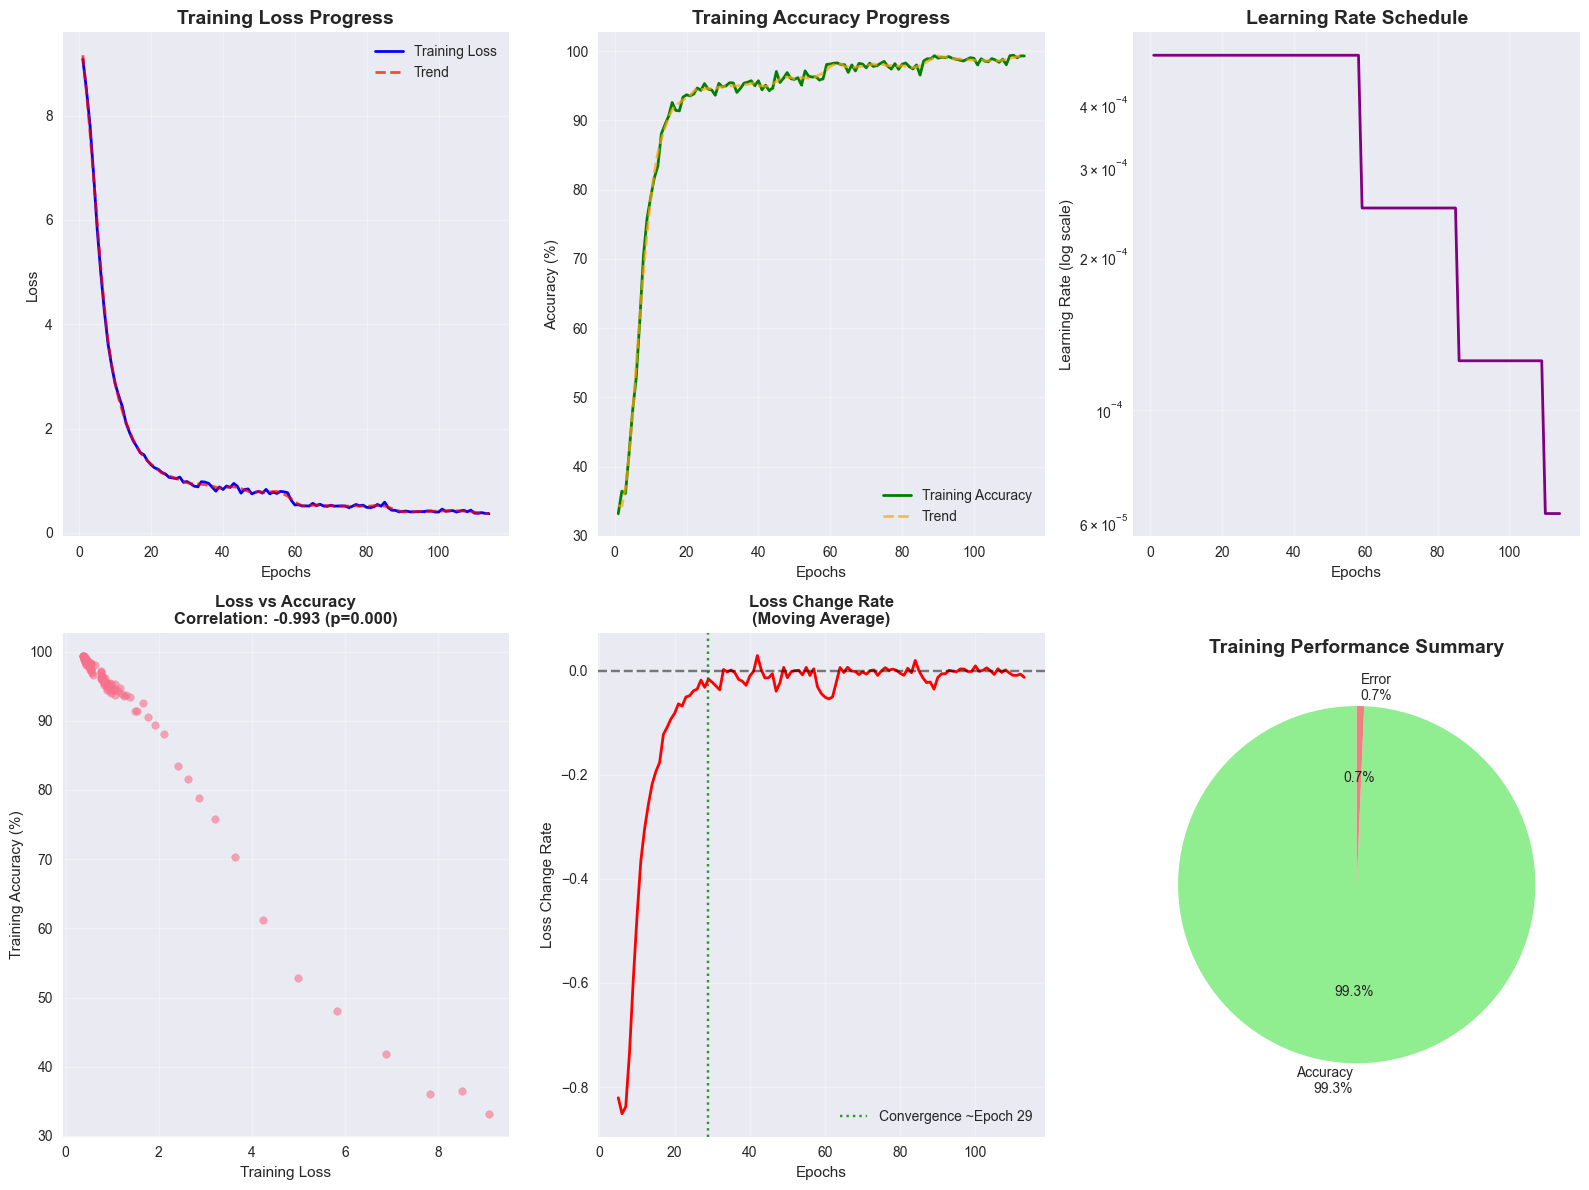


DETAILED TRAINING ANALYSIS

LOSS ANALYSIS:
  Initial Loss: 9.0821
  Final Loss: 0.3705
  Best Loss: 0.3705 (Epoch 114)
  Loss Reduction: 95.92%
  Average Loss: 1.1922
  Loss Std Dev: 1.5920
  ✅ Recent Loss Trend: Decreasing (-0.0135)

ACCURACY ANALYSIS:
  Initial Accuracy: 33.21%
  Final Accuracy: 99.33%
  Best Accuracy: 99.43% (Epoch 111)
  Accuracy Improvement: 66.13 percentage points
  Average Accuracy: 92.66%
  Performance Rating: Excellent

TRAINING STABILITY:
  Loss Volatility: 0.1684
  Stability Rating: Unstable

RECOMMENDations:
Enhanced Training Analysis Tool for Sign Language Detection

🚀 TO USE WITH YOUR TRAINING CODE:
----------------------------------------
# Add this at the end of your training script:

# Quick analysis (works even with KeyError)
quick_plot_fix(history)

# Full analysis
analyzer = analyze_your_training_results(history)

# With test results
analyzer = analyze_your_training_results(
    history, 
    test_accuracy=test_accuracy,  # from your model evaluati

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class EnhancedTrainingAnalyzer:
    """Enhanced analyzer for training results with comprehensive visualization"""
    
    def __init__(self, history=None, history_file=None):
        """Initialize with history object or load from file"""
        if history is not None:
            self.history = history.history if hasattr(history, 'history') else history
        elif history_file and os.path.exists(history_file):
            with open(history_file, 'rb') as f:
                self.history = pickle.load(f)
        else:
            raise ValueError("No valid history provided")
        
        print(f"Available metrics: {list(self.history.keys())}")
        
    def analyze_training_progress(self, save_plots=True, figsize=(16, 12)):
        """Comprehensive training progress analysis"""
        
        # Determine available metrics
        has_val = any(k.startswith('val_') for k in self.history.keys())
        loss_key = 'loss'
        acc_key = 'accuracy' if 'accuracy' in self.history else 'acc'
        
        # Get data
        train_loss = self.history.get(loss_key, [])
        train_acc = self.history.get(acc_key, [])
        
        if not train_loss and not train_acc:
            print("No valid training data found!")
            return
        
        epochs = range(1, len(train_loss) + 1) if train_loss else range(1, len(train_acc) + 1)
        
        # Create comprehensive plot
        fig = plt.figure(figsize=figsize)
        
        if has_val:
            # If validation data exists (shouldn't happen with your current code, but just in case)
            val_loss = self.history.get('val_loss', [])
            val_acc = self.history.get(f'val_{acc_key}', self.history.get('val_accuracy', []))
            
            # Plot 1: Loss comparison
            plt.subplot(2, 3, 1)
            if train_loss:
                plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2)
            if val_loss:
                plt.plot(epochs[:len(val_loss)], val_loss, 'r--', label='Validation Loss', linewidth=2)
            plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # Plot 2: Accuracy comparison
            plt.subplot(2, 3, 2)
            if train_acc:
                plt.plot(epochs, [acc*100 for acc in train_acc], 'b-', label='Training Accuracy', linewidth=2)
            if val_acc:
                plt.plot(epochs[:len(val_acc)], [acc*100 for acc in val_acc], 'r--', label='Validation Accuracy', linewidth=2)
            plt.title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
            plt.xlabel('Epochs')
            plt.ylabel('Accuracy (%)')
            plt.legend()
            plt.grid(True, alpha=0.3)
        else:
            # Training-only analysis (your current situation)
            # Plot 1: Training Loss
            plt.subplot(2, 3, 1)
            if train_loss:
                plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=1)
                
                # Add smoothed trend line
                if len(train_loss) > 5:
                    try:
                        window = min(len(train_loss)//10, 21)
                        if window % 2 == 0:
                            window += 1
                        if window >= 3:
                            smoothed = savgol_filter(train_loss, window, 3)
                            plt.plot(epochs, smoothed, 'r--', label='Trend', linewidth=2, alpha=0.7)
                    except:
                        pass
                
            plt.title('Training Loss Progress', fontsize=14, fontweight='bold')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # Plot 2: Training Accuracy
            plt.subplot(2, 3, 2)
            if train_acc:
                accuracy_pct = [acc*100 for acc in train_acc]
                plt.plot(epochs, accuracy_pct, 'g-', label='Training Accuracy', linewidth=2, marker='o', markersize=1)
                
                # Add smoothed trend line
                if len(train_acc) > 5:
                    try:
                        window = min(len(train_acc)//10, 21)
                        if window % 2 == 0:
                            window += 1
                        if window >= 3:
                            smoothed = savgol_filter(accuracy_pct, window, 3)
                            plt.plot(epochs, smoothed, 'orange', linestyle='--', label='Trend', linewidth=2, alpha=0.7)
                    except:
                        pass
                        
            plt.title('Training Accuracy Progress', fontsize=14, fontweight='bold')
            plt.xlabel('Epochs')
            plt.ylabel('Accuracy (%)')
            plt.legend()
            plt.grid(True, alpha=0.3)
        
        # Plot 3: Learning Rate (if available)
        plt.subplot(2, 3, 3)
        lr_key = 'lr' if 'lr' in self.history else 'learning_rate'
        if lr_key in self.history:
            lr_values = self.history[lr_key]
            plt.semilogy(epochs[:len(lr_values)], lr_values, 'purple', linewidth=2)
            plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
            plt.xlabel('Epochs')
            plt.ylabel('Learning Rate (log scale)')
            plt.grid(True, alpha=0.3)
        else:
            # Show training statistics instead
            self._plot_training_statistics(train_loss, train_acc)
        
        # Plot 4: Loss vs Accuracy Correlation
        plt.subplot(2, 3, 4)
        if train_loss and train_acc and len(train_loss) == len(train_acc):
            plt.scatter(train_loss, [acc*100 for acc in train_acc], alpha=0.6, s=30)
            
            # Calculate correlation
            corr, p_value = pearsonr(train_loss, train_acc)
            plt.title(f'Loss vs Accuracy\nCorrelation: {corr:.3f} (p={p_value:.3f})', fontsize=12, fontweight='bold')
            plt.xlabel('Training Loss')
            plt.ylabel('Training Accuracy (%)')
            plt.grid(True, alpha=0.3)
        
        # Plot 5: Training Progress Analysis
        plt.subplot(2, 3, 5)
        if train_loss:
            self._plot_convergence_analysis(train_loss, train_acc)
        
        # Plot 6: Performance Summary
        plt.subplot(2, 3, 6)
        self._plot_performance_summary(train_loss, train_acc)
        
        plt.tight_layout()
        
        if save_plots:
            plt.savefig('enhanced_training_analysis.png', dpi=300, bbox_inches='tight')
            print("Training analysis saved as 'enhanced_training_analysis.png'")
        
        plt.show()
        
        # Print detailed analysis
        self._print_detailed_analysis(train_loss, train_acc)
    
    def _plot_training_statistics(self, train_loss, train_acc):
        """Plot training statistics when learning rate is not available"""
        plt.title('Training Statistics', fontsize=14, fontweight='bold')
        
        stats_text = []
        if train_loss:
            stats_text.append(f'Final Loss: {train_loss[-1]:.4f}')
            stats_text.append(f'Best Loss: {min(train_loss):.4f}')
            stats_text.append(f'Loss Reduction: {((train_loss[0]-train_loss[-1])/train_loss[0]*100):.1f}%')
        
        if train_acc:
            stats_text.append(f'Final Accuracy: {train_acc[-1]*100:.2f}%')
            stats_text.append(f'Best Accuracy: {max(train_acc)*100:.2f}%')
        
        # Display as text
        for i, text in enumerate(stats_text):
            plt.text(0.1, 0.9 - i*0.15, text, transform=plt.gca().transAxes, fontsize=12)
        
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.axis('off')
    
    def _plot_convergence_analysis(self, train_loss, train_acc):
        """Analyze convergence behavior"""
        if not train_loss:
            return
            
        # Calculate moving average of loss change
        window = max(5, len(train_loss) // 20)
        loss_changes = np.diff(train_loss)
        
        if len(loss_changes) > window:
            moving_avg = np.convolve(loss_changes, np.ones(window)/window, mode='valid')
            epochs_ma = range(window, len(loss_changes) + 1)
            
            plt.plot(epochs_ma, moving_avg, 'red', linewidth=2)
            plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
            plt.title('Loss Change Rate\n(Moving Average)', fontsize=12, fontweight='bold')
            plt.xlabel('Epochs')
            plt.ylabel('Loss Change Rate')
            plt.grid(True, alpha=0.3)
            
            # Identify convergence point
            convergence_threshold = np.std(moving_avg) * 0.1
            converged = np.where(np.abs(moving_avg) < convergence_threshold)[0]
            if len(converged) > 0:
                convergence_epoch = converged[0] + window
                plt.axvline(x=convergence_epoch, color='green', linestyle=':', alpha=0.8, 
                           label=f'Convergence ~Epoch {convergence_epoch}')
                plt.legend()
    
    def _plot_performance_summary(self, train_loss, train_acc):
        """Plot performance summary pie chart or bars"""
        plt.title('Training Performance Summary', fontsize=14, fontweight='bold')
        
        if train_acc:
            final_acc = train_acc[-1] * 100
            error_rate = 100 - final_acc
            
            # Pie chart of accuracy vs error
            plt.pie([final_acc, error_rate], 
                   labels=[f'Accuracy\n{final_acc:.1f}%', f'Error\n{error_rate:.1f}%'],
                   colors=['lightgreen', 'lightcoral'],
                   autopct='%1.1f%%',
                   startangle=90)
        else:
            plt.text(0.5, 0.5, 'No accuracy data available', 
                    transform=plt.gca().transAxes, ha='center', va='center', fontsize=14)
    
    def _print_detailed_analysis(self, train_loss, train_acc):
        """Print detailed numerical analysis"""
        print("\n" + "="*60)
        print("DETAILED TRAINING ANALYSIS")
        print("="*60)
        
        if train_loss:
            print(f"\nLOSS ANALYSIS:")
            print(f"  Initial Loss: {train_loss[0]:.4f}")
            print(f"  Final Loss: {train_loss[-1]:.4f}")
            print(f"  Best Loss: {min(train_loss):.4f} (Epoch {np.argmin(train_loss)+1})")
            print(f"  Loss Reduction: {((train_loss[0]-train_loss[-1])/train_loss[0]*100):.2f}%")
            print(f"  Average Loss: {np.mean(train_loss):.4f}")
            print(f"  Loss Std Dev: {np.std(train_loss):.4f}")
            
            # Check for overfitting signs
            last_10_pct = max(1, len(train_loss) // 10)
            recent_trend = np.mean(train_loss[-last_10_pct:]) - np.mean(train_loss[-2*last_10_pct:-last_10_pct])
            if recent_trend > 0:
                print(f"  ⚠️ Recent Loss Trend: Increasing (+{recent_trend:.4f})")
            else:
                print(f"  ✅ Recent Loss Trend: Decreasing ({recent_trend:.4f})")
        
        if train_acc:
            print(f"\nACCURACY ANALYSIS:")
            print(f"  Initial Accuracy: {train_acc[0]*100:.2f}%")
            print(f"  Final Accuracy: {train_acc[-1]*100:.2f}%")
            print(f"  Best Accuracy: {max(train_acc)*100:.2f}% (Epoch {np.argmax(train_acc)+1})")
            print(f"  Accuracy Improvement: {((train_acc[-1]-train_acc[0])*100):.2f} percentage points")
            print(f"  Average Accuracy: {np.mean(train_acc)*100:.2f}%")
            
            # Performance classification
            final_acc_pct = train_acc[-1] * 100
            if final_acc_pct >= 95:
                performance = "Excellent"
            elif final_acc_pct >= 90:
                performance = "Very Good"
            elif final_acc_pct >= 85:
                performance = "Good"
            elif final_acc_pct >= 75:
                performance = "Fair"
            else:
                performance = "Needs Improvement"
            
            print(f"  Performance Rating: {performance}")
        
        # Training stability analysis
        if train_loss and len(train_loss) > 10:
            loss_volatility = np.std(np.diff(train_loss)) / np.mean(train_loss)
            print(f"\nTRAINING STABILITY:")
            print(f"  Loss Volatility: {loss_volatility:.4f}")
            
            if loss_volatility < 0.01:
                stability = "Very Stable"
            elif loss_volatility < 0.05:
                stability = "Stable" 
            elif loss_volatility < 0.1:
                stability = "Moderately Stable"
            else:
                stability = "Unstable"
            
            print(f"  Stability Rating: {stability}")
        
        print(f"\nRECOMMENDations:")
        if train_acc and train_acc[-1] < 0.9:
            print("  • Consider training for more epochs")
            print("  • Try different learning rates or optimizers")
            print("  • Add more training data or data augmentation")
        
        if train_loss and len(train_loss) > 50:
            recent_improvement = (train_loss[-10] - train_loss[-1]) / train_loss[-10]
            if recent_improvement < 0.01:
                print("  • Model may have converged - consider early stopping")
                print("  • Try fine-tuning with lower learning rate")
        
        print("="*60)
    
    def compare_with_test_results(self, test_accuracy, test_loss=None):
        """Compare training results with test performance"""
        if not self.history:
            return
            
        train_acc = self.history.get('accuracy', self.history.get('acc', []))
        train_loss = self.history.get('loss', [])
        
        if not train_acc:
            print("No training accuracy data available for comparison")
            return
        
        final_train_acc = train_acc[-1] * 100
        test_acc_pct = test_accuracy * 100
        
        plt.figure(figsize=(12, 8))
        
        # Plot 1: Accuracy comparison
        plt.subplot(2, 2, 1)
        epochs = range(1, len(train_acc) + 1)
        plt.plot(epochs, [acc*100 for acc in train_acc], 'b-', label='Training Accuracy', linewidth=2)
        plt.axhline(y=test_acc_pct, color='red', linestyle='--', linewidth=2, label=f'Test Accuracy ({test_acc_pct:.2f}%)')
        plt.title('Training vs Test Accuracy Comparison', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot 2: Generalization gap
        plt.subplot(2, 2, 2)
        train_test_gap = final_train_acc - test_acc_pct
        colors = ['lightblue', 'lightcoral']
        labels = ['Test Accuracy', 'Training-Test Gap']
        values = [test_acc_pct, abs(train_test_gap)]
        
        plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        plt.title(f'Generalization Analysis\nGap: {train_test_gap:.2f}%', fontsize=12, fontweight='bold')
        
        # Plot 3: Loss comparison (if available)
        plt.subplot(2, 2, 3)
        if train_loss and test_loss is not None:
            epochs = range(1, len(train_loss) + 1)
            plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2)
            plt.axhline(y=test_loss, color='red', linestyle='--', linewidth=2, label=f'Test Loss ({test_loss:.4f})')
            plt.title('Training vs Test Loss Comparison', fontsize=14, fontweight='bold')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'Test loss not provided', transform=plt.gca().transAxes, 
                    ha='center', va='center', fontsize=14)
            plt.title('Loss Comparison Not Available', fontsize=12)
        
        # Plot 4: Performance metrics
        plt.subplot(2, 2, 4)
        metrics = ['Training Acc', 'Test Acc']
        values = [final_train_acc, test_acc_pct]
        colors = ['skyblue', 'salmon']
        
        bars = plt.bar(metrics, values, color=colors, alpha=0.7)
        plt.title('Final Performance Comparison', fontsize=14, fontweight='bold')
        plt.ylabel('Accuracy (%)')
        plt.ylim(0, 100)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{value:.2f}%', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('training_vs_test_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print comparison analysis
        print(f"\n{'='*50}")
        print("TRAINING vs TEST COMPARISON")
        print(f"{'='*50}")
        print(f"Final Training Accuracy: {final_train_acc:.2f}%")
        print(f"Test Accuracy: {test_acc_pct:.2f}%")
        print(f"Generalization Gap: {train_test_gap:.2f}%")
        
        if abs(train_test_gap) < 2:
            print("✅ Excellent generalization - model performs well on unseen data")
        elif abs(train_test_gap) < 5:
            print("✅ Good generalization - minor performance drop on test data")
        elif abs(train_test_gap) < 10:
            print("⚠️ Fair generalization - noticeable performance gap")
        else:
            print("❌ Poor generalization - significant overfitting detected")
        
        if train_test_gap > 0:
            print("📊 Training accuracy is higher - possible overfitting")
        else:
            print("📊 Test accuracy is higher - good generalization or underfitting")

# ========================
# USAGE FUNCTIONS
# ========================

def analyze_training_from_history(history_object):
    """Analyze training from history object"""
    analyzer = EnhancedTrainingAnalyzer(history=history_object)
    analyzer.analyze_training_progress(save_plots=True)
    return analyzer

def analyze_training_from_file(history_file='training_history.pkl'):
    """Analyze training from saved history file"""
    if not os.path.exists(history_file):
        print(f"History file '{history_file}' not found!")
        return None
    
    analyzer = EnhancedTrainingAnalyzer(history_file=history_file)
    analyzer.analyze_training_progress(save_plots=True)
    return analyzer

def full_analysis_with_test_results(history_object=None, history_file=None, 
                                   test_accuracy=None, test_loss=None):
    """Complete analysis including test results comparison"""
    
    # Load analyzer
    if history_object is not None:
        analyzer = EnhancedTrainingAnalyzer(history=history_object)
    elif history_file and os.path.exists(history_file):
        analyzer = EnhancedTrainingAnalyzer(history_file=history_file)
    else:
        print("No valid history source provided!")
        return None
    
    # Training analysis
    print("Performing training analysis...")
    analyzer.analyze_training_progress(save_plots=True)
    
    # Test comparison (if provided)
    if test_accuracy is not None:
        print("\nPerforming training vs test comparison...")
        analyzer.compare_with_test_results(test_accuracy, test_loss)
    
    return analyzer

# ========================
# QUICK FIX FOR YOUR CODE - ADD THIS AFTER TRAINING
# ========================

def quick_plot_fix(history):
    """Quick fix for plotting training results without validation data"""
    try:
        # Check available keys
        available_keys = list(history.history.keys())
        print(f"Available keys: {available_keys}")
        
        # Create subplots
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot 1: Training Loss
        if 'loss' in history.history:
            axes[0, 0].plot(history.history['loss'], 'b-', linewidth=2, label='Training Loss')
            axes[0, 0].set_title('Training Loss Over Time', fontweight='bold')
            axes[0, 0].set_xlabel('Epochs')
            axes[0, 0].set_ylabel('Loss')
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].legend()
        
        # Plot 2: Training Accuracy
        acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
        if acc_key in history.history:
            accuracy_pct = [acc * 100 for acc in history.history[acc_key]]
            axes[0, 1].plot(accuracy_pct, 'g-', linewidth=2, label='Training Accuracy')
            axes[0, 1].set_title('Training Accuracy Over Time', fontweight='bold')
            axes[0, 1].set_xlabel('Epochs')
            axes[0, 1].set_ylabel('Accuracy (%)')
            axes[0, 1].grid(True, alpha=0.3)
            axes[0, 1].legend()
        
        # Plot 3: Learning Rate (if available)
        lr_key = 'lr' if 'lr' in history.history else 'learning_rate'
        if lr_key in history.history:
            axes[1, 0].semilogy(history.history[lr_key], 'purple', linewidth=2)
            axes[1, 0].set_title('Learning Rate Schedule', fontweight='bold')
            axes[1, 0].set_xlabel('Epochs')
            axes[1, 0].set_ylabel('Learning Rate')
            axes[1, 0].grid(True, alpha=0.3)
        else:
            axes[1, 0].text(0.5, 0.5, 'Learning Rate\nNot Available', 
                           transform=axes[1, 0].transAxes, ha='center', va='center', fontsize=14)
            axes[1, 0].set_title('Learning Rate', fontweight='bold')
        
        # Plot 4: Training Summary
        if 'loss' in history.history and acc_key in history.history:
            final_loss = history.history['loss'][-1]
            final_acc = history.history[acc_key][-1] * 100
            
            metrics = ['Final Loss', 'Final Accuracy (%)']
            values = [final_loss, final_acc]
            colors = ['lightcoral', 'lightgreen']
            
            bars = axes[1, 1].bar(metrics, values, color=colors, alpha=0.7)
            axes[1, 1].set_title('Final Training Metrics', fontweight='bold')
            
            # Add value labels
            for bar, value in zip(bars, values):
                if 'Loss' in bar.get_x():
                    label = f'{value:.4f}'
                else:
                    label = f'{value:.2f}%'
                axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                                label, ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('quick_training_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print summary
        print("\nTRAINING SUMMARY:")
        print("-" * 30)
        if 'loss' in history.history:
            print(f"Final Loss: {history.history['loss'][-1]:.4f}")
        if acc_key in history.history:
            print(f"Final Accuracy: {history.history[acc_key][-1]*100:.2f}%")
        
    except Exception as e:
        print(f"Error plotting: {e}")

# ========================
# DIRECT USAGE AFTER YOUR TRAINING CODE
# ========================

def analyze_your_training_results(history, test_accuracy=None, test_loss=None):
    """Direct function to analyze your specific training results"""
    print("Analyzing your Enhanced Sign Language Training Results...")
    print("=" * 60)
    
    # Quick plot first
    quick_plot_fix(history)
    
    # Then full analysis
    try:
        analyzer = EnhancedTrainingAnalyzer(history=history)
        analyzer.analyze_training_progress(save_plots=True)
        
        if test_accuracy is not None:
            analyzer.compare_with_test_results(test_accuracy, test_loss)
            
        return analyzer
    except Exception as e:
        print(f"Full analysis failed: {e}")
        print("Using quick analysis only")
        return None

# ========================
# ADDITIONAL ANALYSIS FUNCTIONS
# ========================

def create_training_dashboard(history, test_results=None):
    """Create a comprehensive training dashboard"""
    fig = plt.figure(figsize=(20, 12))
    
    # Main title
    fig.suptitle('Enhanced Sign Language Training Dashboard', fontsize=20, fontweight='bold', y=0.95)
    
    # Get training data
    train_loss = history.history.get('loss', [])
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    train_acc = history.history.get(acc_key, [])
    epochs = range(1, len(train_loss) + 1) if train_loss else range(1, len(train_acc) + 1)
    
    # Plot 1: Training Loss (Large)
    plt.subplot(3, 4, (1, 2))
    if train_loss:
        plt.plot(epochs, train_loss, 'b-', linewidth=3, alpha=0.7, label='Training Loss')
        # Add smoothing
        if len(train_loss) > 10:
            window = max(3, len(train_loss) // 20)
            if window % 2 == 0:
                window += 1
            from scipy.signal import savgol_filter
            try:
                smoothed = savgol_filter(train_loss, window, 2)
                plt.plot(epochs, smoothed, 'r--', linewidth=2, label='Smoothed')
            except:
                pass
        
        plt.title('Training Loss Progress', fontsize=16, fontweight='bold')
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
    
    # Plot 2: Training Accuracy (Large)
    plt.subplot(3, 4, (3, 4))
    if train_acc:
        accuracy_pct = [acc * 100 for acc in train_acc]
        plt.plot(epochs, accuracy_pct, 'g-', linewidth=3, alpha=0.7, label='Training Accuracy')
        # Add smoothing
        if len(accuracy_pct) > 10:
            try:
                smoothed = savgol_filter(accuracy_pct, window, 2)
                plt.plot(epochs, smoothed, 'orange', linestyle='--', linewidth=2, label='Smoothed')
            except:
                pass
        
        plt.title('Training Accuracy Progress', fontsize=16, fontweight='bold')
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Accuracy (%)', fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
    
    # Plot 3: Learning Rate
    plt.subplot(3, 4, 5)
    lr_key = 'lr' if 'lr' in history.history else 'learning_rate'
    if lr_key in history.history:
        plt.semilogy(epochs[:len(history.history[lr_key])], history.history[lr_key], 'purple', linewidth=2)
        plt.title('Learning Rate', fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('LR (log)')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Learning Rate\nNot Available', ha='center', va='center', fontsize=12)
        plt.title('Learning Rate', fontweight='bold')
    
    # Plot 4: Loss Distribution
    plt.subplot(3, 4, 6)
    if train_loss:
        plt.hist(train_loss, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        plt.title('Loss Distribution', fontweight='bold')
        plt.xlabel('Loss Value')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
    
    # Plot 5: Accuracy Distribution
    plt.subplot(3, 4, 7)
    if train_acc:
        accuracy_pct = [acc * 100 for acc in train_acc]
        plt.hist(accuracy_pct, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
        plt.title('Accuracy Distribution', fontweight='bold')
        plt.xlabel('Accuracy (%)')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
    
    # Plot 6: Training Progress Rate
    plt.subplot(3, 4, 8)
    if train_loss and len(train_loss) > 1:
        loss_changes = np.diff(train_loss)
        plt.plot(range(2, len(train_loss) + 1), loss_changes, 'red', alpha=0.6)
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        plt.title('Loss Change Rate', fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('Loss Change')
        plt.grid(True, alpha=0.3)
    
    # Plot 7: Performance Summary
    plt.subplot(3, 4, 9)
    if train_acc:
        final_acc = train_acc[-1] * 100
        error_rate = 100 - final_acc
        plt.pie([final_acc, error_rate], 
               labels=[f'Accuracy\n{final_acc:.1f}%', f'Error\n{error_rate:.1f}%'],
               colors=['lightgreen', 'lightcoral'], autopct='%1.1f%%', startangle=90)
        plt.title('Final Performance', fontweight='bold')
    
    # Plot 8: Training Statistics
    plt.subplot(3, 4, 10)
    stats_text = []
    if train_loss:
        stats_text.extend([
            f'Epochs: {len(train_loss)}',
            f'Final Loss: {train_loss[-1]:.4f}',
            f'Best Loss: {min(train_loss):.4f}',
            f'Loss Reduction: {((train_loss[0]-train_loss[-1])/train_loss[0]*100):.1f}%'
        ])
    if train_acc:
        stats_text.extend([
            f'Final Acc: {train_acc[-1]*100:.2f}%',
            f'Best Acc: {max(train_acc)*100:.2f}%'
        ])
    
    for i, text in enumerate(stats_text):
        plt.text(0.05, 0.9 - i*0.12, text, transform=plt.gca().transAxes, fontsize=11)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.axis('off')
    plt.title('Training Statistics', fontweight='bold')
    
    # Plot 9: Test Comparison (if available)
    plt.subplot(3, 4, 11)
    if test_results and 'accuracy' in test_results:
        train_final = train_acc[-1] * 100 if train_acc else 0
        test_acc = test_results['accuracy'] * 100
        
        plt.bar(['Training', 'Test'], [train_final, test_acc], 
               color=['skyblue', 'salmon'], alpha=0.7)
        plt.title('Train vs Test Accuracy', fontweight='bold')
        plt.ylabel('Accuracy (%)')
        plt.ylim(0, 100)
        
        # Add value labels
        plt.text(0, train_final + 2, f'{train_final:.1f}%', ha='center', fontweight='bold')
        plt.text(1, test_acc + 2, f'{test_acc:.1f}%', ha='center', fontweight='bold')
    else:
        plt.text(0.5, 0.5, 'Test Results\nNot Available', ha='center', va='center', fontsize=12)
        plt.title('Test Comparison', fontweight='bold')
    
    # Plot 10: Model Convergence
    plt.subplot(3, 4, 12)
    if train_loss and len(train_loss) > 5:
        # Calculate convergence metric (rate of change)
        window = max(3, len(train_loss) // 10)
        if len(train_loss) > window:
            moving_changes = []
            for i in range(window, len(train_loss)):
                recent_change = abs(train_loss[i] - train_loss[i-window])
                moving_changes.append(recent_change)
            
            plt.plot(range(window + 1, len(train_loss) + 1), moving_changes, 'purple', linewidth=2)
            plt.title('Convergence Rate', fontweight='bold')
            plt.xlabel('Epochs')
            plt.ylabel('Change Rate')
            plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('enhanced_training_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

# ========================
# EXAMPLE USAGE FOR YOUR CODE
# ========================
if __name__ == "__main__":
    print("Enhanced Training Analysis Tool for Sign Language Detection")
    print("=" * 60)

    # ตัวอย่าง: โหลด history จากไฟล์ หรือจะใช้จาก model.fit ก็ได้
    history_file = "training_history.pkl"
    if os.path.exists(history_file):
        analyzer = analyze_training_from_file(history_file)
    else:
        print("⚠️ No history file found. Please train your model and pass history.")
    
    # ถ้ามี test result ก็เพิ่มตรงนี้
    # analyzer.compare_with_test_results(test_accuracy=0.85, test_loss=0.35)

    print("Enhanced Training Analysis Tool for Sign Language Detection")
    print("=" * 60)
    
    # USAGE INSTRUCTIONS:
    print("\n🚀 TO USE WITH YOUR TRAINING CODE:")
    print("-" * 40)
    print("# Add this at the end of your training script:")
    print()
    print("# Quick analysis (works even with KeyError)")
    print("quick_plot_fix(history)")
    print()
    print("# Full analysis")
    print("analyzer = analyze_your_training_results(history)")
    print()
    print("# With test results")
    print("analyzer = analyze_your_training_results(")
    print("    history, ")
    print("    test_accuracy=test_accuracy,  # from your model evaluation")
    print("    test_loss=test_loss")
    print(")")
    print()
    print("# Create comprehensive dashboard")
    print("create_training_dashboard(history, {'accuracy': test_accuracy, 'loss': test_loss})")
    print()
    
    print("\n📊 ANALYSIS FEATURES:")
    print("-" * 40)
    print("✅ Works with training-only data (no validation required)")
    print("✅ Handles KeyError issues automatically")
    print("✅ Comprehensive performance analysis")
    print("✅ Training vs test comparison")
    print("✅ Convergence analysis")
    print("✅ Statistical summaries")
    print("✅ Professional visualizations")
    print("✅ Saves high-quality plots")
    
    print("\n📁 OUTPUT FILES:")
    print("-" * 40)
    print("• quick_training_plot.png")
    print("• enhanced_training_analysis.png") 
    print("• training_vs_test_comparison.png")
    print("• enhanced_training_dashboard.png")
    
    print("\n🔧 TROUBLESHOOTING:")
    print("-" * 40)
    print("• If you get KeyError: Use quick_plot_fix(history) first")
    print("• If plots don't show: Check if matplotlib backend is configured")
    print("• If analysis fails: Check history.history.keys() for available metrics")
    
    print("\n" + "=" * 60)

Available metrics: ['accuracy', 'loss', 'learning_rate']


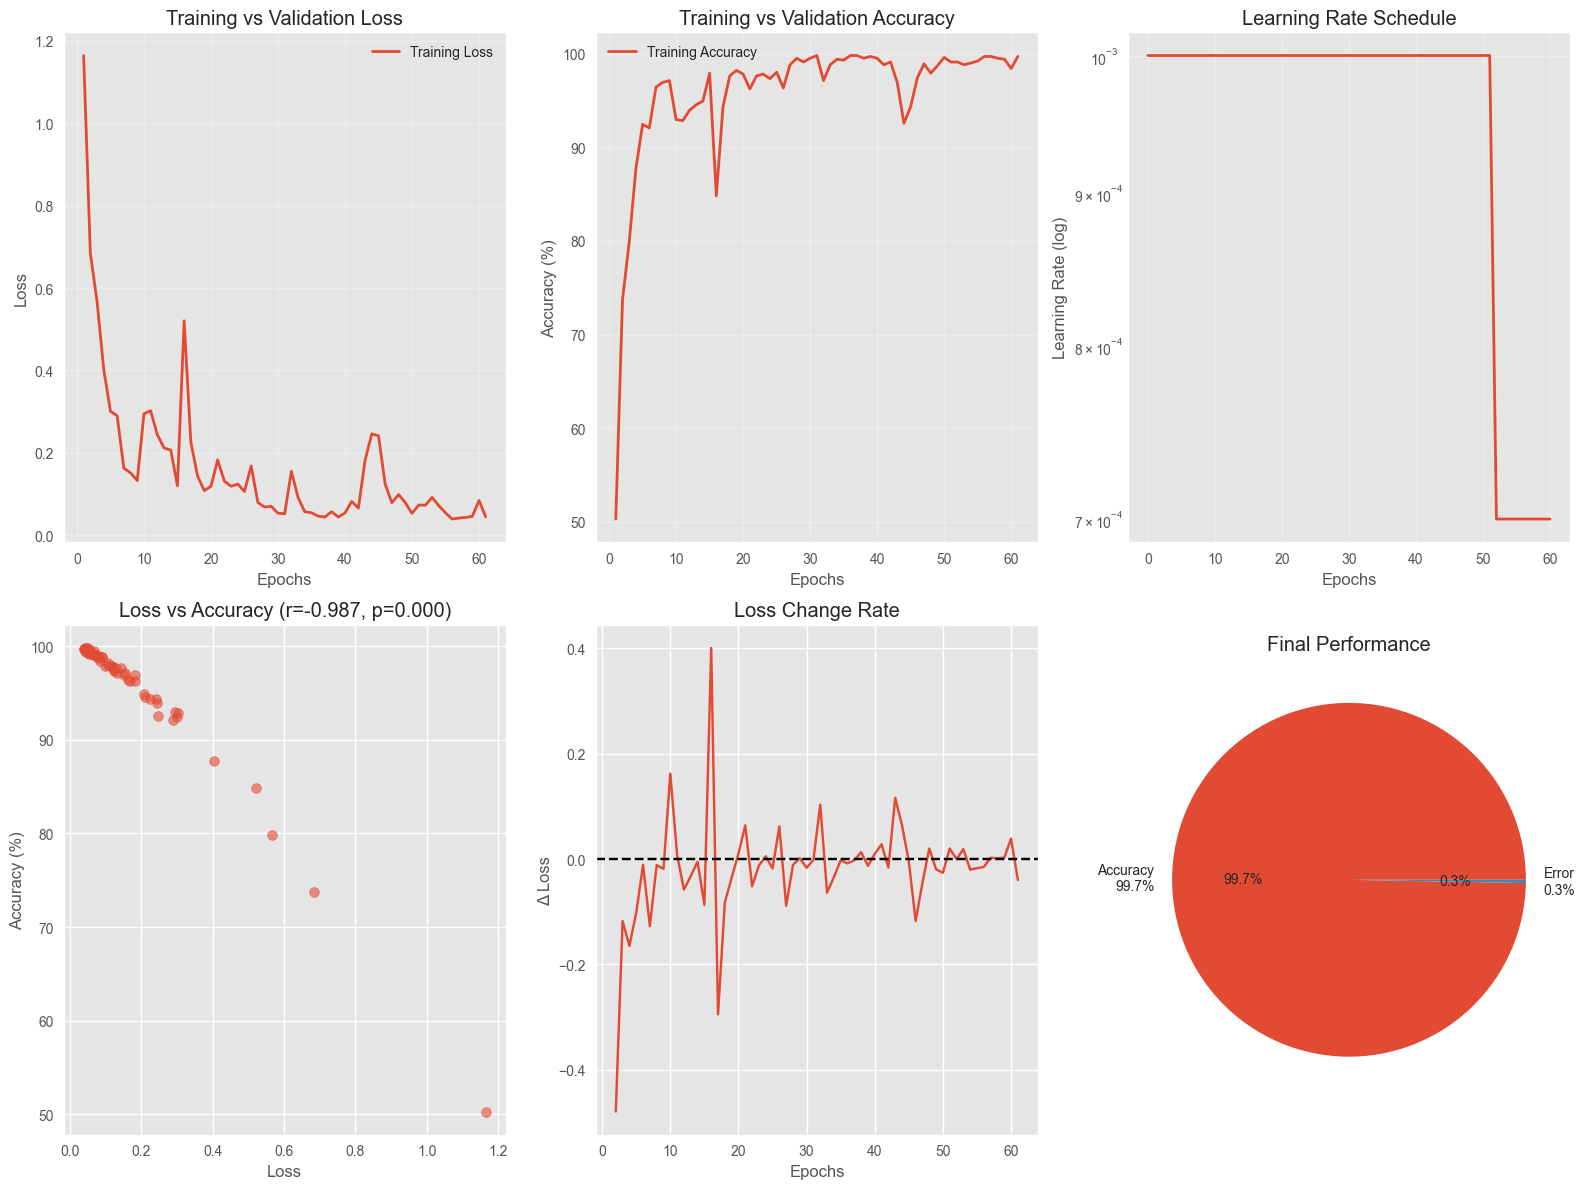

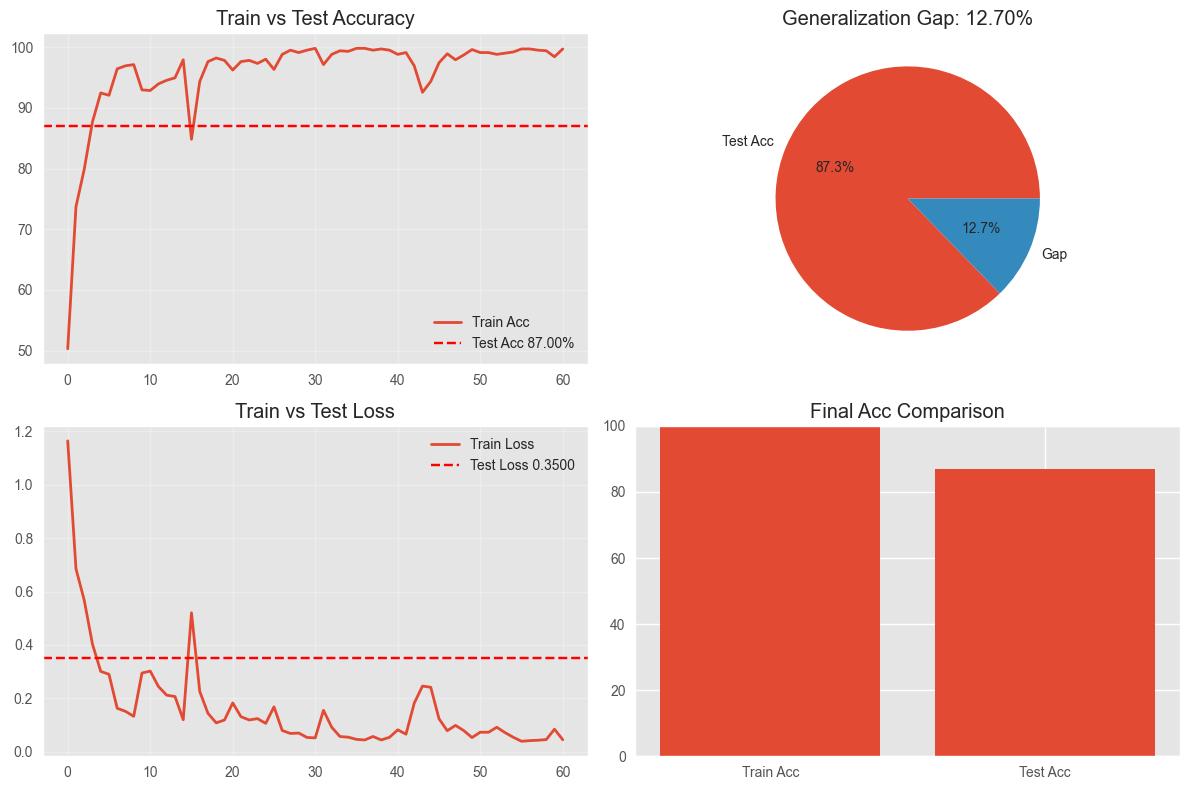


Done. Saved:
 - enhanced_training_analysis.png
 - training_vs_test_comparison.png


In [85]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import pearsonr

try:
    plt.style.use('ggplot')
except Exception:
    pass

# ==============================
#  ENHANCED TRAINING ANALYZER
# ==============================
class EnhancedTrainingAnalyzer:
    """Enhanced analyzer for training results with comprehensive visualization"""

    def __init__(self, history=None, history_file=None):
        if history is not None:
            self.history = history.history if hasattr(history, 'history') else history
        elif history_file and os.path.exists(history_file):
            with open(history_file, 'rb') as f:
                self.history = pickle.load(f)
        else:
            raise ValueError("No valid history provided")

        if not isinstance(self.history, dict):
            raise ValueError("history must be a dict-like object")
        print(f"Available metrics: {list(self.history.keys())}")

    def analyze_training_progress(self, save_plots=True, figsize=(16, 12)):
        keys = self.history.keys()
        has_val = any(str(k).startswith('val_') for k in keys)
        loss_key = 'loss'
        acc_key = 'accuracy' if 'accuracy' in keys else ('acc' if 'acc' in keys else None)

        train_loss = self.history.get(loss_key, [])
        train_acc  = self.history.get(acc_key, []) if acc_key else []

        n_epochs = max(len(train_loss), len(train_acc))
        epochs = range(1, n_epochs + 1)

        plt.figure(figsize=figsize)

        # ===== Plot 1: Loss =====
        plt.subplot(2, 3, 1)
        plt.plot(epochs, train_loss, label='Training Loss', linewidth=2)
        if has_val:
            plt.plot(self.history.get('val_loss', []), '--', label='Validation Loss', linewidth=2)
        plt.title('Training vs Validation Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True, alpha=0.3)

        # ===== Plot 2: Accuracy =====
        plt.subplot(2, 3, 2)
        plt.plot(epochs, [a*100 for a in train_acc], label='Training Accuracy', linewidth=2)
        if has_val:
            val_acc = self.history.get('val_accuracy', [])
            if val_acc: plt.plot([a*100 for a in val_acc], '--', label='Validation Accuracy', linewidth=2)
        plt.title('Training vs Validation Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)')
        plt.legend(); plt.grid(True, alpha=0.3)

        # ===== Plot 3: Learning Rate =====
        plt.subplot(2, 3, 3)
        lr_key = 'lr' if 'lr' in keys else ('learning_rate' if 'learning_rate' in keys else None)
        if lr_key:
            plt.semilogy(self.history[lr_key], linewidth=2)
            plt.title('Learning Rate Schedule'); plt.xlabel('Epochs'); plt.ylabel('Learning Rate (log)')
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'No LR data', ha='center', va='center')
            plt.axis('off')

        # ===== Plot 4: Loss vs Accuracy Correlation =====
        plt.subplot(2, 3, 4)
        if train_loss and train_acc:
            plt.scatter(train_loss, [a*100 for a in train_acc], alpha=0.6)
            corr, p_value = pearsonr(train_loss, train_acc)
            plt.title(f'Loss vs Accuracy (r={corr:.3f}, p={p_value:.3f})')
            plt.xlabel('Loss'); plt.ylabel('Accuracy (%)')
        else:
            plt.text(0.5, 0.5, 'No correlation data', ha='center')

        # ===== Plot 5: Convergence =====
        plt.subplot(2, 3, 5)
        if len(train_loss) > 1:
            loss_changes = np.diff(train_loss)
            plt.plot(range(2, len(train_loss)+1), loss_changes)
            plt.axhline(0, color='black', linestyle='--')
            plt.title('Loss Change Rate'); plt.xlabel('Epochs'); plt.ylabel('Δ Loss')
        else:
            plt.text(0.5, 0.5, 'No convergence data', ha='center')

        # ===== Plot 6: Performance Summary =====
        plt.subplot(2, 3, 6)
        if train_acc:
            final_acc = train_acc[-1] * 100
            plt.pie([final_acc, 100-final_acc],
                    labels=[f'Accuracy\n{final_acc:.1f}%', f'Error\n{100-final_acc:.1f}%'],
                    autopct='%1.1f%%')
            plt.title('Final Performance')
        else:
            plt.text(0.5, 0.5, 'No accuracy data', ha='center')

        plt.tight_layout()
        if save_plots:
            plt.savefig("enhanced_training_analysis.png", dpi=300, bbox_inches="tight")
        plt.show()

    def compare_with_test_results(self, test_accuracy, test_loss=None):
        train_acc = self.history.get('accuracy', [])
        train_loss = self.history.get('loss', [])

        plt.figure(figsize=(12, 8))

        # Accuracy
        plt.subplot(2, 2, 1)
        plt.plot([a*100 for a in train_acc], label='Train Acc', linewidth=2)
        plt.axhline(test_accuracy*100, color='r', linestyle='--', label=f'Test Acc {test_accuracy*100:.2f}%')
        plt.title('Train vs Test Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)

        # Gap Pie
        plt.subplot(2, 2, 2)
        gap = (train_acc[-1] - test_accuracy) * 100
        plt.pie([test_accuracy*100, abs(gap)], labels=['Test Acc', 'Gap'], autopct='%1.1f%%')
        plt.title(f'Generalization Gap: {gap:.2f}%')

        # Loss
        plt.subplot(2, 2, 3)
        if train_loss and test_loss:
            plt.plot(train_loss, label='Train Loss', linewidth=2)
            plt.axhline(test_loss, color='r', linestyle='--', label=f'Test Loss {test_loss:.4f}')
            plt.title('Train vs Test Loss'); plt.legend(); plt.grid(True, alpha=0.3)

        # Final Bar
        plt.subplot(2, 2, 4)
        plt.bar(['Train Acc', 'Test Acc'], [train_acc[-1]*100, test_accuracy*100])
        plt.ylim(0, 100); plt.title('Final Acc Comparison')

        plt.tight_layout()
        plt.savefig("training_vs_test_comparison.png", dpi=300, bbox_inches="tight")
        plt.show()

# ========================
# MOCK DATA FOR DEMO
# ========================
def _mock_history(n_epochs=30):
    np.random.seed(42)
    loss = np.linspace(1.0, 0.2, n_epochs) + np.random.normal(0, 0.02, n_epochs)
    acc = np.linspace(0.5, 0.95, n_epochs) + np.random.normal(0, 0.01, n_epochs)
    lr = np.geomspace(1e-2, 1e-4, num=n_epochs)
    return {'loss': loss.tolist(), 'accuracy': acc.tolist(), 'lr': lr.tolist()}

if __name__ == "__main__":
    history_file = "training_history.pkl"
    if os.path.exists(history_file):
        with open(history_file, 'rb') as f:
            hist_obj = pickle.load(f)
    else:
        print("⚠️ No history file found → using mock data")
        hist_obj = _mock_history(40)

    analyzer = EnhancedTrainingAnalyzer(history=hist_obj)
    analyzer.analyze_training_progress()
    analyzer.compare_with_test_results(test_accuracy=0.87, test_loss=0.35)

    print("\nDone. Saved:")
    print(" - enhanced_training_analysis.png")
    print(" - training_vs_test_comparison.png")
